In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('creditcard.csv')

In [5]:
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
254631,156830.0,2.094479,-1.108800,-0.593249,-0.971453,-0.965019,-0.064280,-1.174867,0.133873,-0.056723,...,0.377681,1.056302,0.164729,0.726883,-0.203599,-0.137507,-0.001035,-0.050235,24.99,0
156487,108217.0,-3.657500,1.523953,-1.818975,-2.322504,3.214216,3.550666,2.197778,-0.955500,5.433874,...,-1.607555,-0.998697,-0.248008,0.610161,0.106399,-0.091075,-0.236684,-0.200165,89.99,0
24656,33318.0,1.211530,0.413658,0.716049,2.318168,-0.094362,0.174045,-0.231148,0.038505,-0.409832,...,0.090447,0.248176,-0.168036,-0.452614,0.548669,0.148489,0.011409,0.022478,10.62,0
75068,55884.0,1.352265,-1.117900,-0.269259,-1.776264,0.731357,3.745376,-1.861159,1.026008,-0.321680,...,0.400362,0.907622,-0.143413,1.050973,0.466534,-0.030606,0.055346,0.031600,40.00,0
184062,126076.0,-0.805307,0.592395,0.551546,-0.751410,1.014066,-0.542202,0.392295,-0.775045,-0.365787,...,0.563001,-0.817648,-0.051766,-0.418166,-0.443212,0.187713,0.164345,0.117937,1.29,0
256565,157757.0,-0.458622,0.682699,-0.717700,-2.741283,0.799946,-0.651983,0.842970,-0.432882,-0.388896,...,0.350171,1.502181,-0.225764,0.092797,-0.430763,-0.215199,0.606191,0.299292,15.00,0
262486,160500.0,0.557326,-4.307973,-1.962092,-1.130010,-1.603855,0.967117,-0.195515,-0.112935,-1.336969,...,-0.034053,-1.616114,-0.394268,-0.367379,-0.780347,-0.654549,-0.136482,0.106433,912.45,0
46145,42654.0,0.524819,1.672484,-3.758441,0.542781,3.166982,2.336754,0.018342,1.146617,-0.641134,...,-0.158910,-0.486692,0.103758,0.654672,-0.278011,-0.383406,0.133807,-0.053975,2.69,0
60450,49327.0,1.174519,0.601446,-0.494666,1.110575,0.469544,-0.266455,0.109142,0.073987,-0.297960,...,-0.012576,0.026028,-0.144431,-0.447733,0.624462,-0.294032,0.046020,0.040100,1.00,0
199774,133131.0,-1.120118,-0.184650,0.772919,-3.188523,-0.285268,-1.628663,-0.111361,0.328207,1.600581,...,0.408791,1.006958,-0.285631,0.072720,0.091743,-0.860385,0.077948,0.002873,13.64,0


In [11]:
df.shape

(284807, 31)

In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

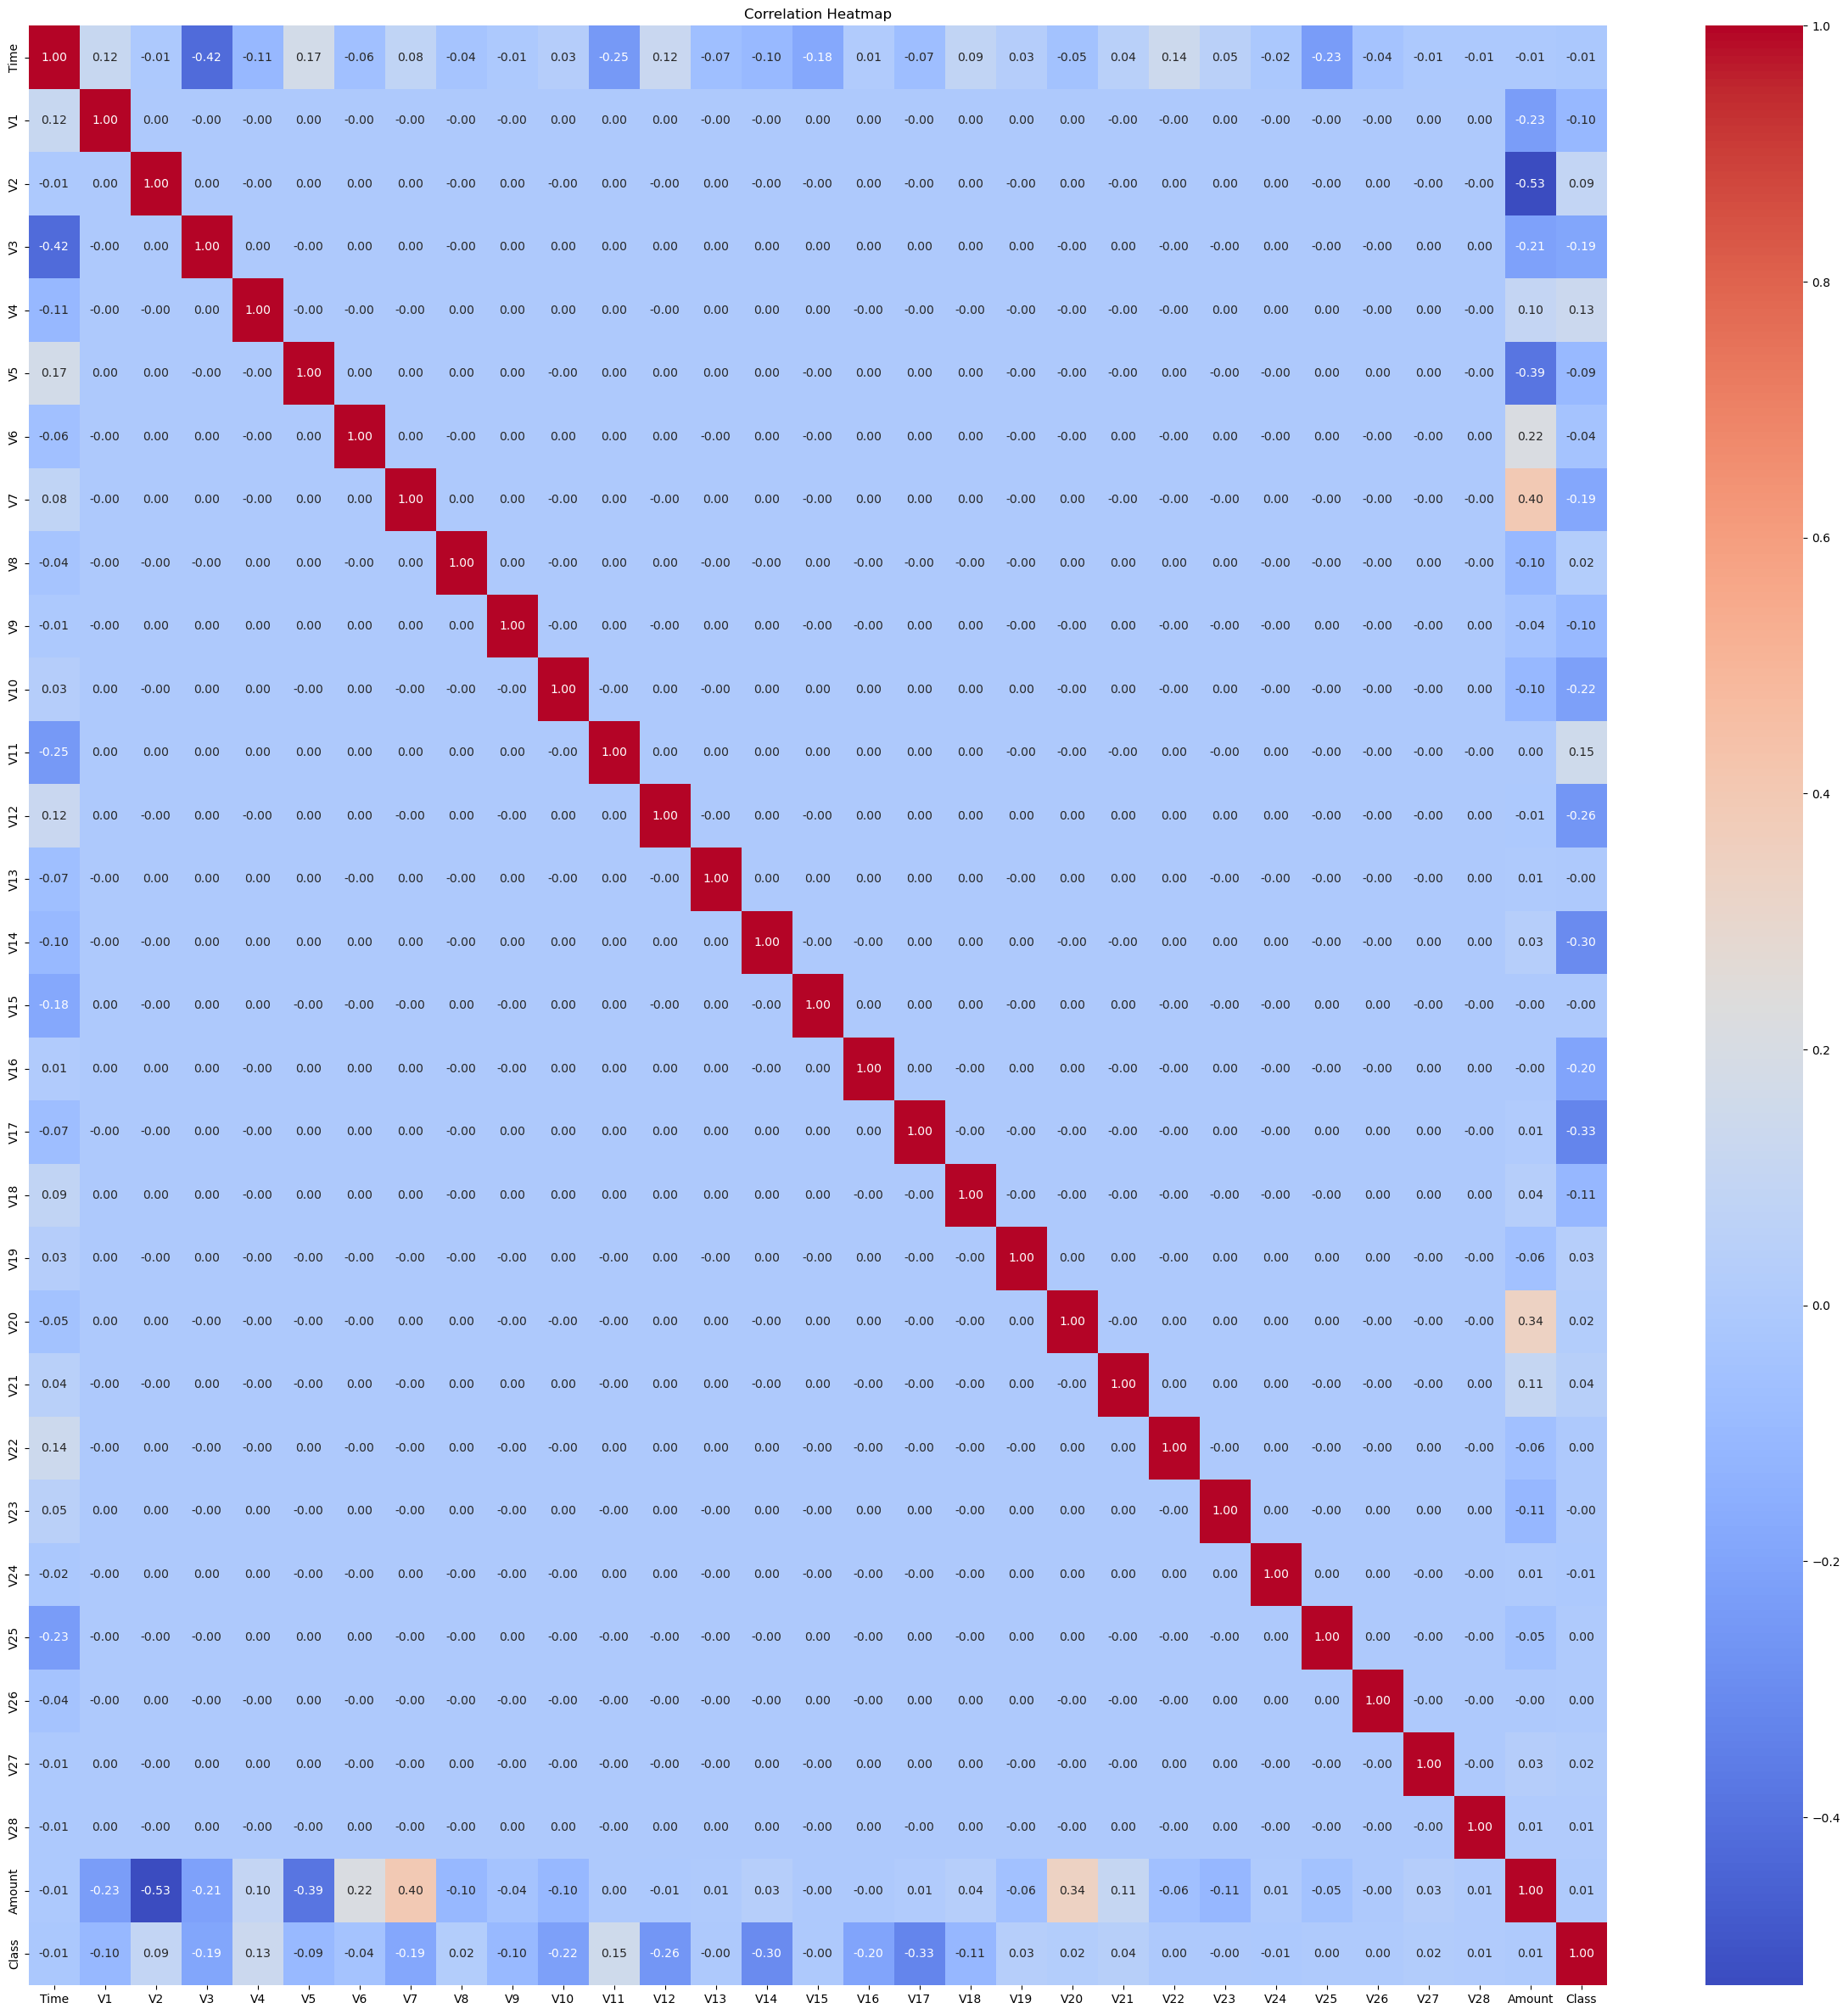

In [27]:
# Calculate correlation
correlation_matrix = df.corr()

plt.figure(figsize=(30,30))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
X = df.drop(['Class'],axis=1)
y = df['Class']

In [19]:
X.shape , y.shape

((284807, 30), (284807,))

In [33]:
X.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68


In [35]:
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


In [5]:
def All_plot(X):
    col = X.columns
    for column in col:
        if np.issubdtype(X[column].dtype, np.number):  # Check if the column is numeric
            fig, axes = plt.subplots(1, 3, figsize=(21, 6))  # 3 plots in a row
            
            skewness = X[column].skew()
            
            # Determine skewness type
            if skewness > 0:
                skew_type = "Positive Skewness"
            elif skewness < 0:
                skew_type = "Negative Skewness"
            else:
                skew_type = "Approximately Symmetrical"
            
            print(f"{column}: Skewness = {skewness:.2f} ({skew_type})")
            
            # KDE plot
            sns.kdeplot(X[column].dropna(), fill=True, color='blue', alpha=0.5, ax=axes[0])
            axes[0].set_title(f"KDE Plot for {column}\n(Skewness: {skewness:.2f}) ({skew_type})", fontsize=12)
            axes[0].set_xlabel(column)
            axes[0].set_ylabel('Density')
            axes[0].grid(alpha=0.3)
        
            # Q-Q plot
            stats.probplot(X[column].dropna(), dist="norm", plot=axes[1])
            axes[1].set_title(f"Q-Q Plot for {column}", fontsize=12)
            
            # Boxplot
            sns.boxplot(x=X[column], ax=axes[2])
            axes[2].set_title(f"Boxplot for {column}", fontsize=12)
            axes[2].set_xlabel(column)
            
            plt.tight_layout()
            plt.show()

Time: Skewness = -0.04 (Negative Skewness)


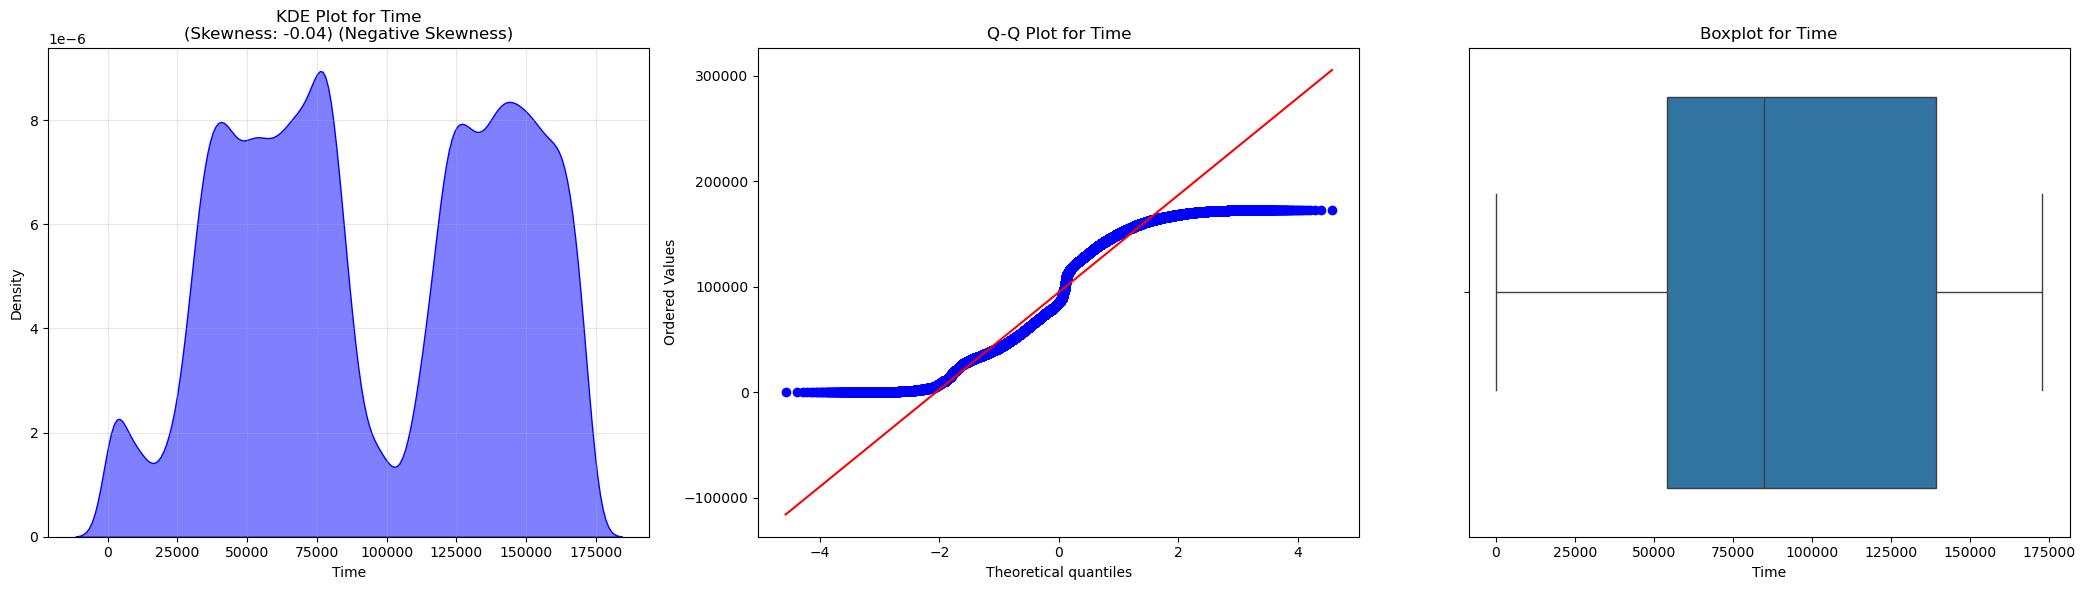

V1: Skewness = -3.28 (Negative Skewness)


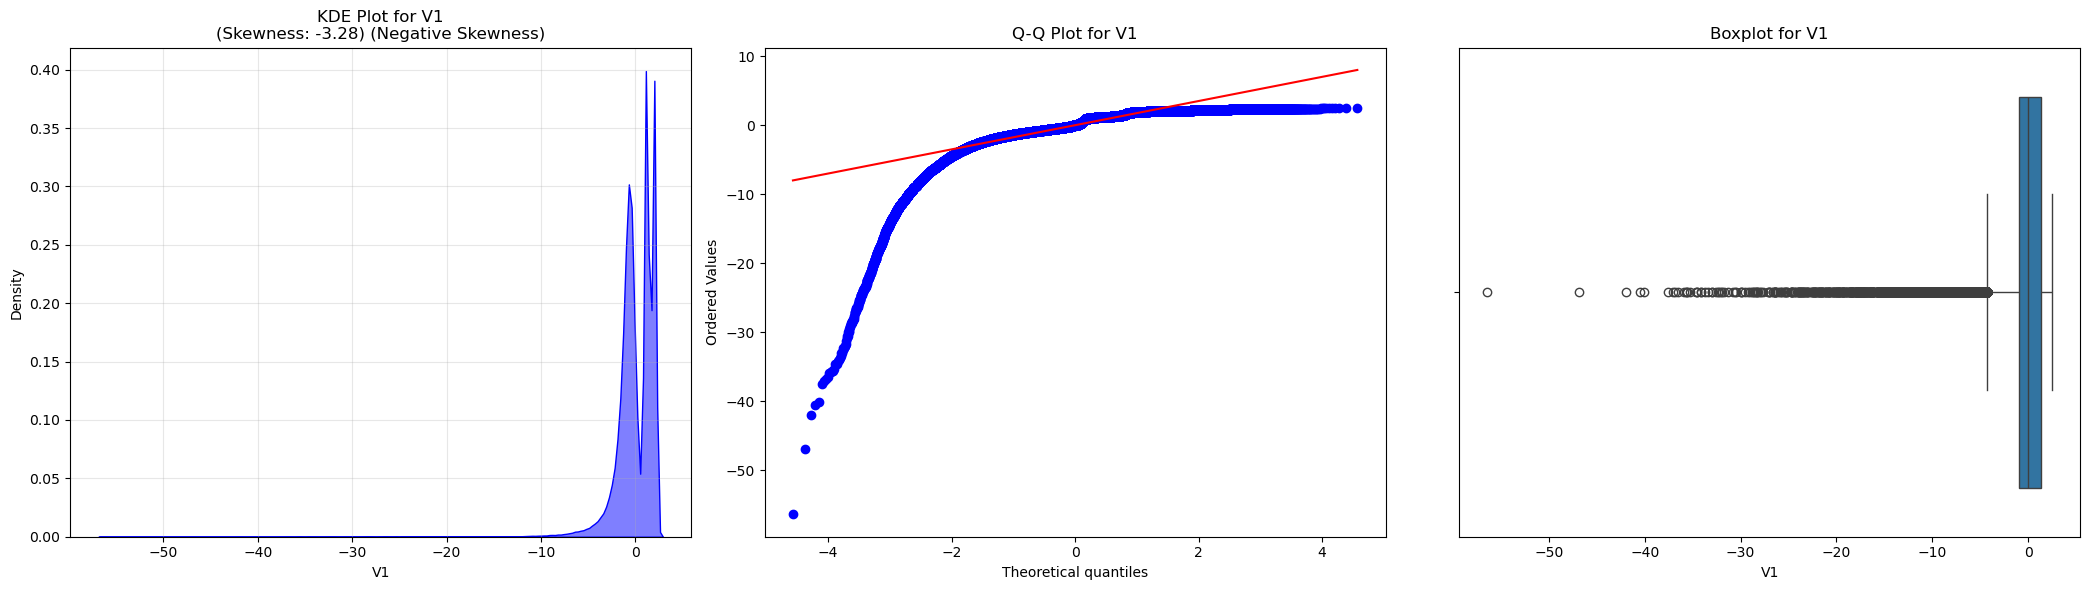

V2: Skewness = -4.62 (Negative Skewness)


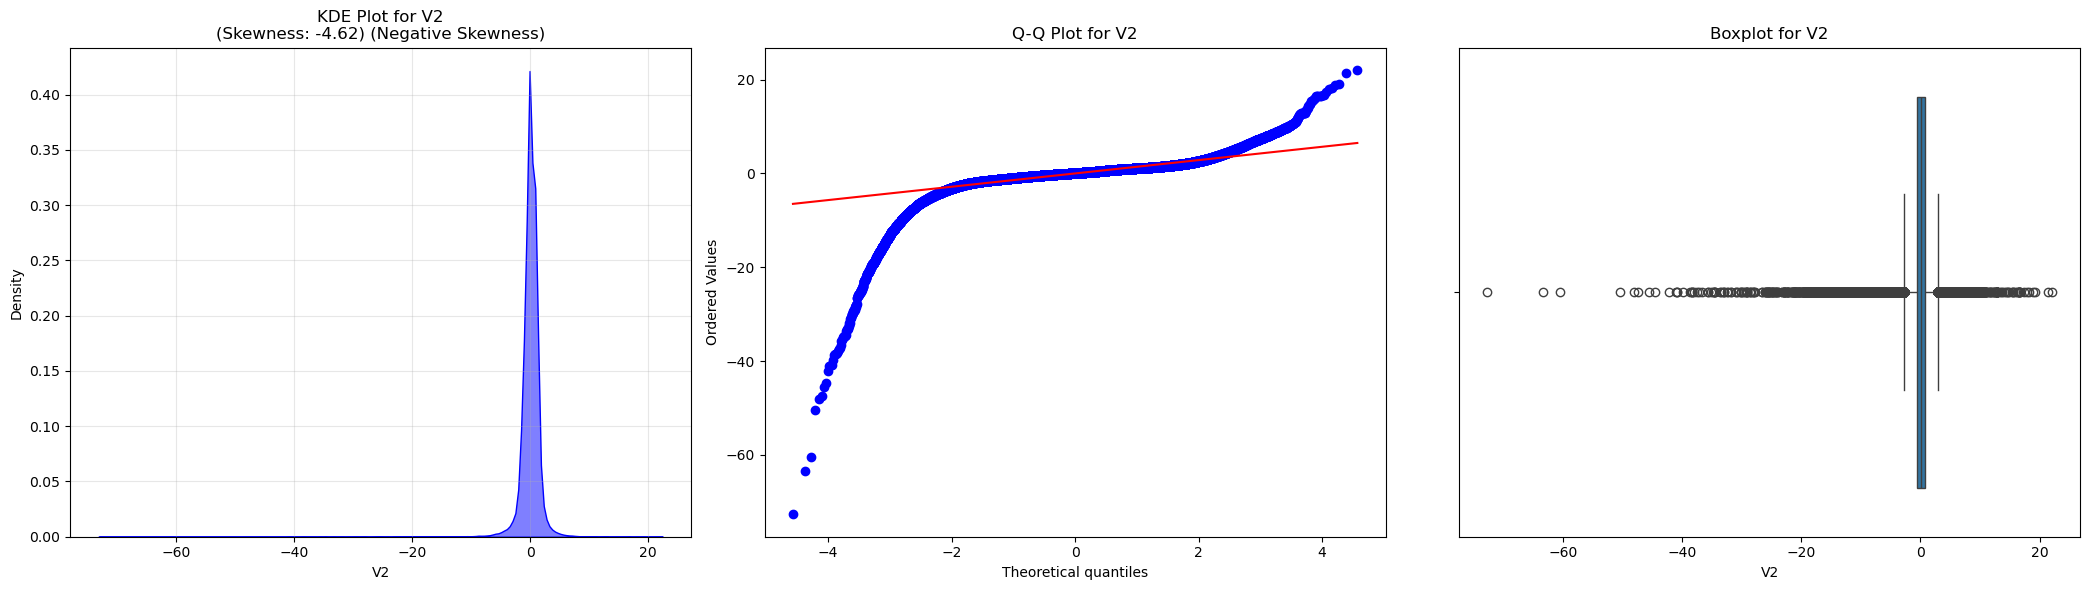

V3: Skewness = -2.24 (Negative Skewness)


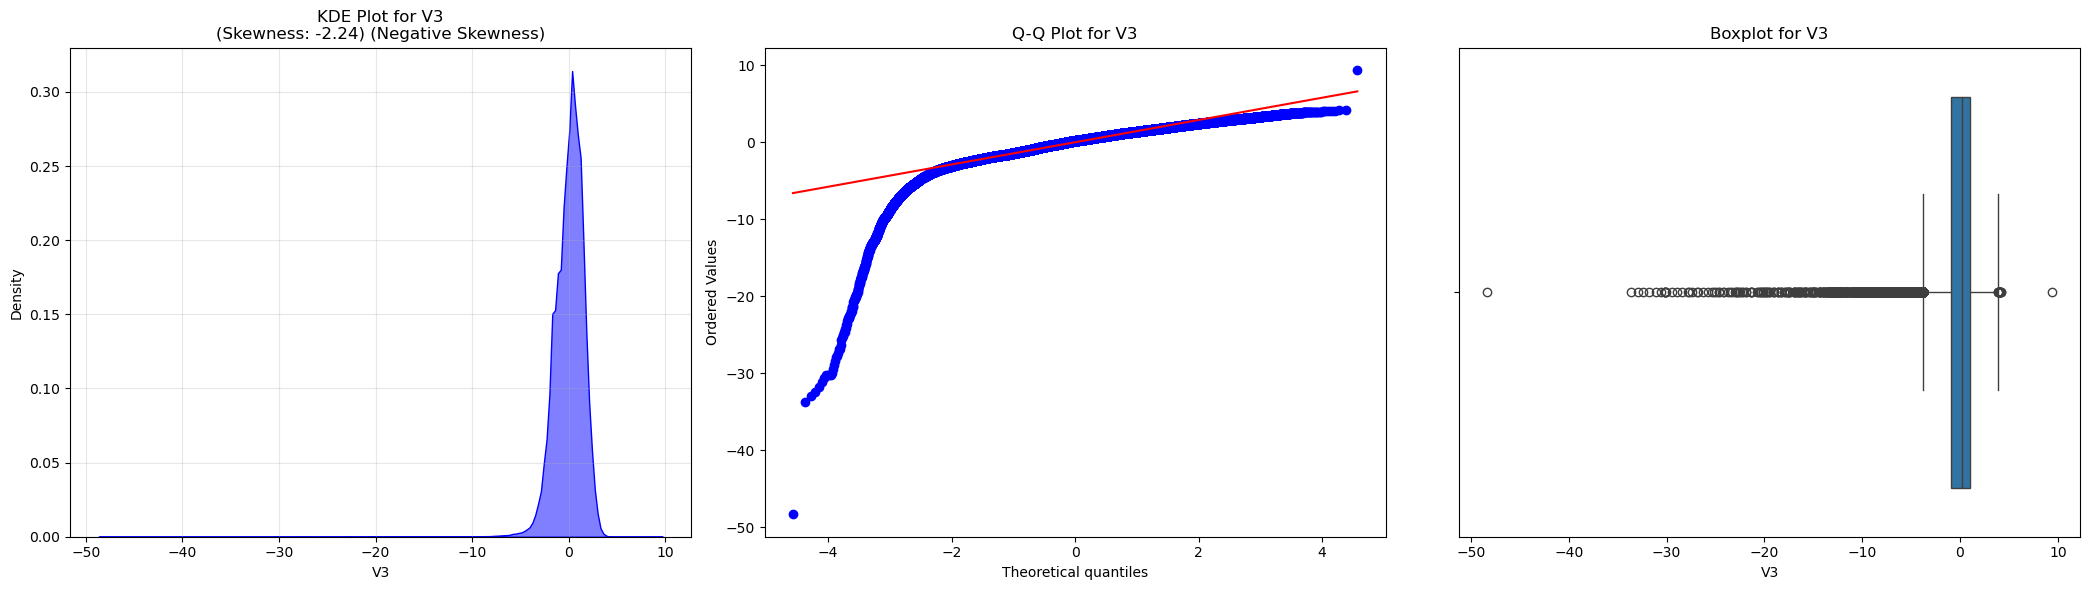

V4: Skewness = 0.68 (Positive Skewness)


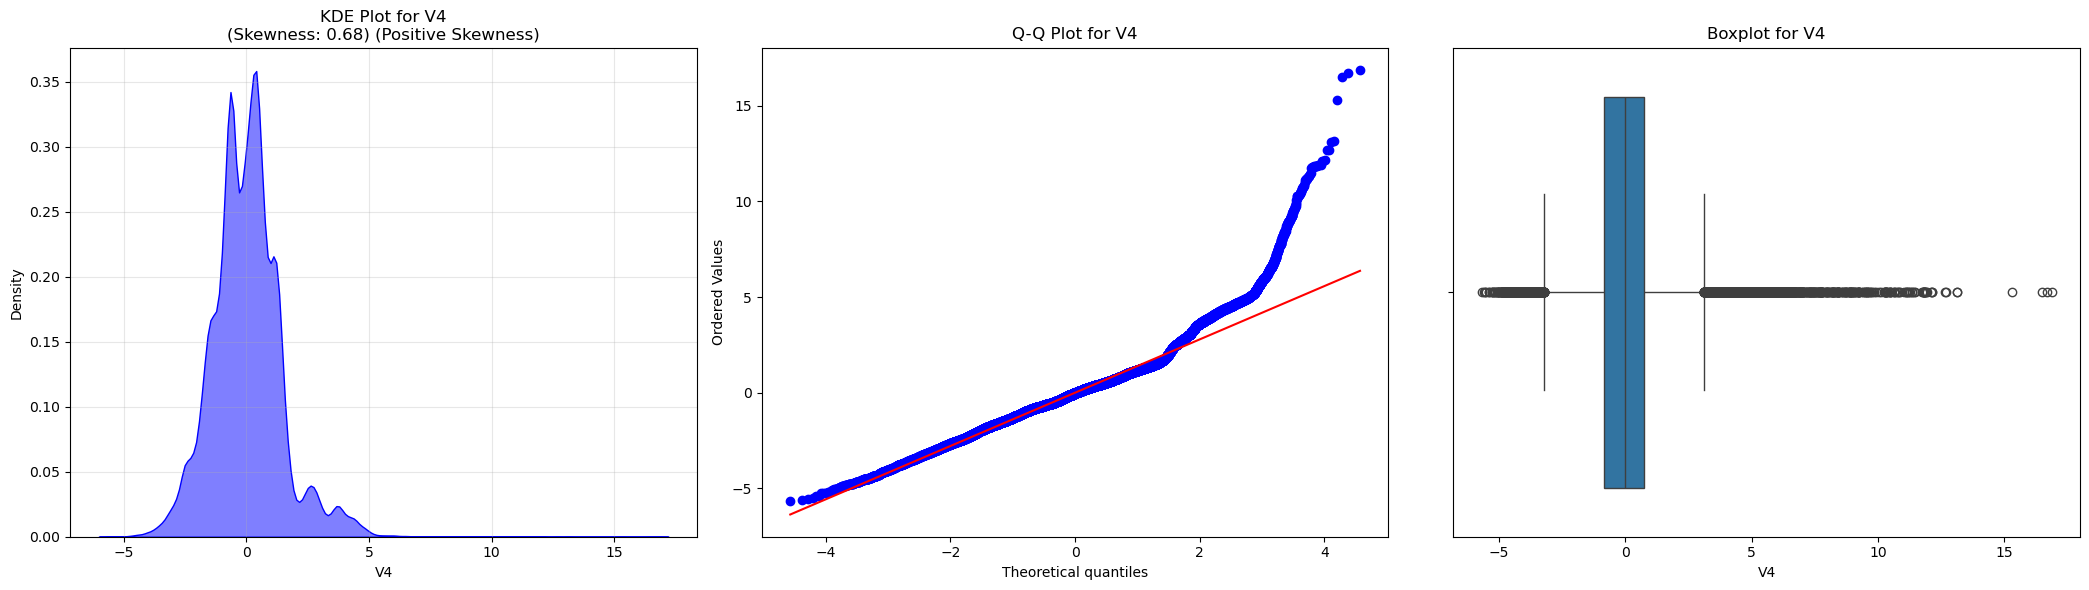

V5: Skewness = -2.43 (Negative Skewness)


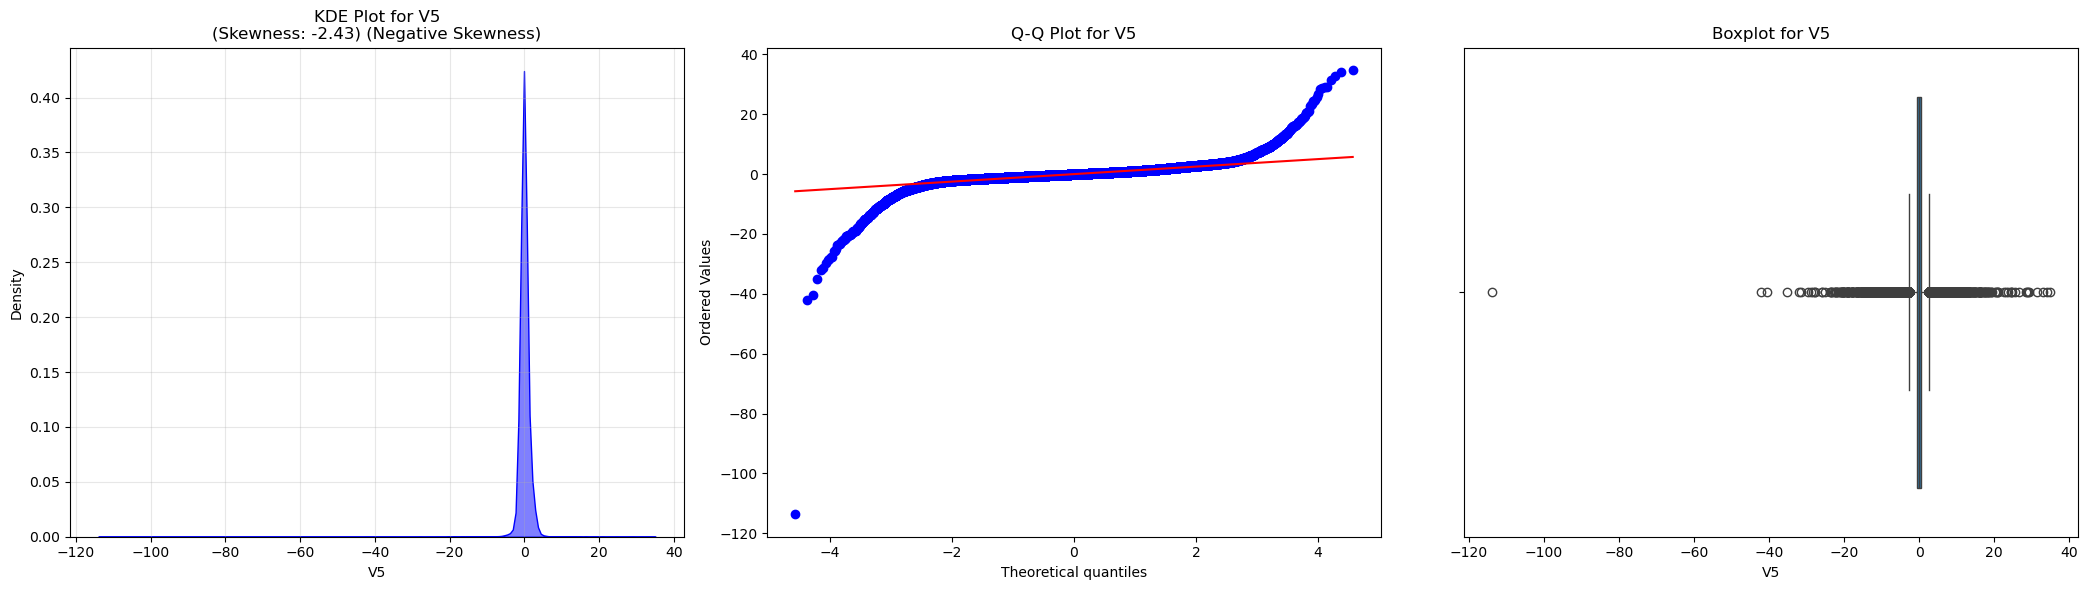

V6: Skewness = 1.83 (Positive Skewness)


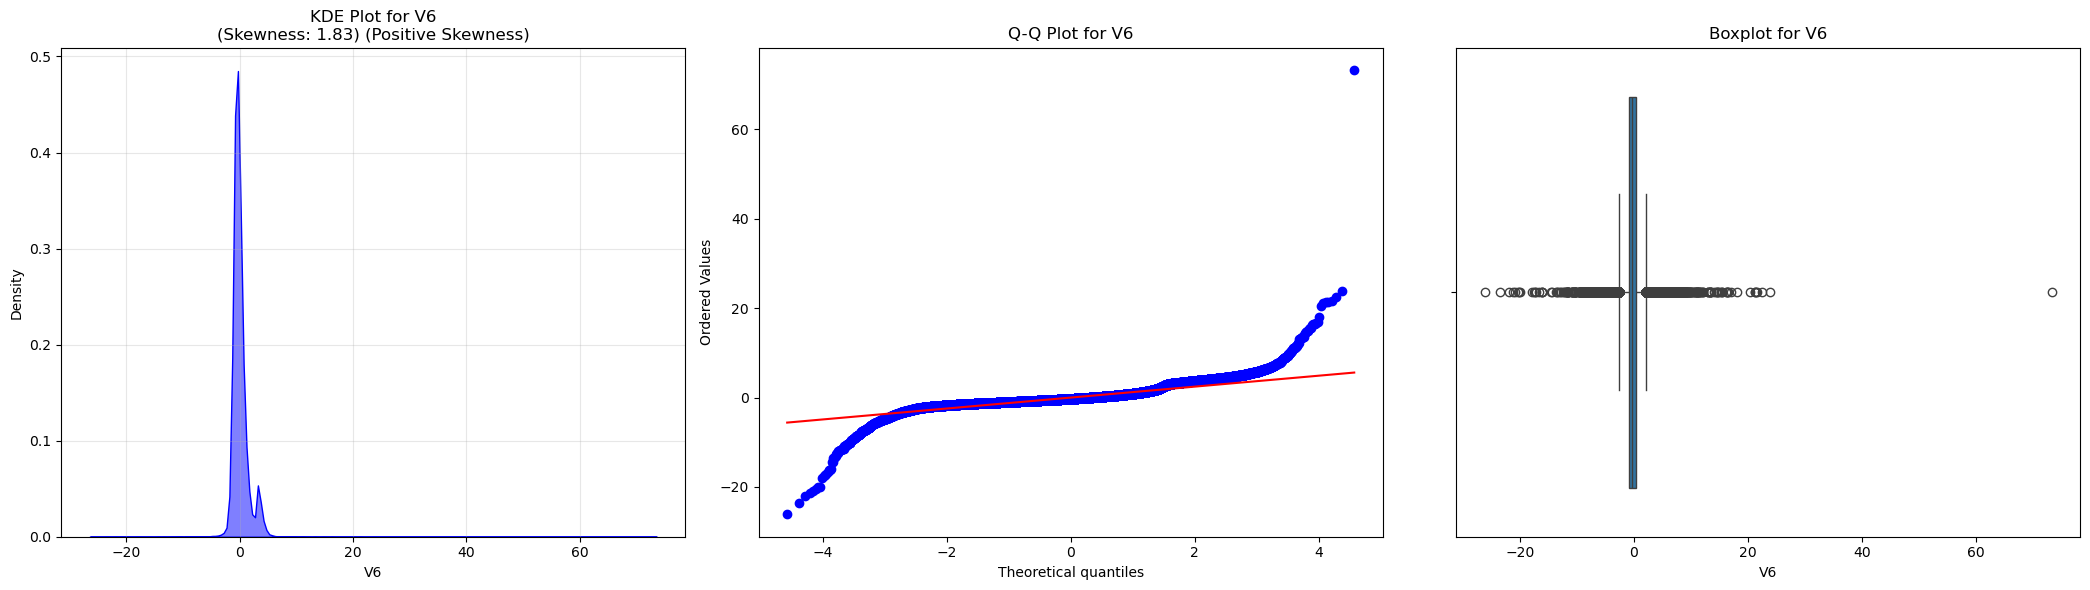

V7: Skewness = 2.55 (Positive Skewness)


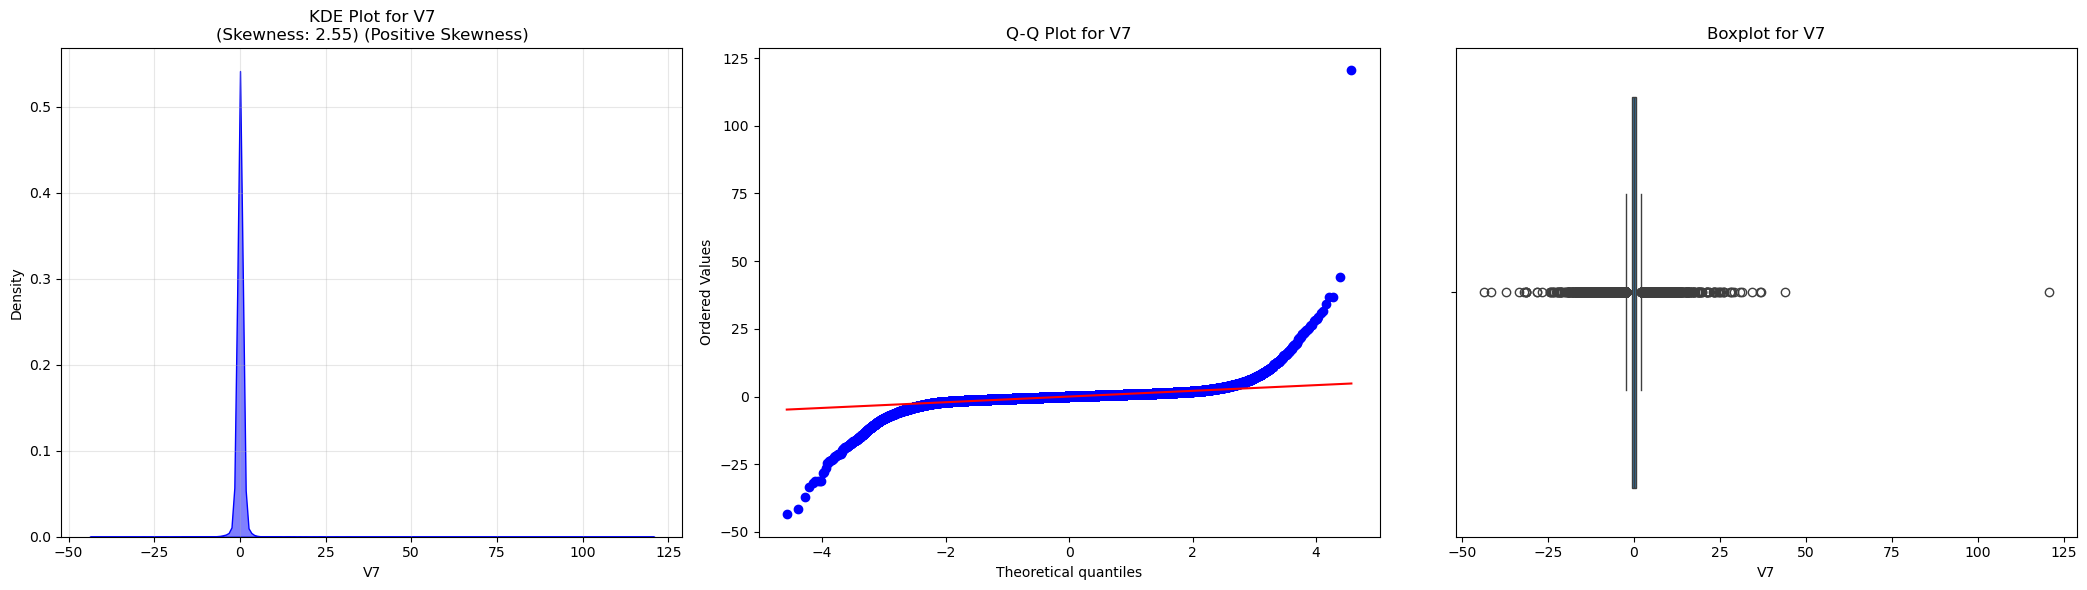

V8: Skewness = -8.52 (Negative Skewness)


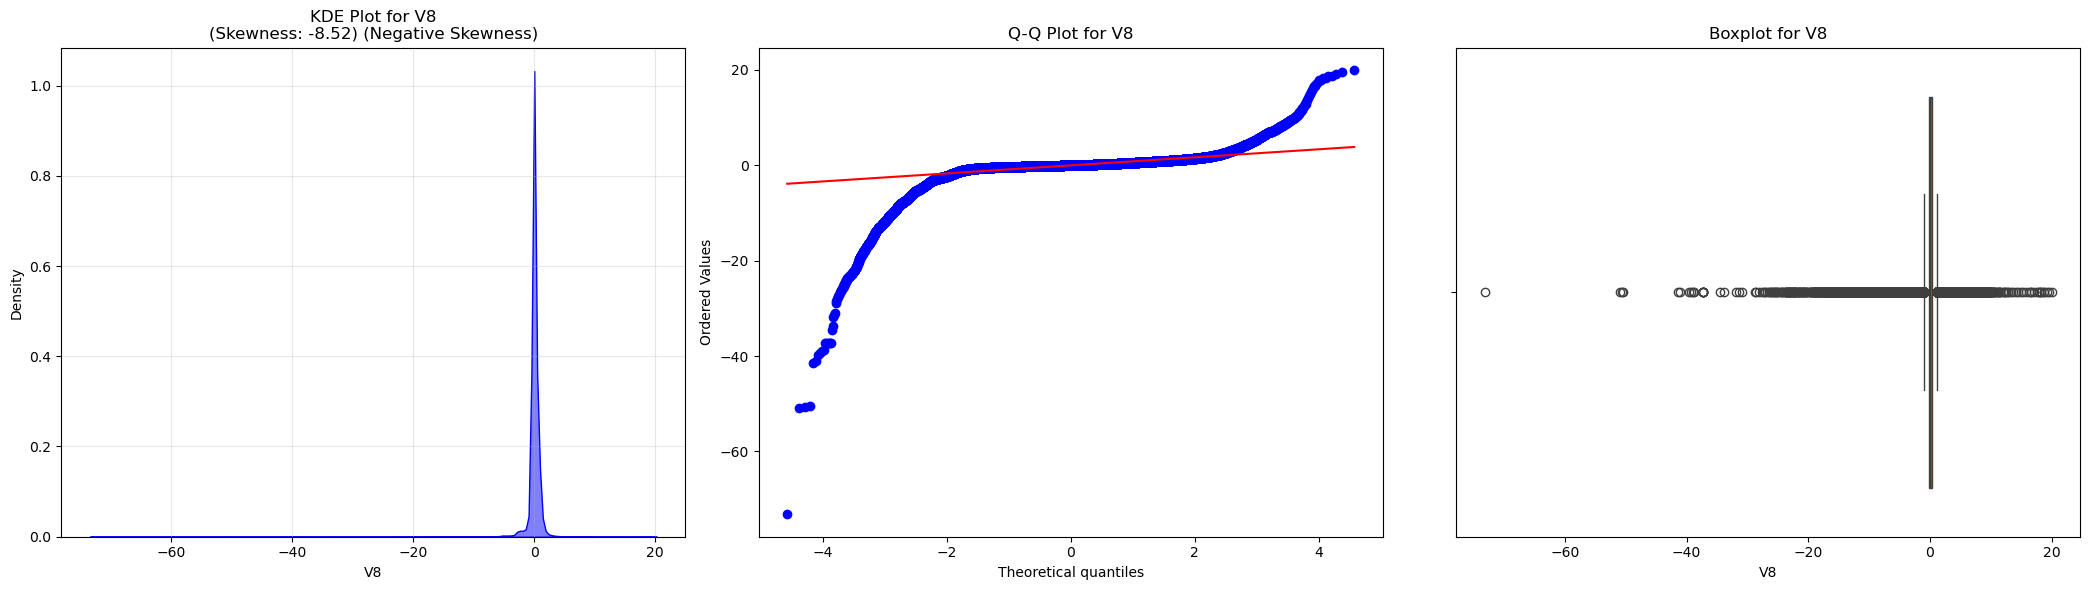

V9: Skewness = 0.55 (Positive Skewness)


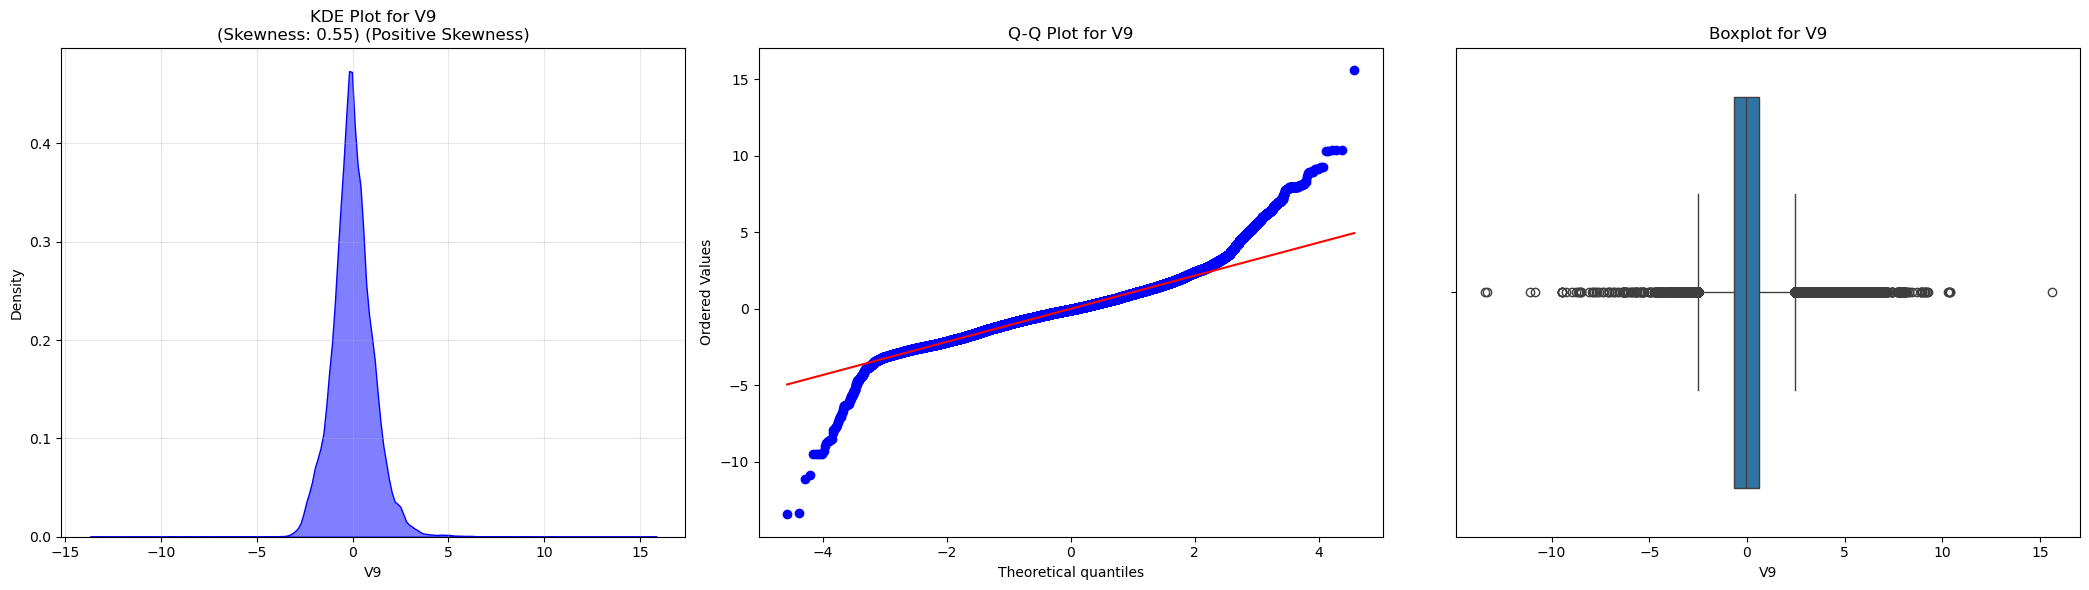

V10: Skewness = 1.19 (Positive Skewness)


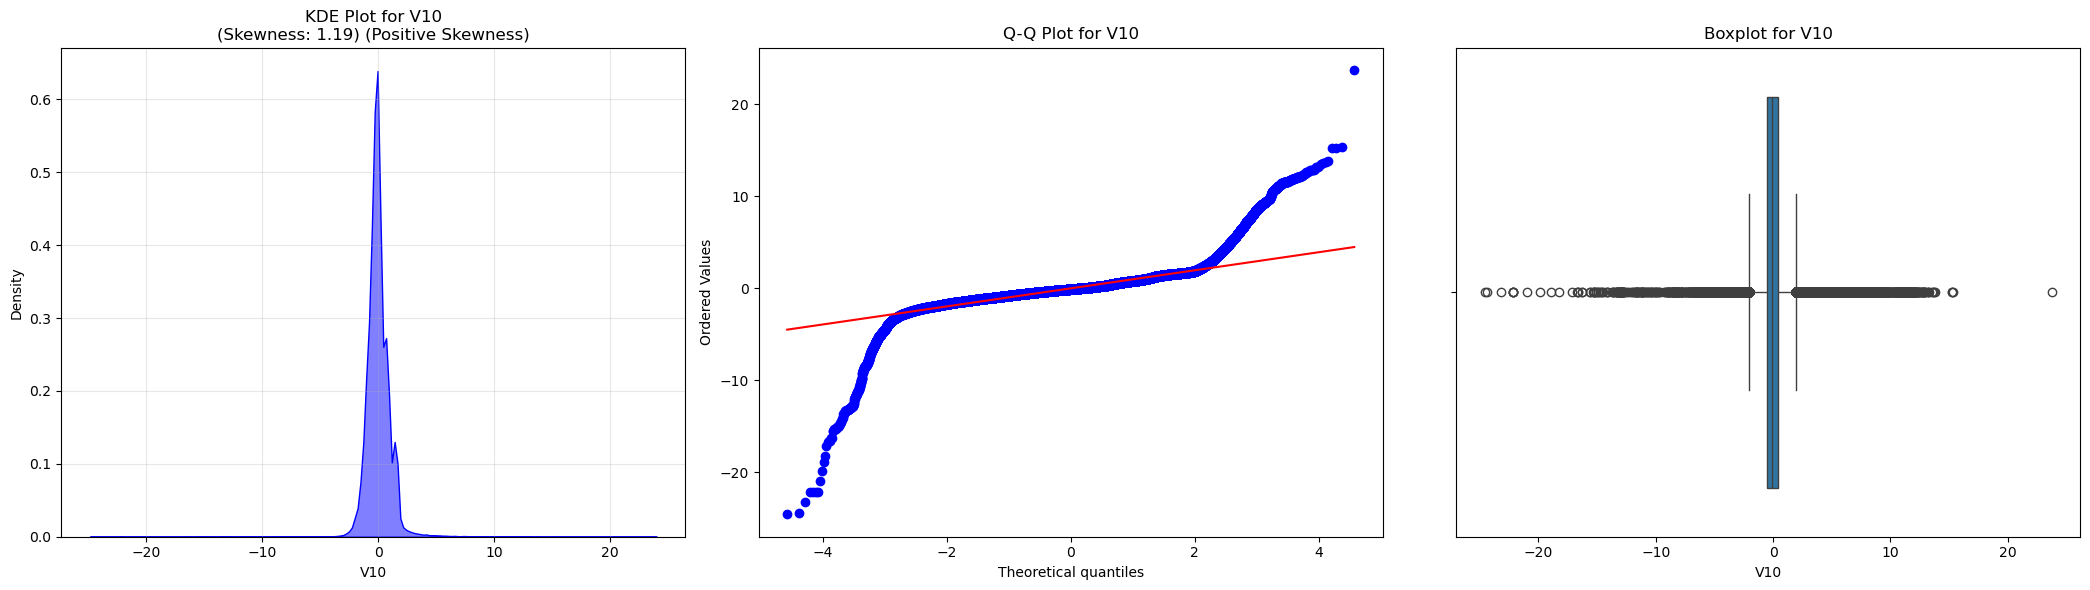

V11: Skewness = 0.36 (Positive Skewness)


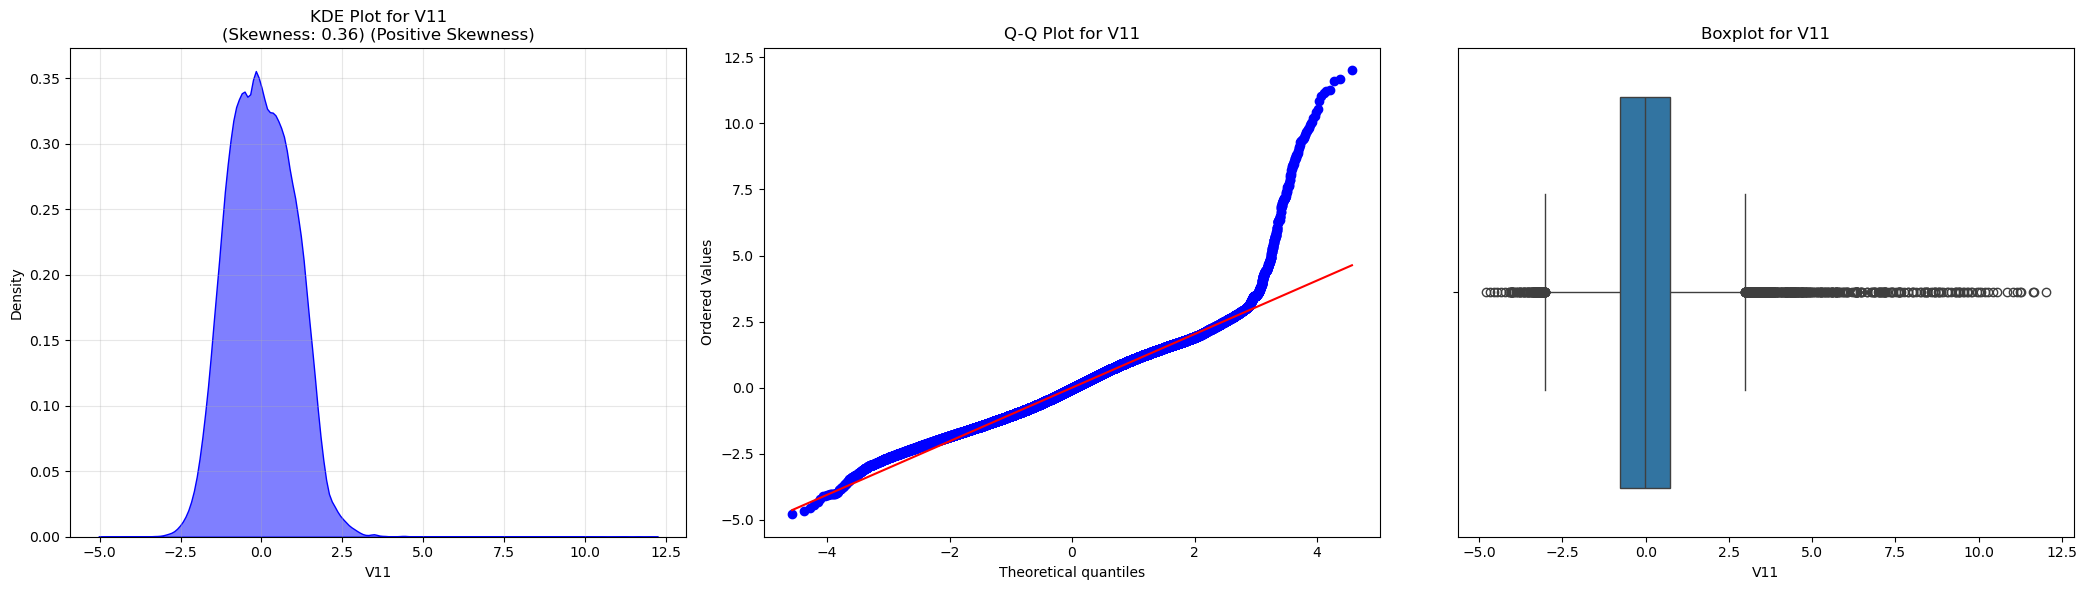

V12: Skewness = -2.28 (Negative Skewness)


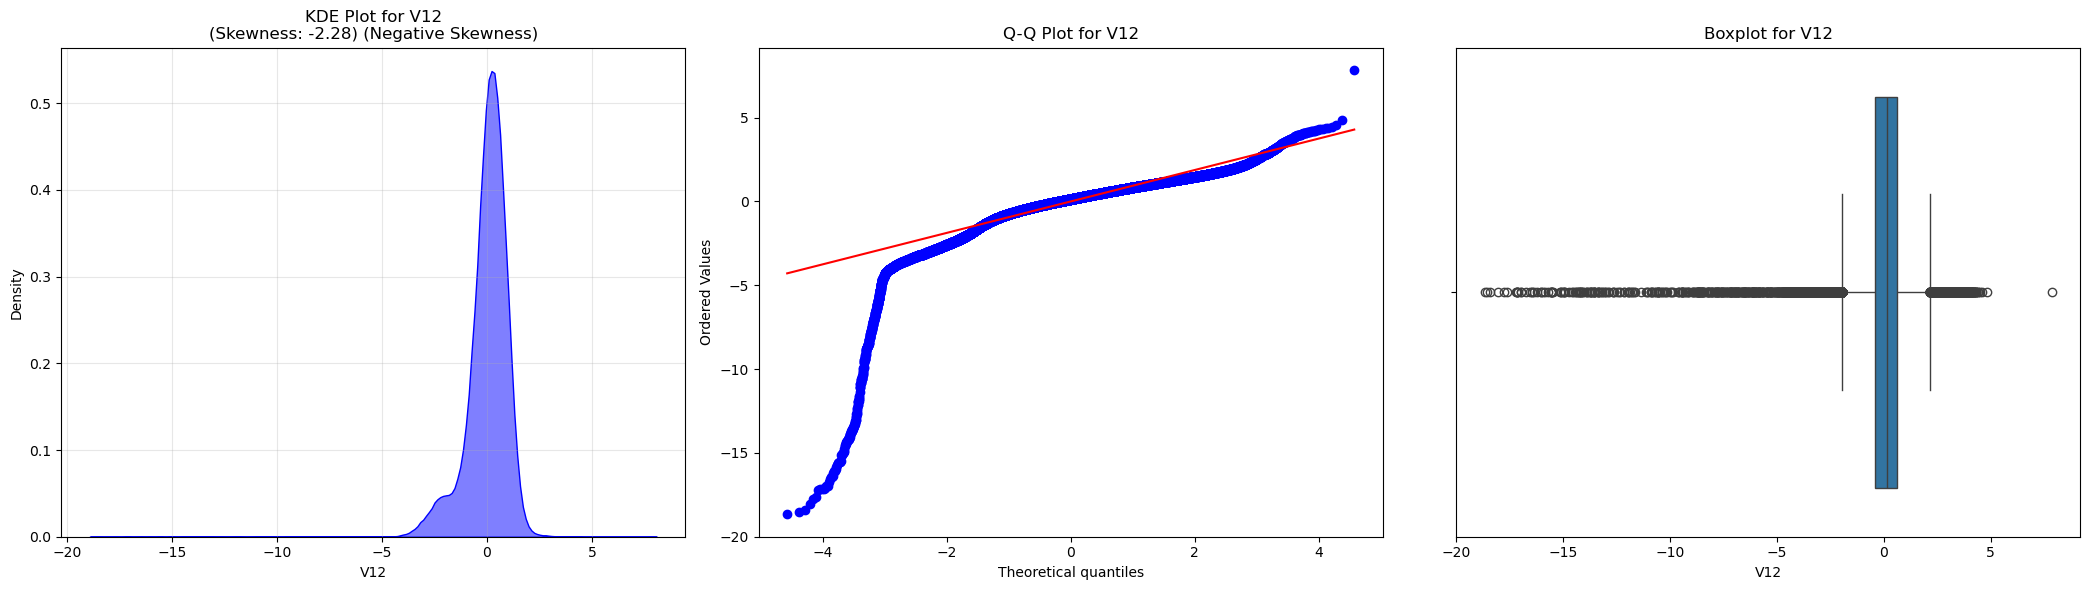

V13: Skewness = 0.07 (Positive Skewness)


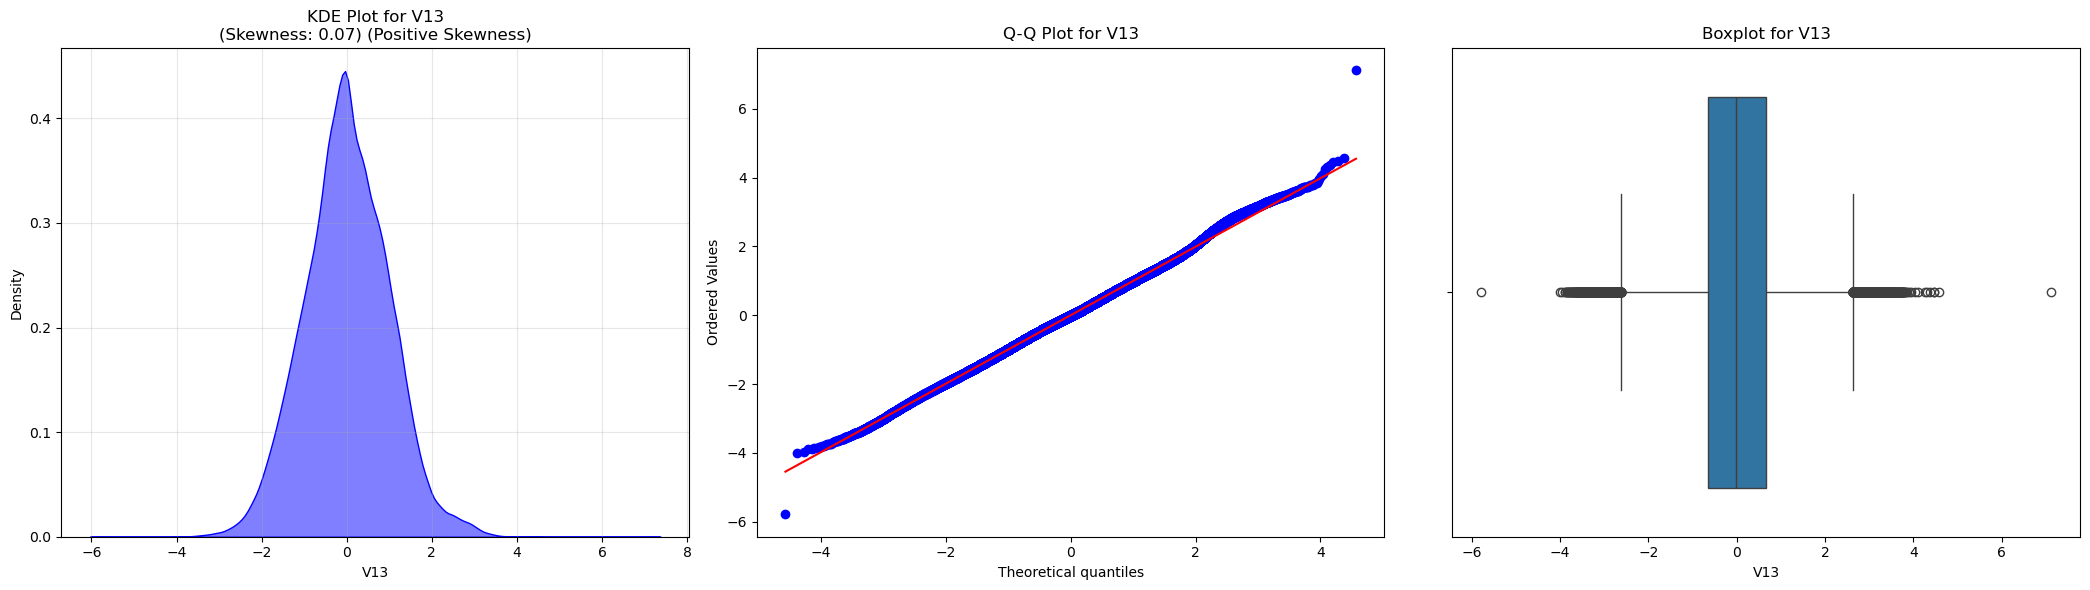

V14: Skewness = -2.00 (Negative Skewness)


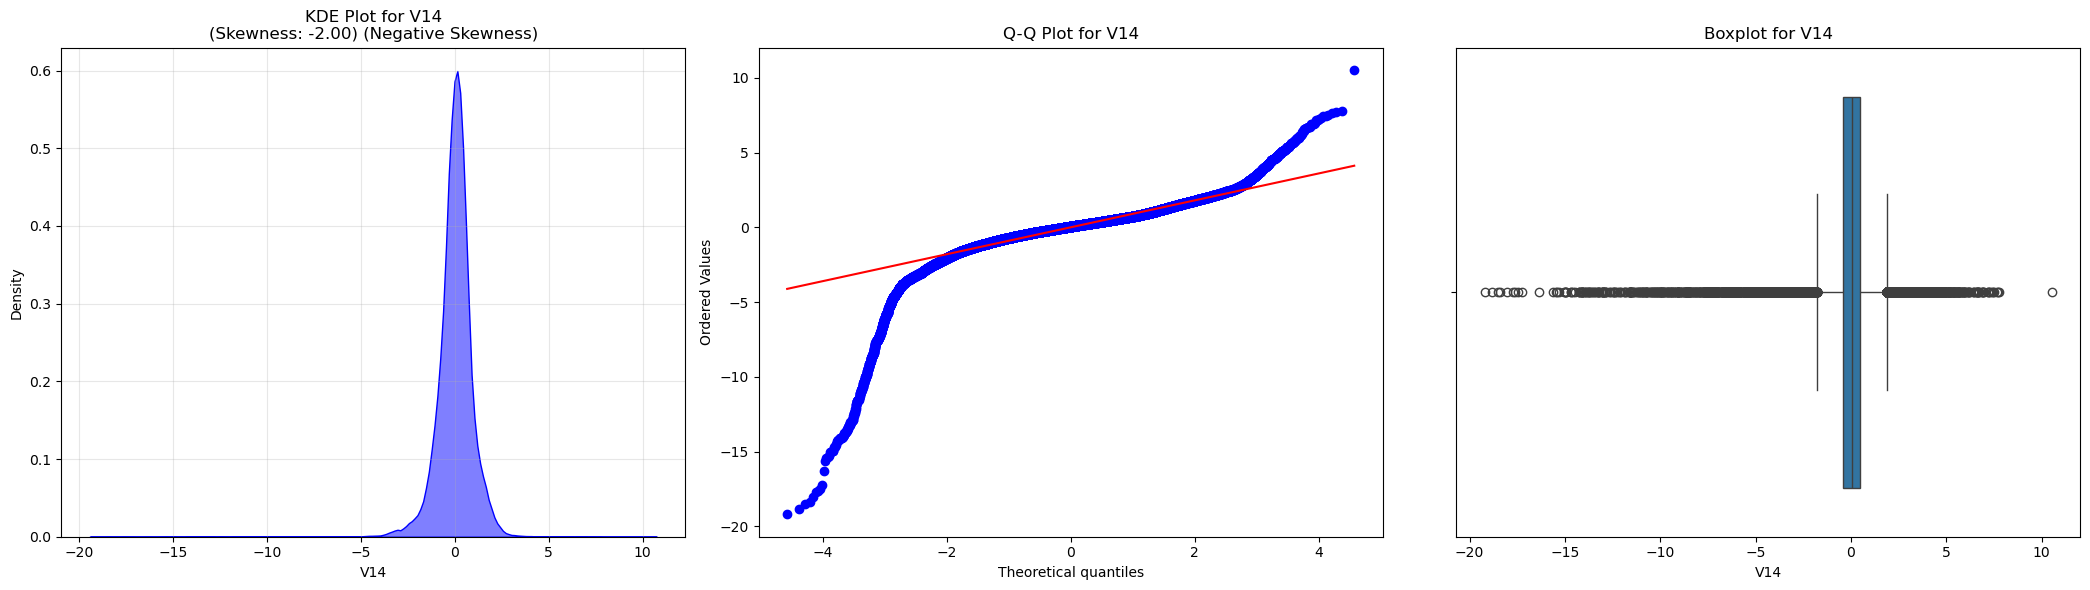

V15: Skewness = -0.31 (Negative Skewness)


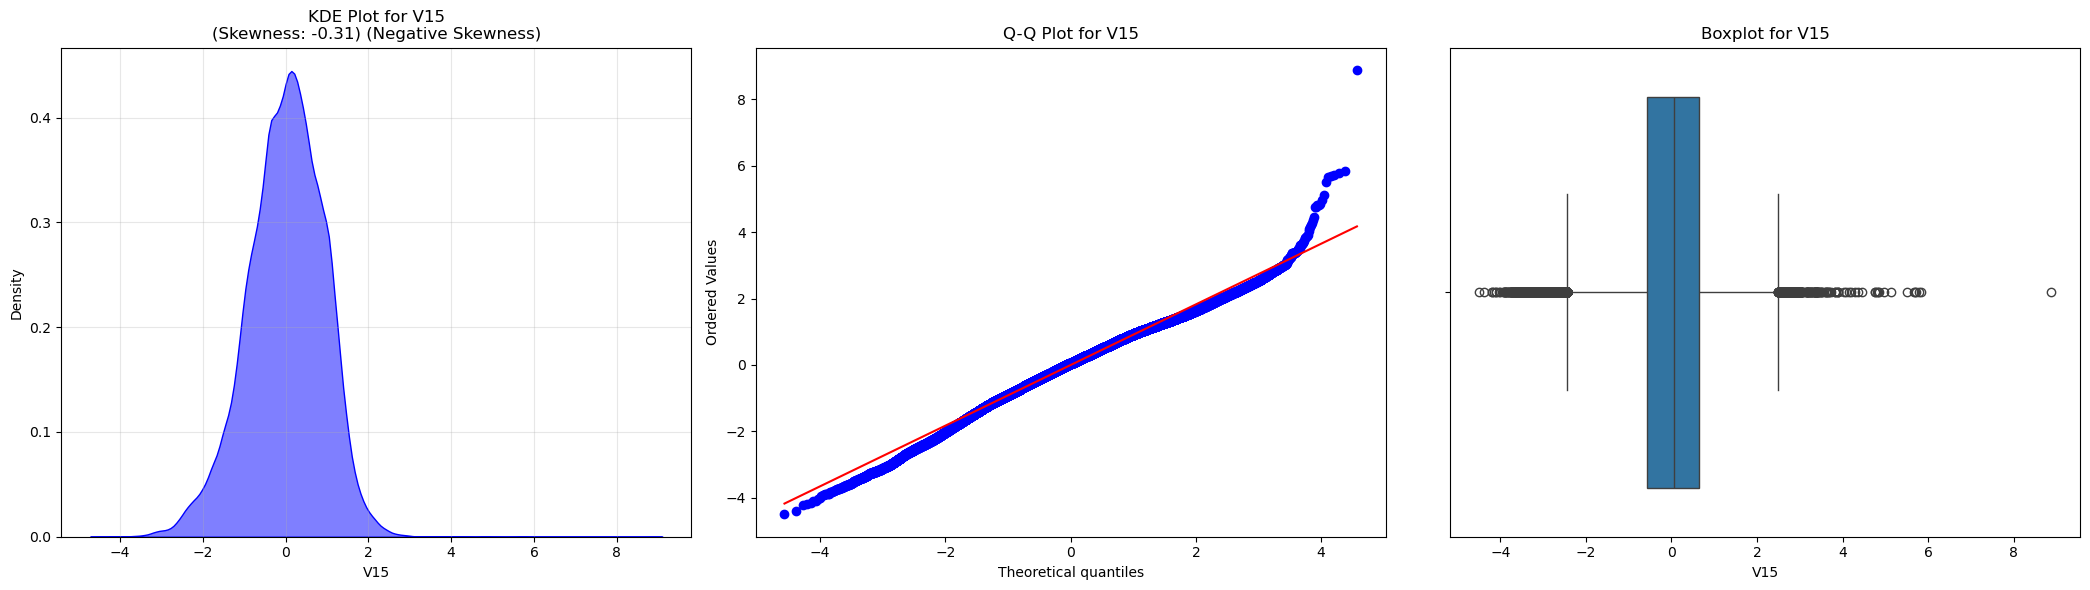

V16: Skewness = -1.10 (Negative Skewness)


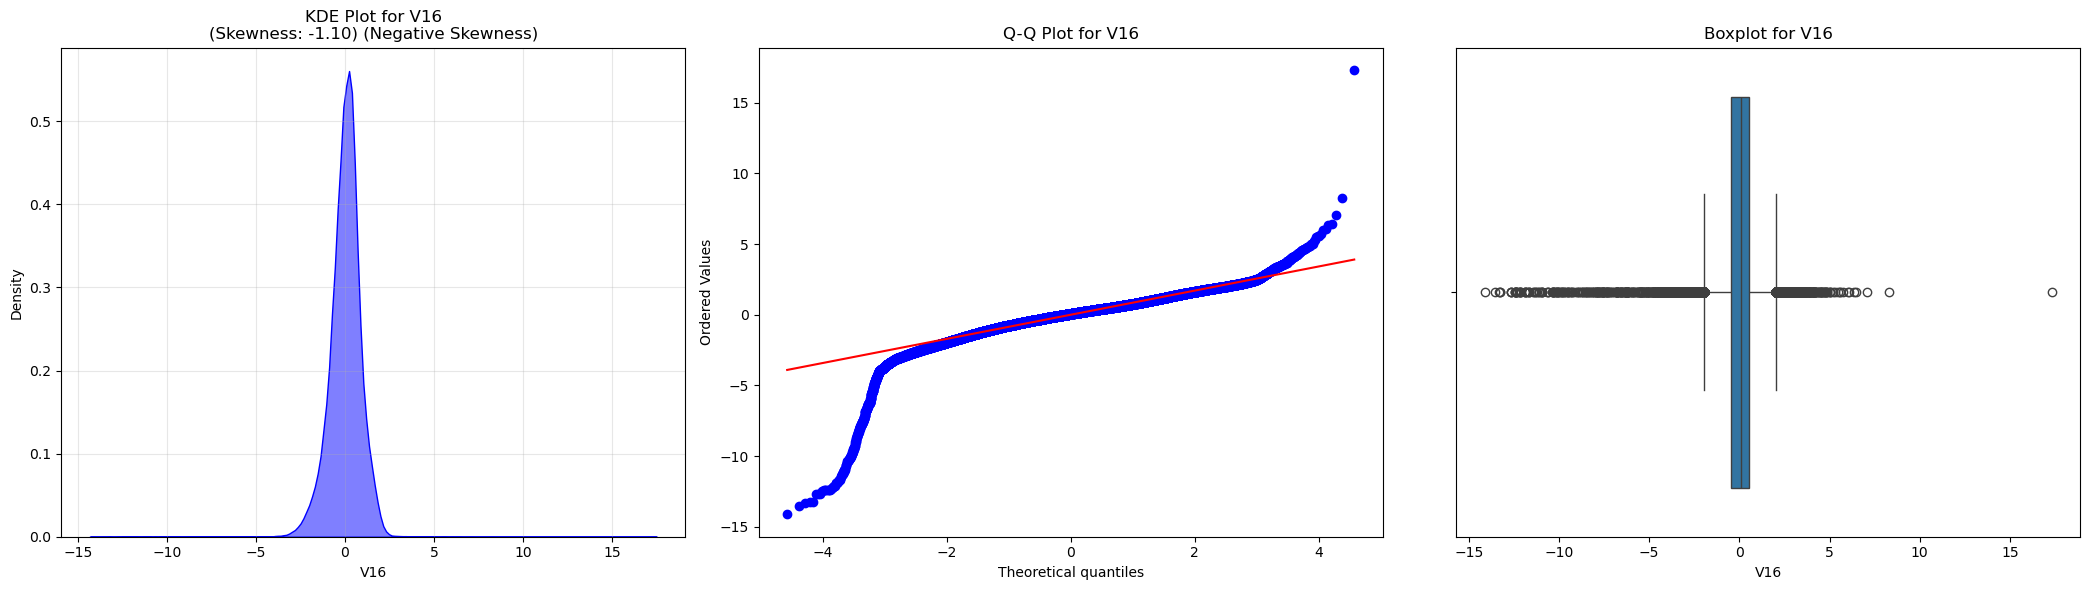

V17: Skewness = -3.84 (Negative Skewness)


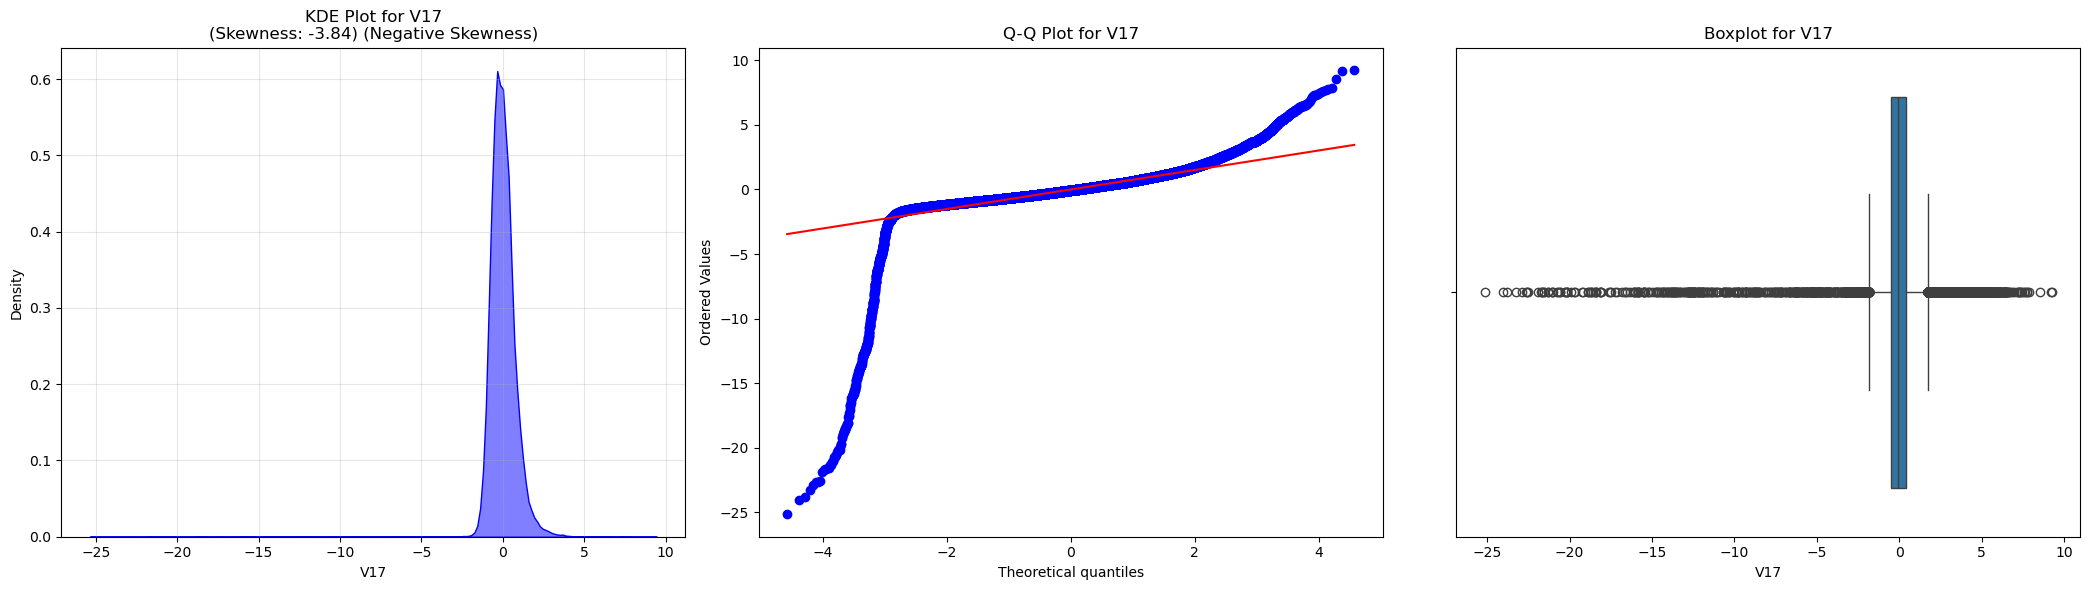

V18: Skewness = -0.26 (Negative Skewness)


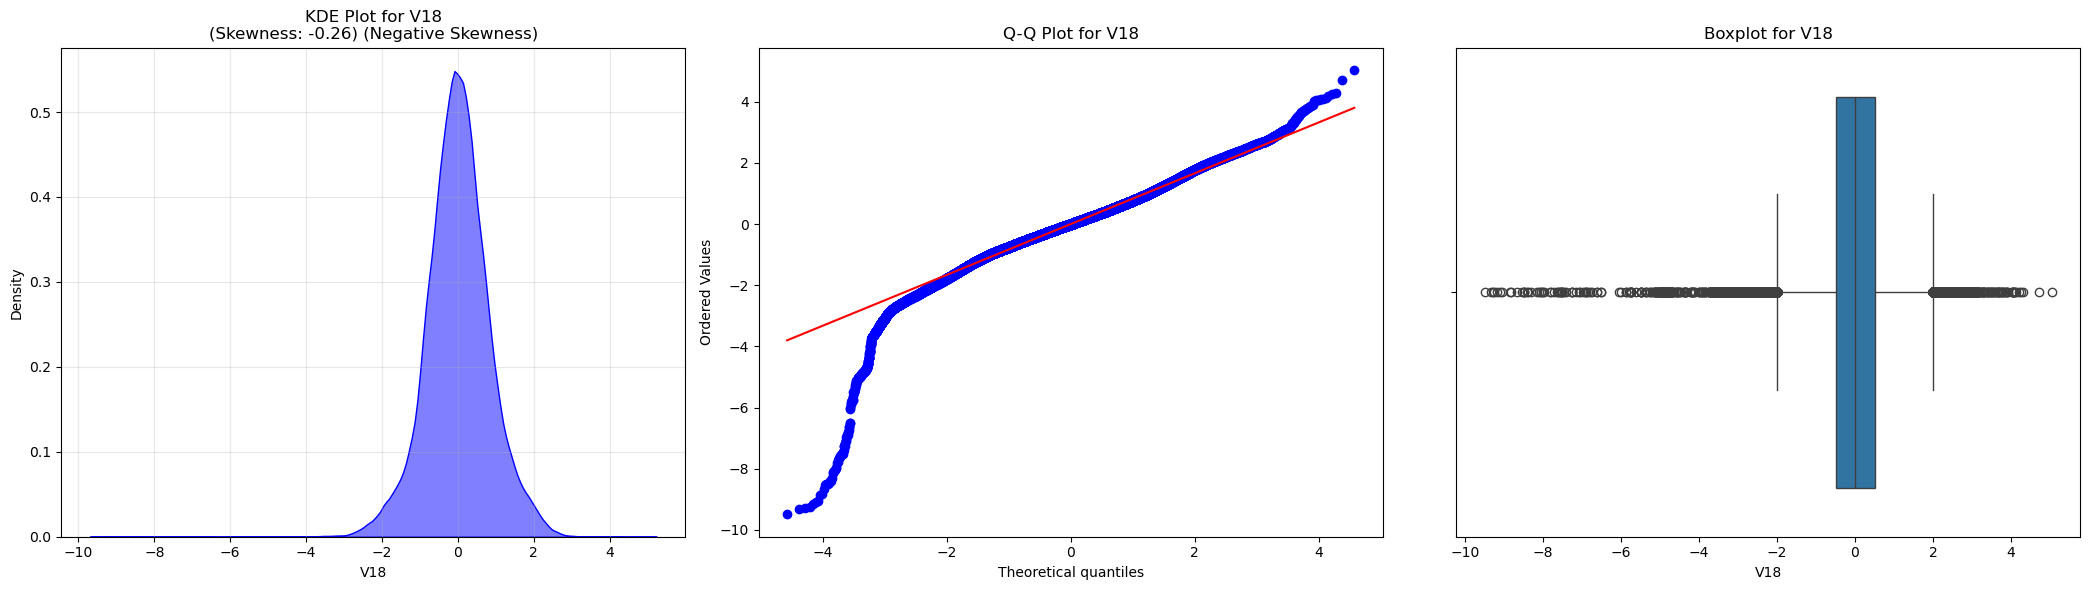

V19: Skewness = 0.11 (Positive Skewness)


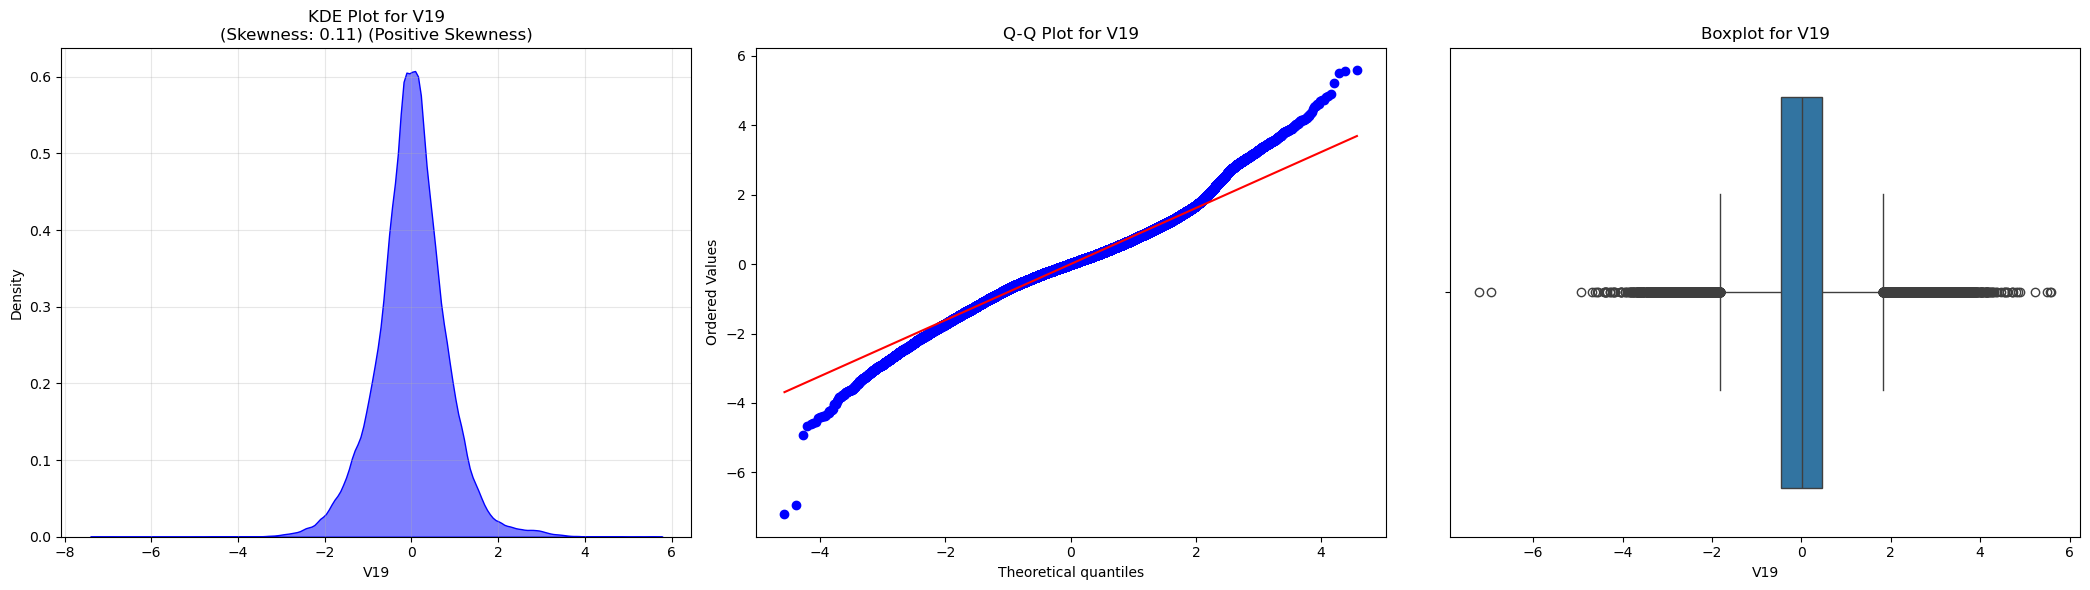

V20: Skewness = -2.04 (Negative Skewness)


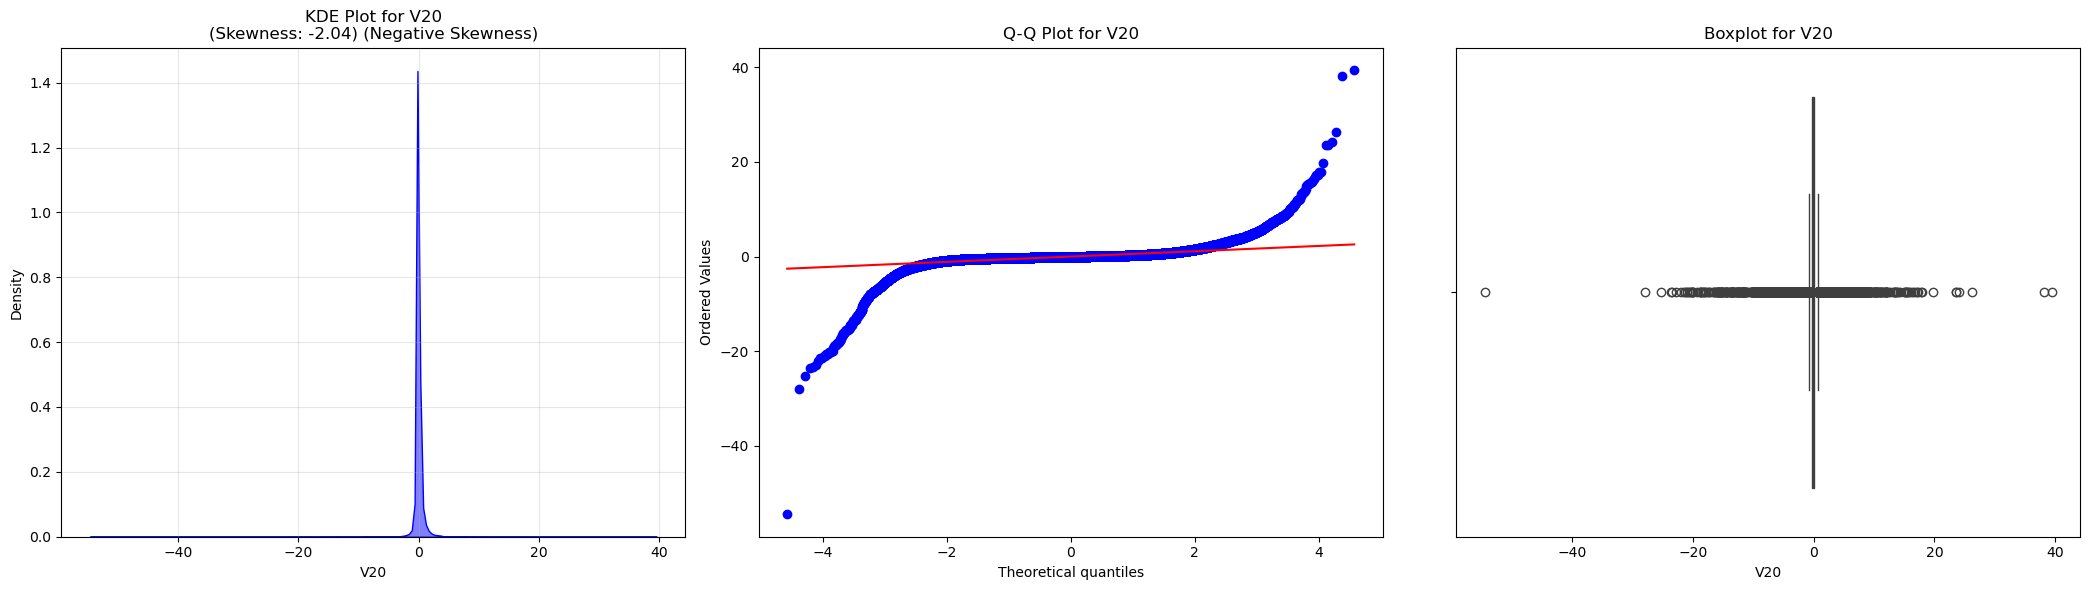

V21: Skewness = 3.59 (Positive Skewness)


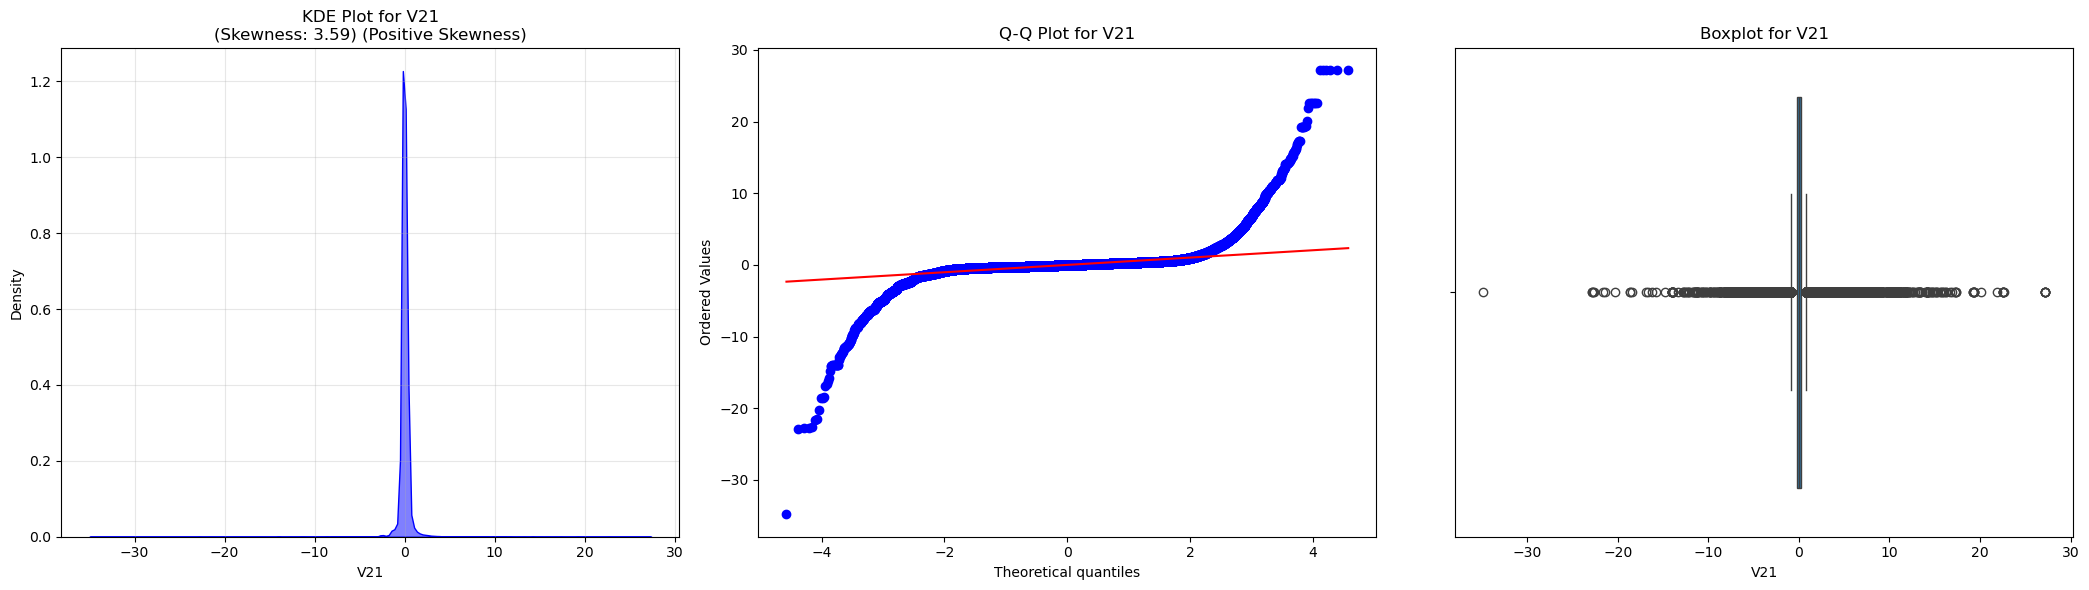

V22: Skewness = -0.21 (Negative Skewness)


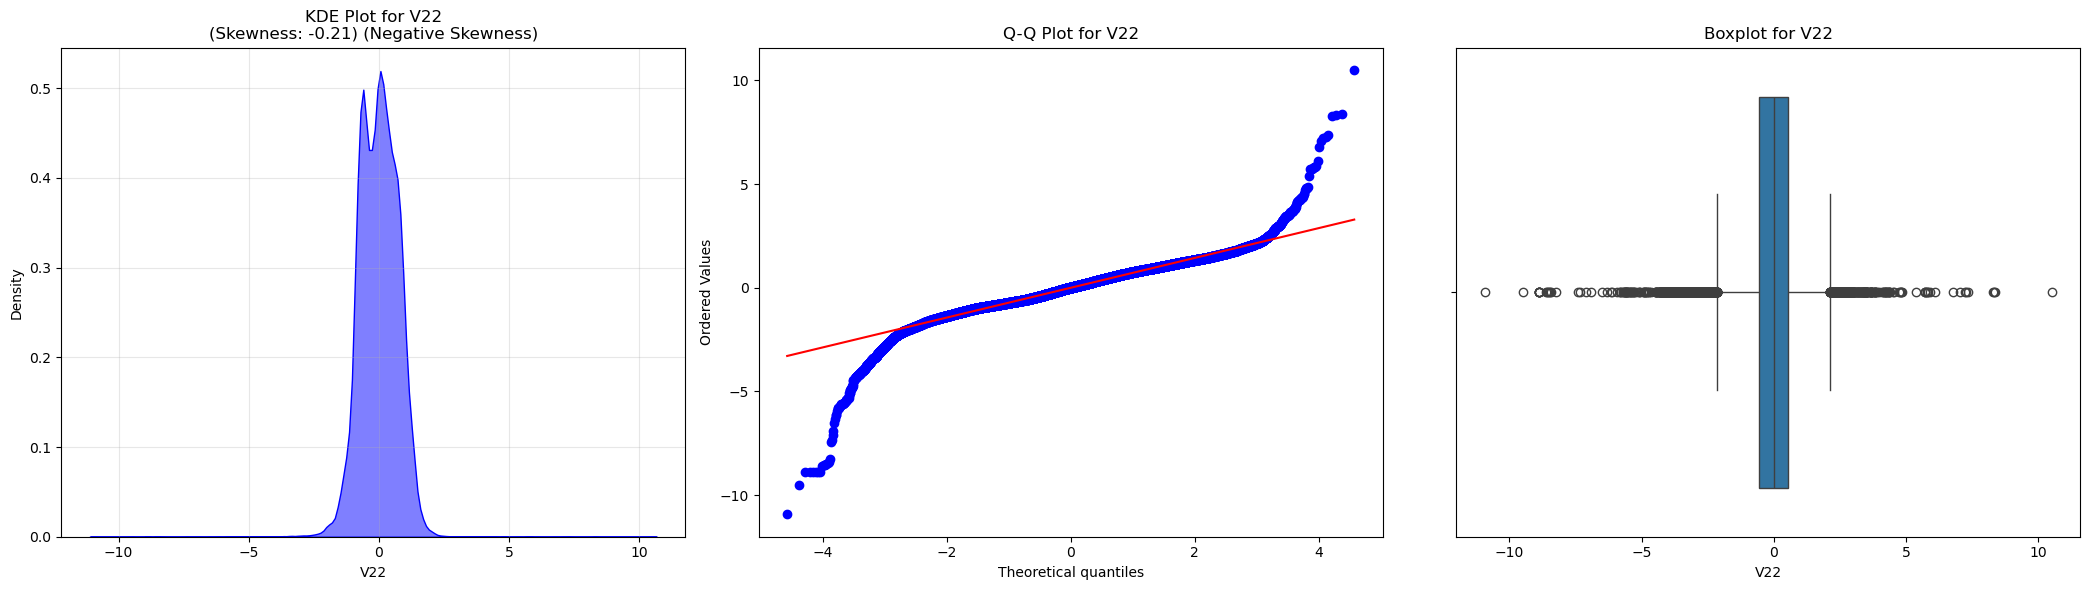

V23: Skewness = -5.88 (Negative Skewness)


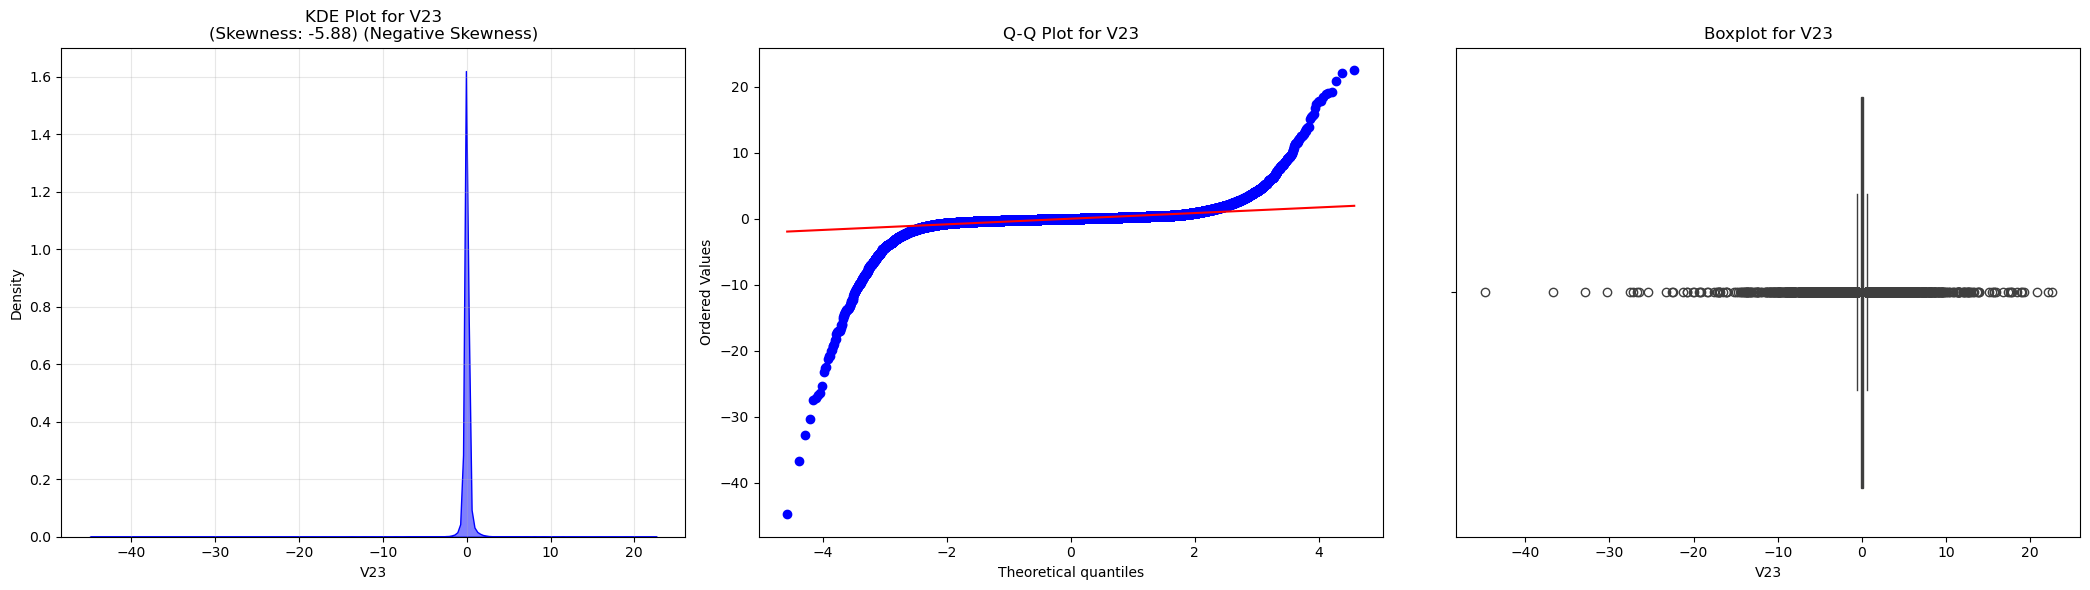

V24: Skewness = -0.55 (Negative Skewness)


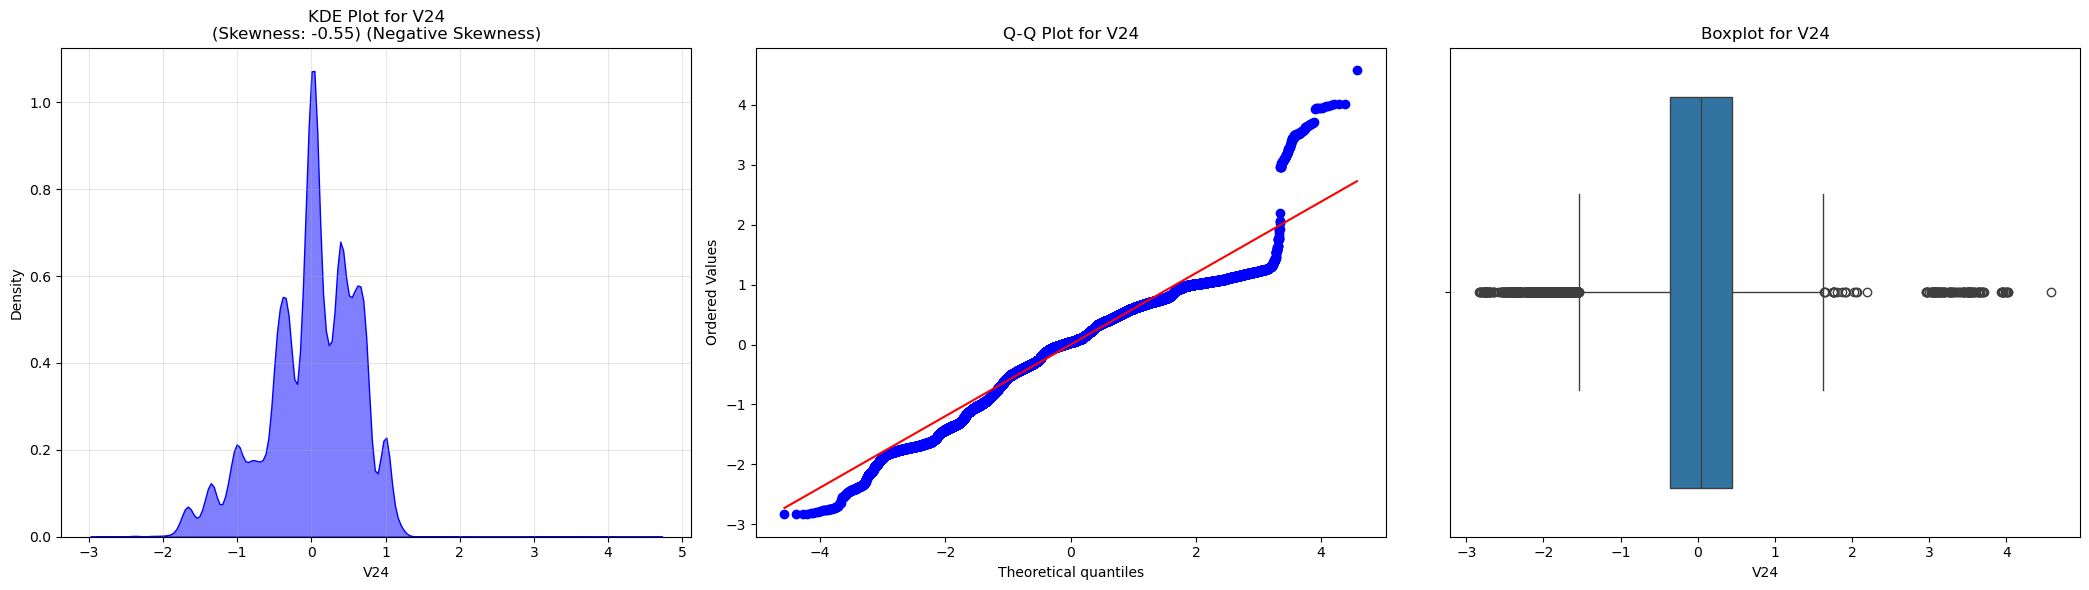

V25: Skewness = -0.42 (Negative Skewness)


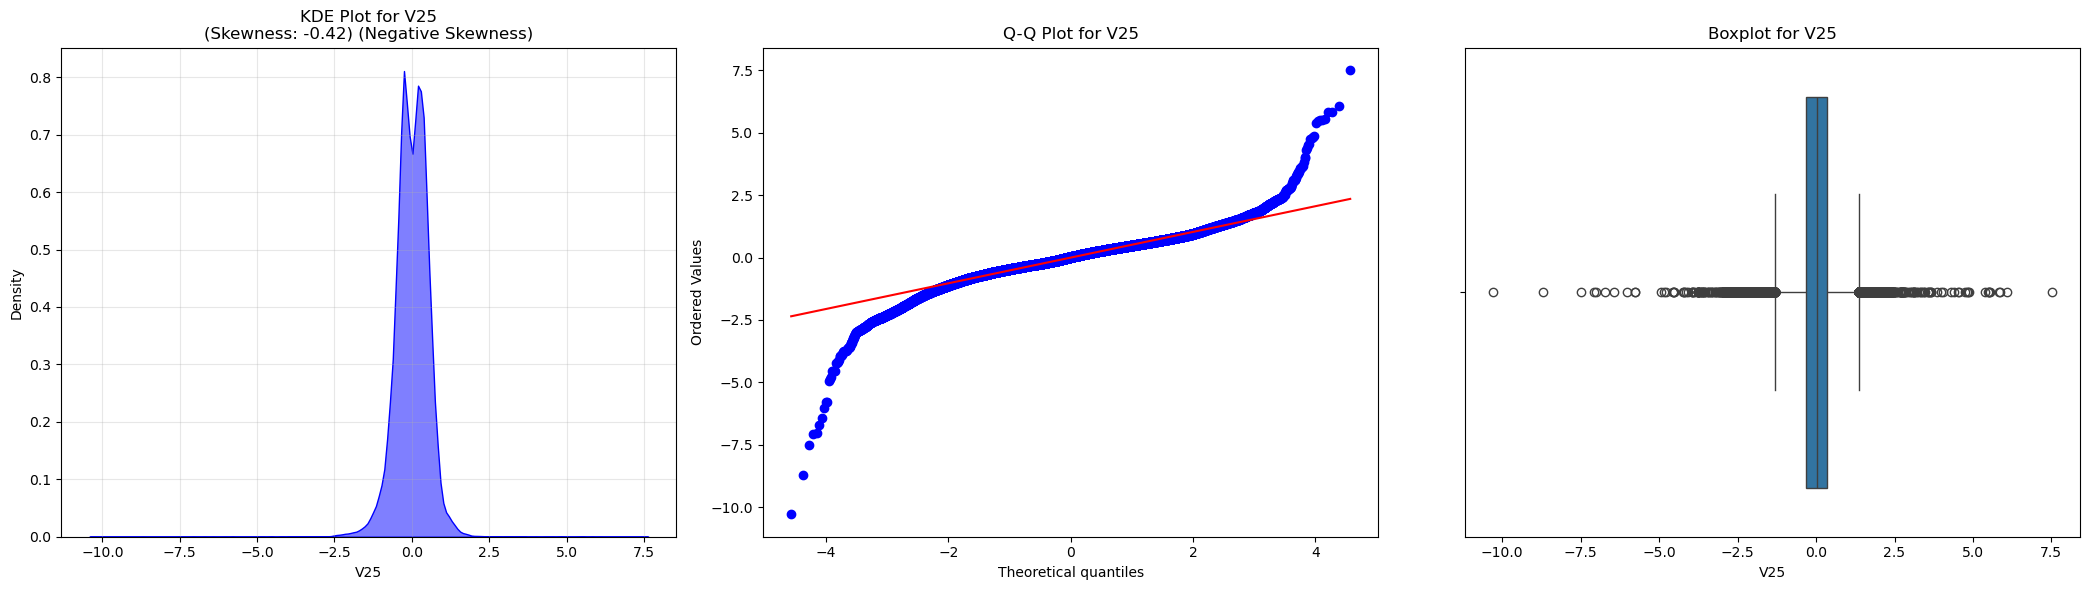

V26: Skewness = 0.58 (Positive Skewness)


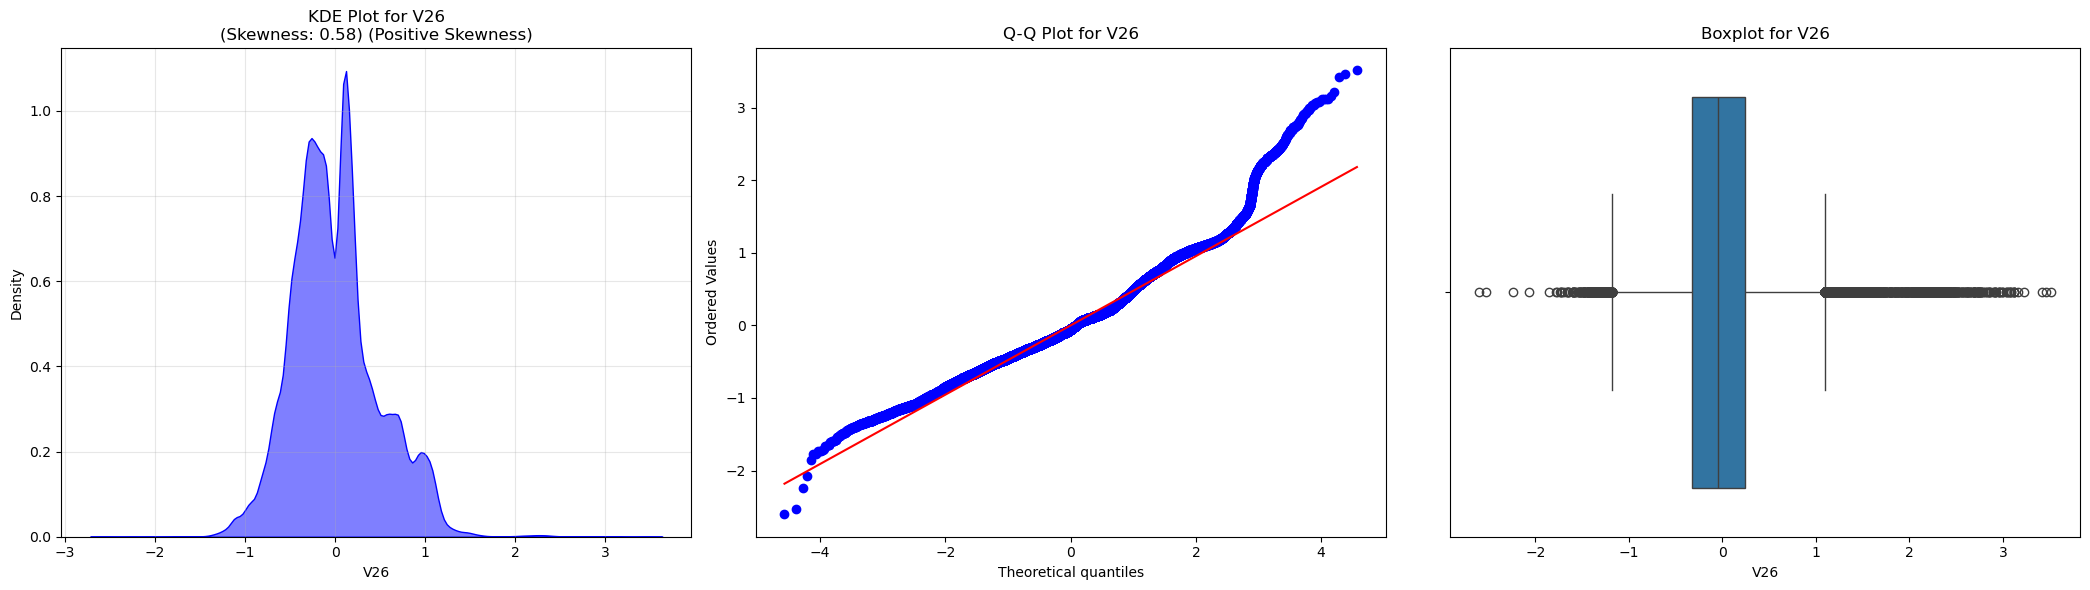

V27: Skewness = -1.17 (Negative Skewness)


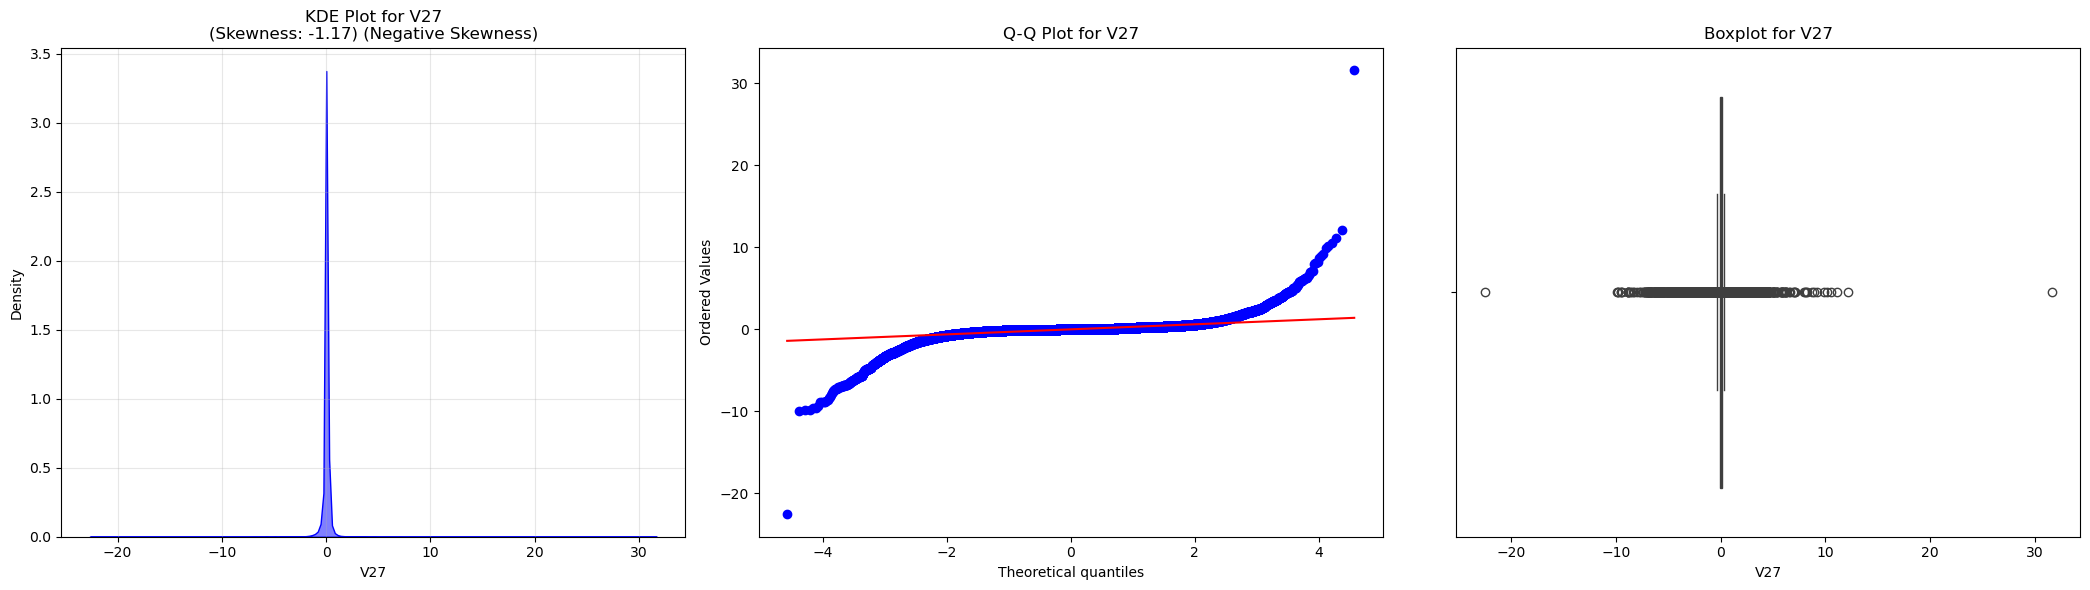

V28: Skewness = 11.19 (Positive Skewness)


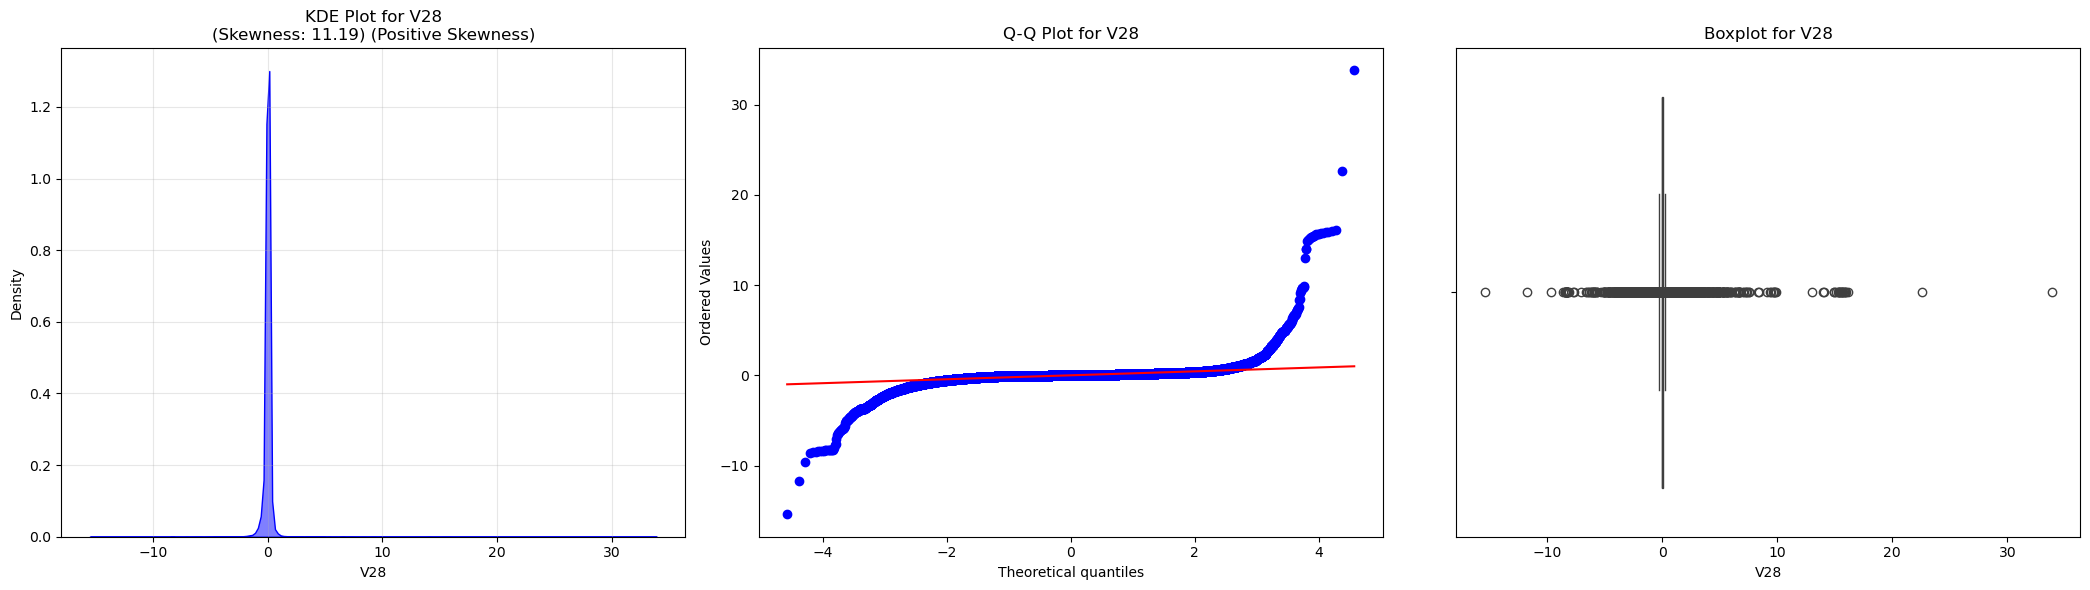

Amount: Skewness = 16.98 (Positive Skewness)


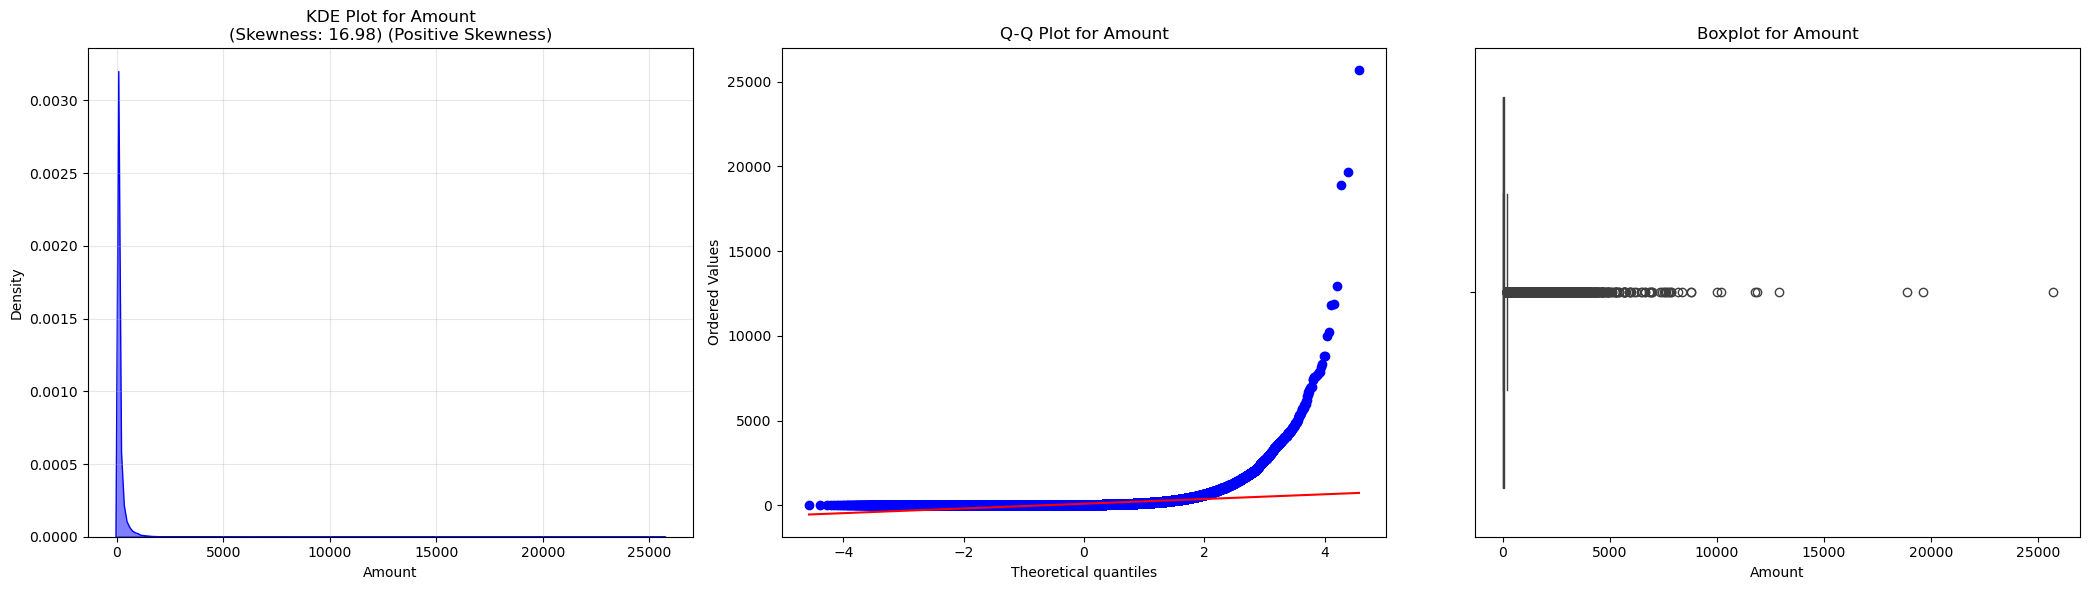

Class: Skewness = 24.00 (Positive Skewness)


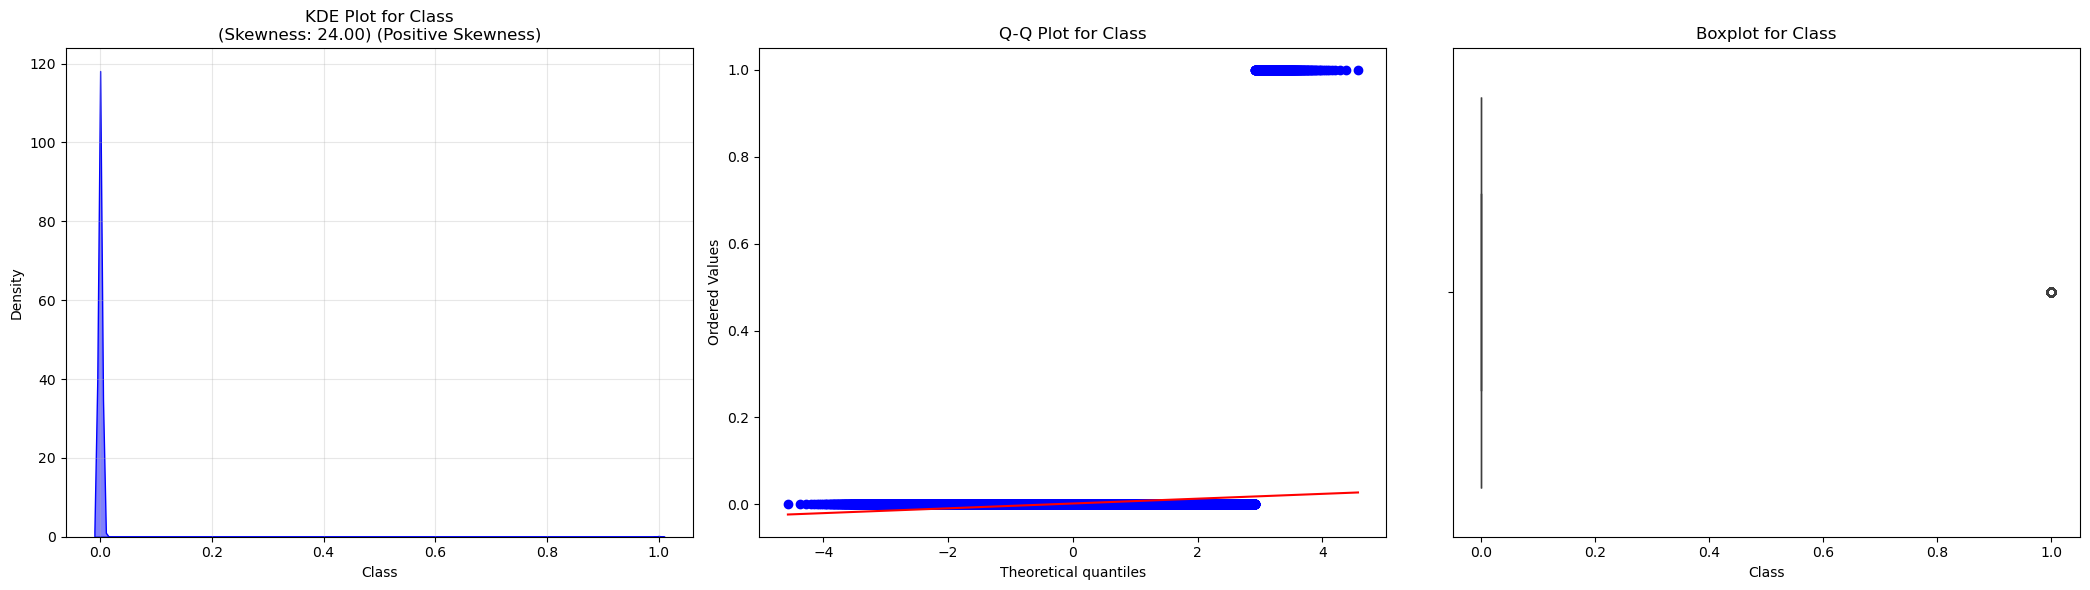

In [11]:
All_plot(df)

In [41]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
X_tr = pt.fit_transform(X)
X_trd = pd.DataFrame(X_tr,index=X.index,columns=X.columns)
pd.DataFrame({'cols':X.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Time,0.770251
1,V1,1.483054
2,V2,1.211816
3,V3,1.341394
4,V4,0.822124
5,V5,1.031670
6,V6,0.712979
7,V7,1.000564
8,V8,1.288290
9,V9,0.849492


Time: Skewness = -0.23 (Negative Skewness)


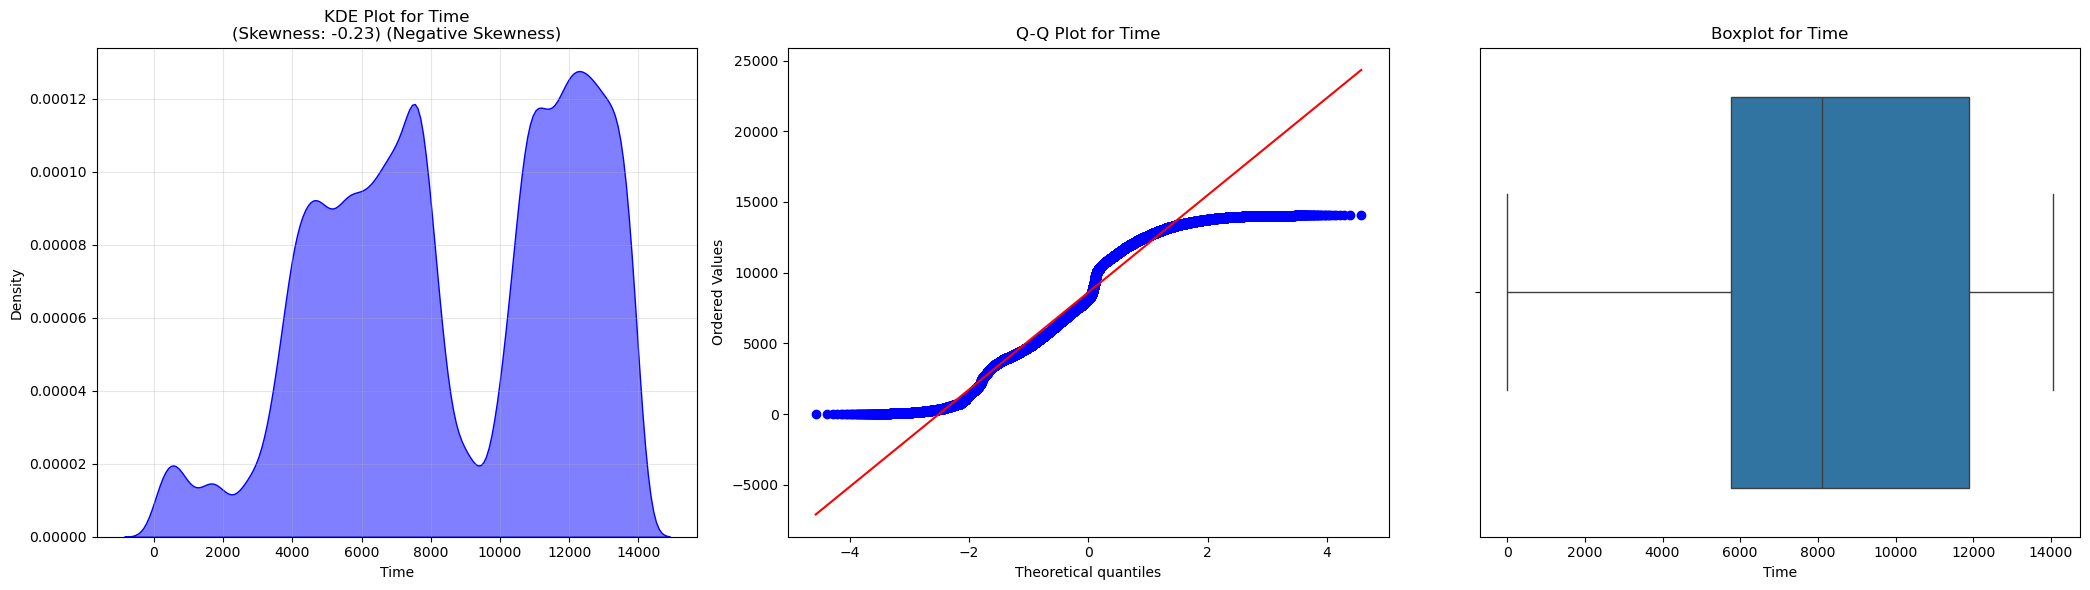

V1: Skewness = -0.22 (Negative Skewness)


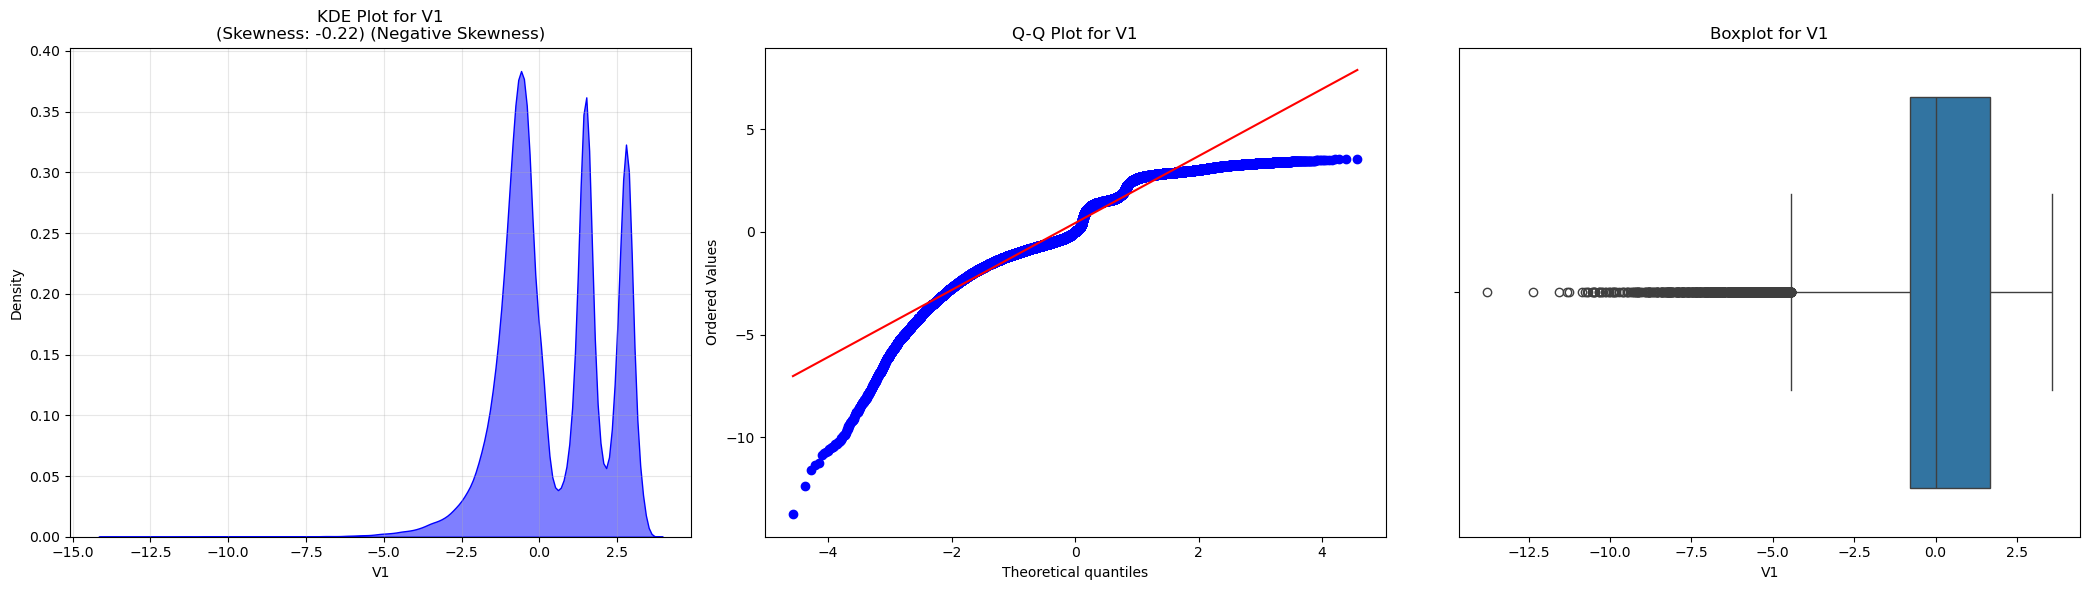

V2: Skewness = 0.33 (Positive Skewness)


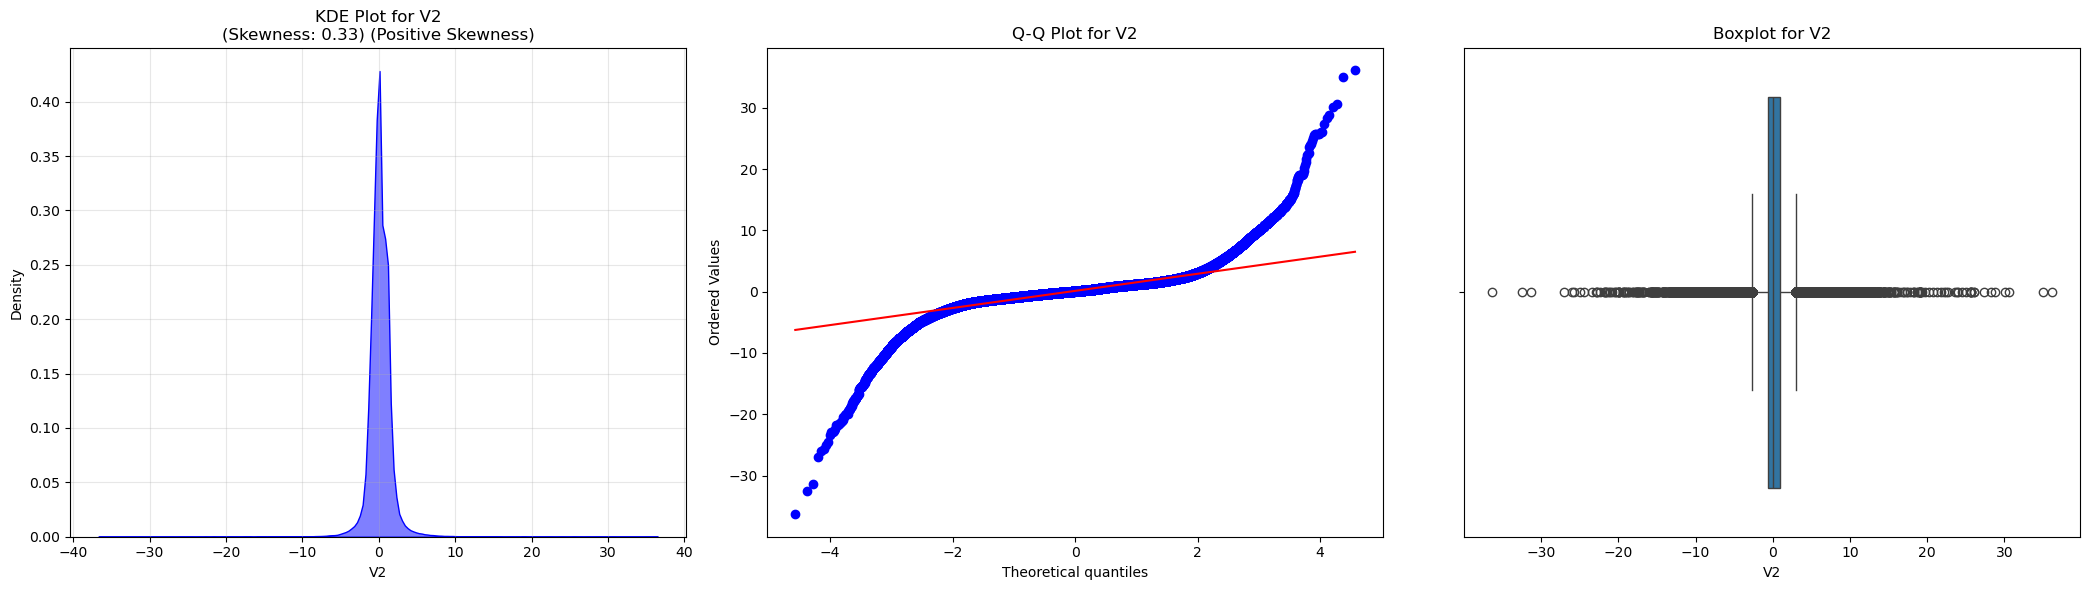

V3: Skewness = -0.08 (Negative Skewness)


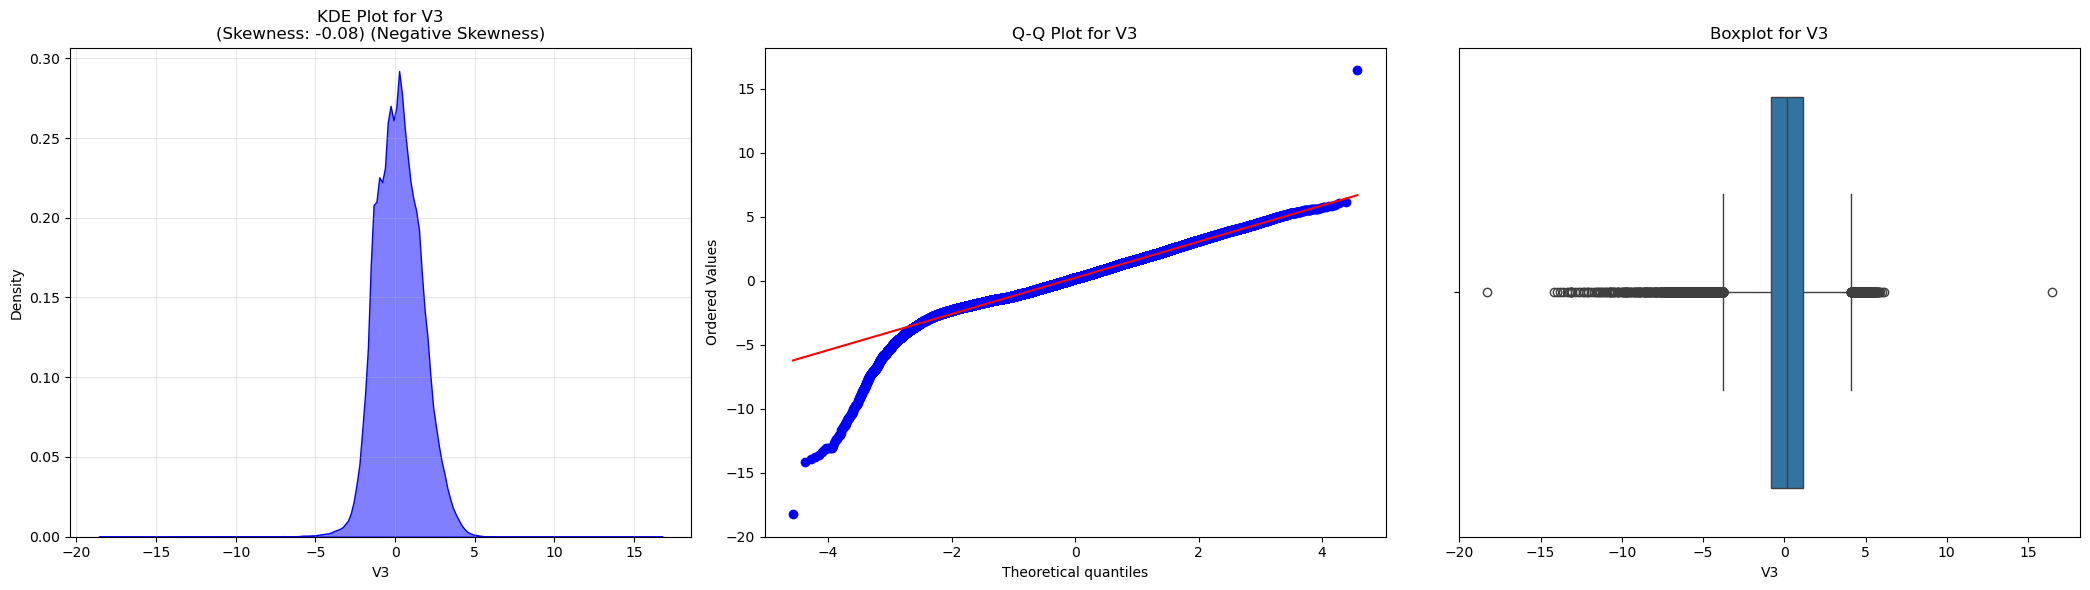

V4: Skewness = 0.02 (Positive Skewness)


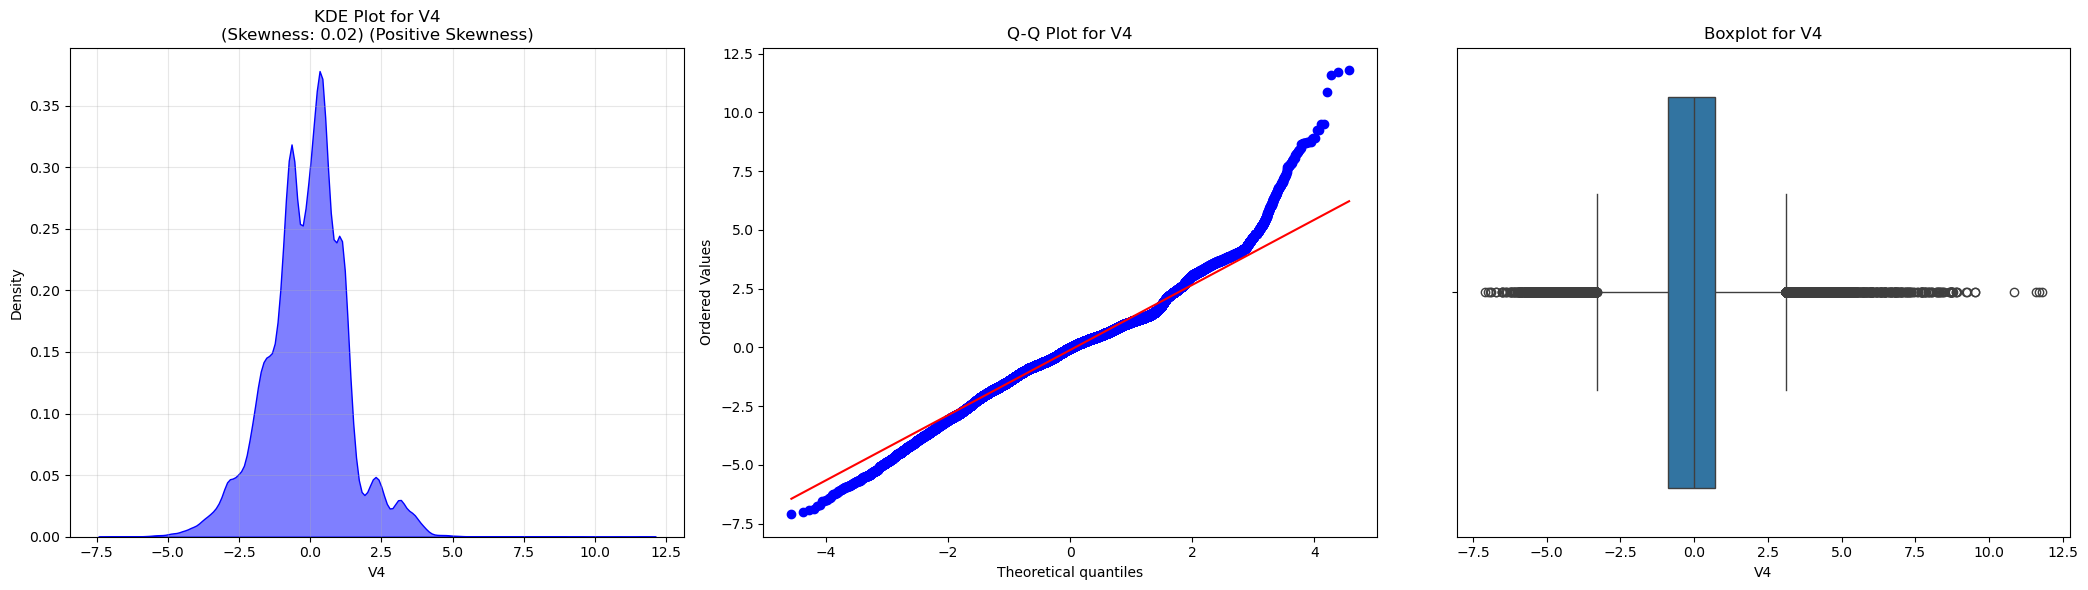

V5: Skewness = -1.17 (Negative Skewness)


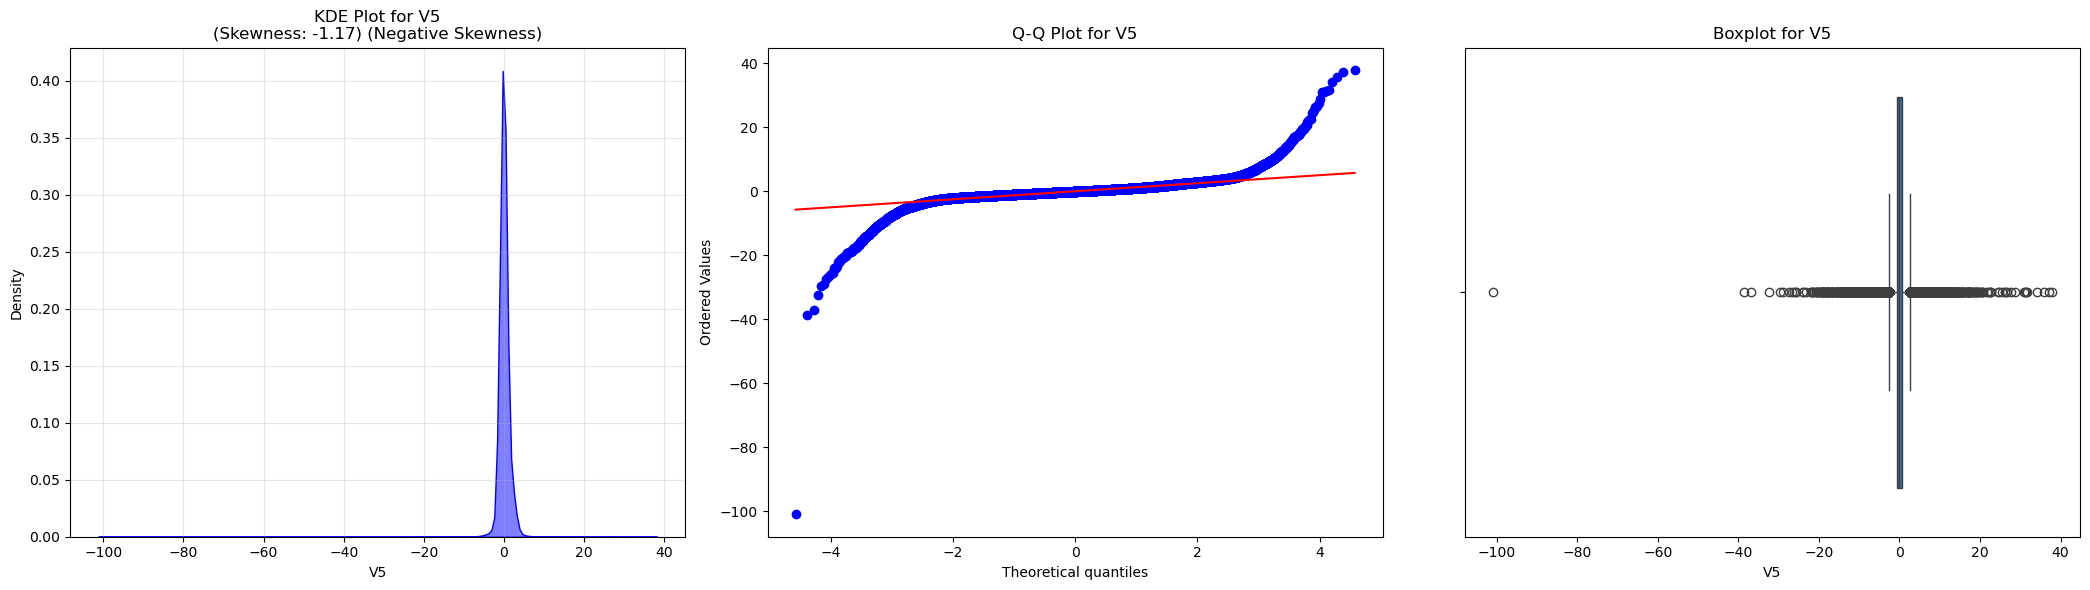

V6: Skewness = -1.94 (Negative Skewness)


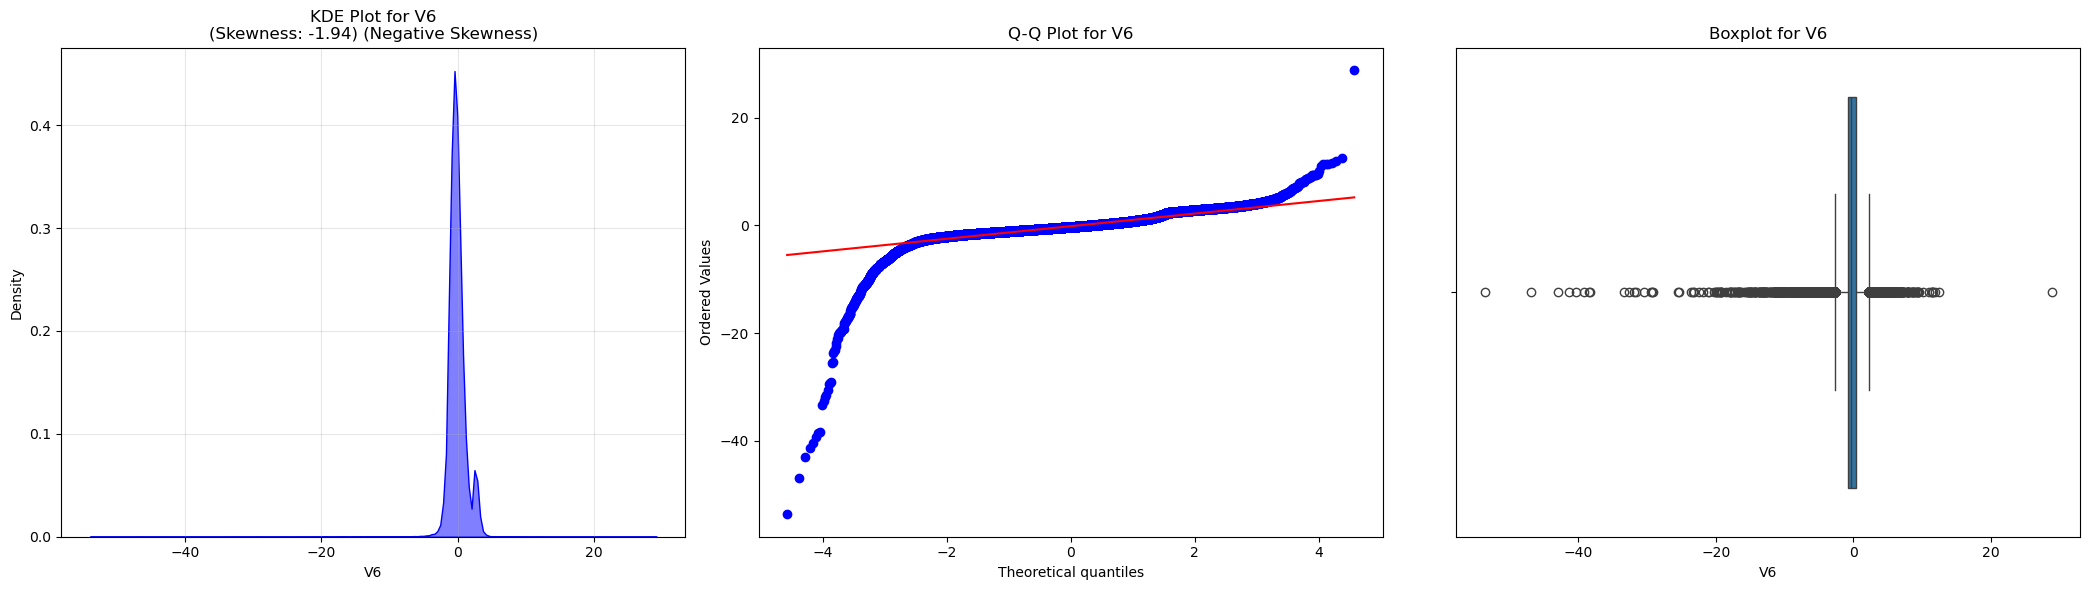

V7: Skewness = 2.59 (Positive Skewness)


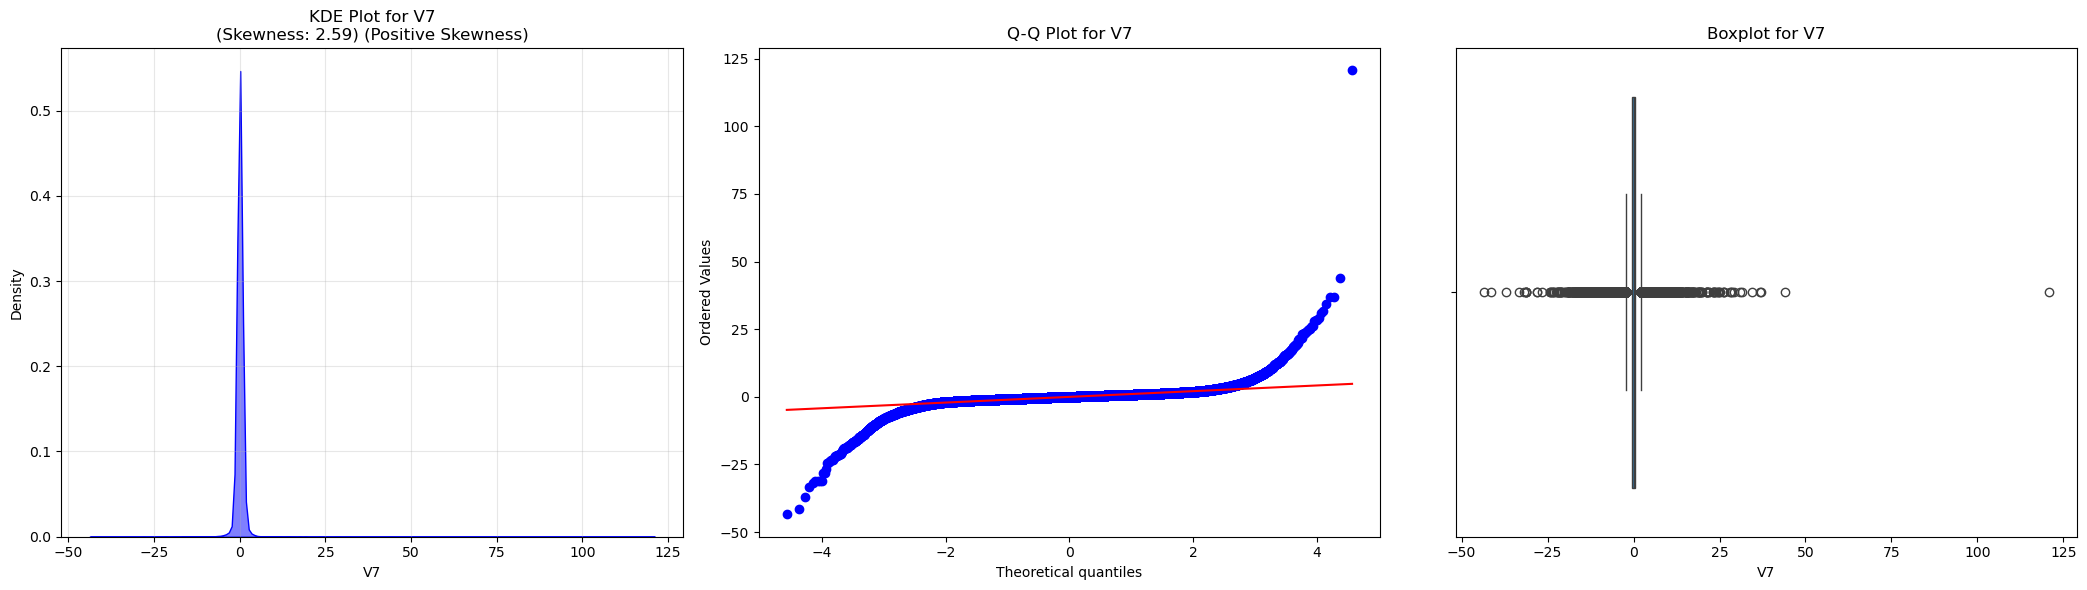

V8: Skewness = 2.30 (Positive Skewness)


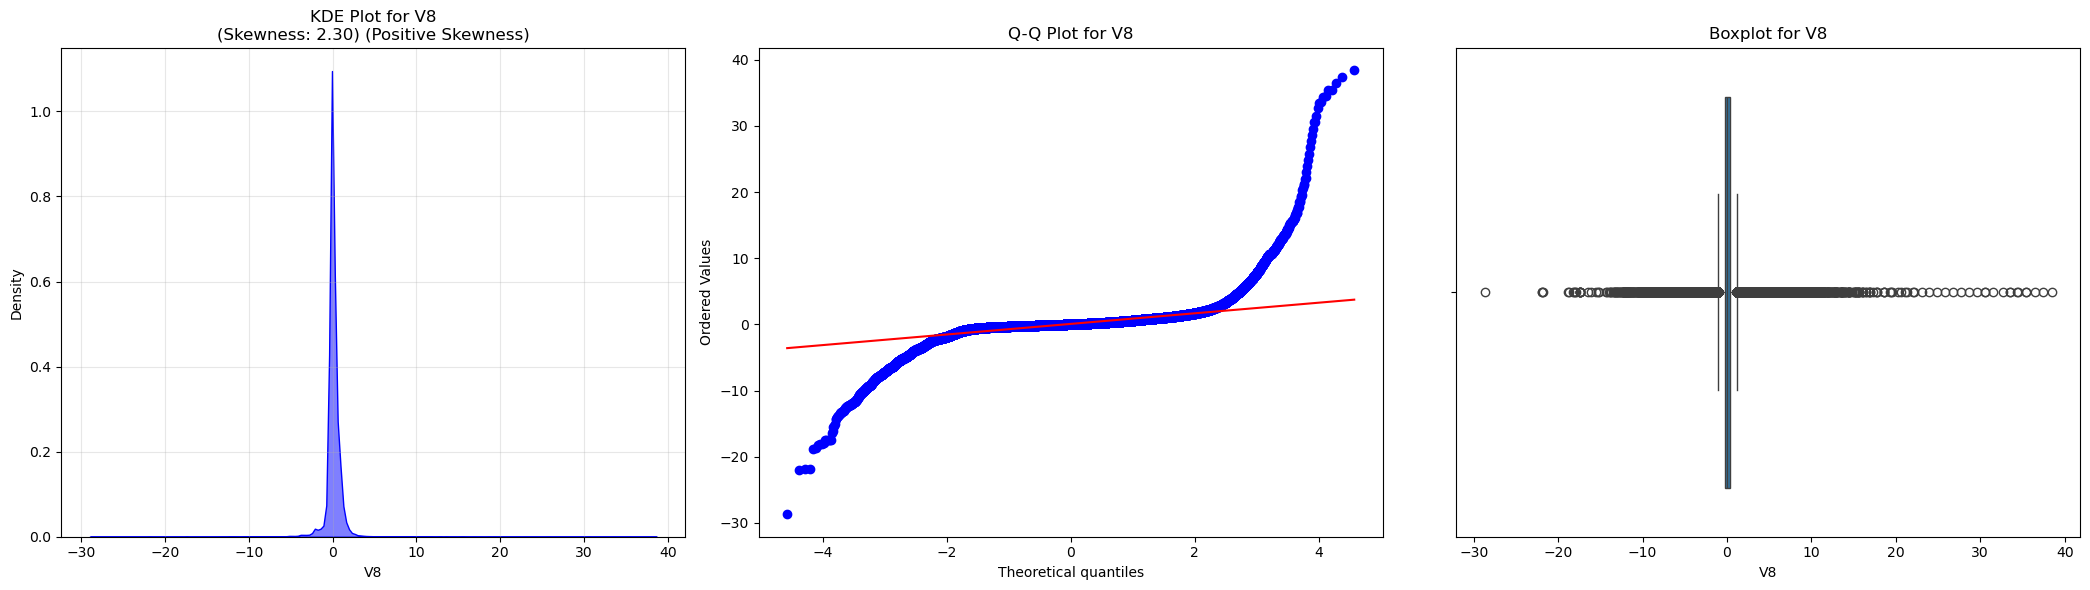

V9: Skewness = -0.05 (Negative Skewness)


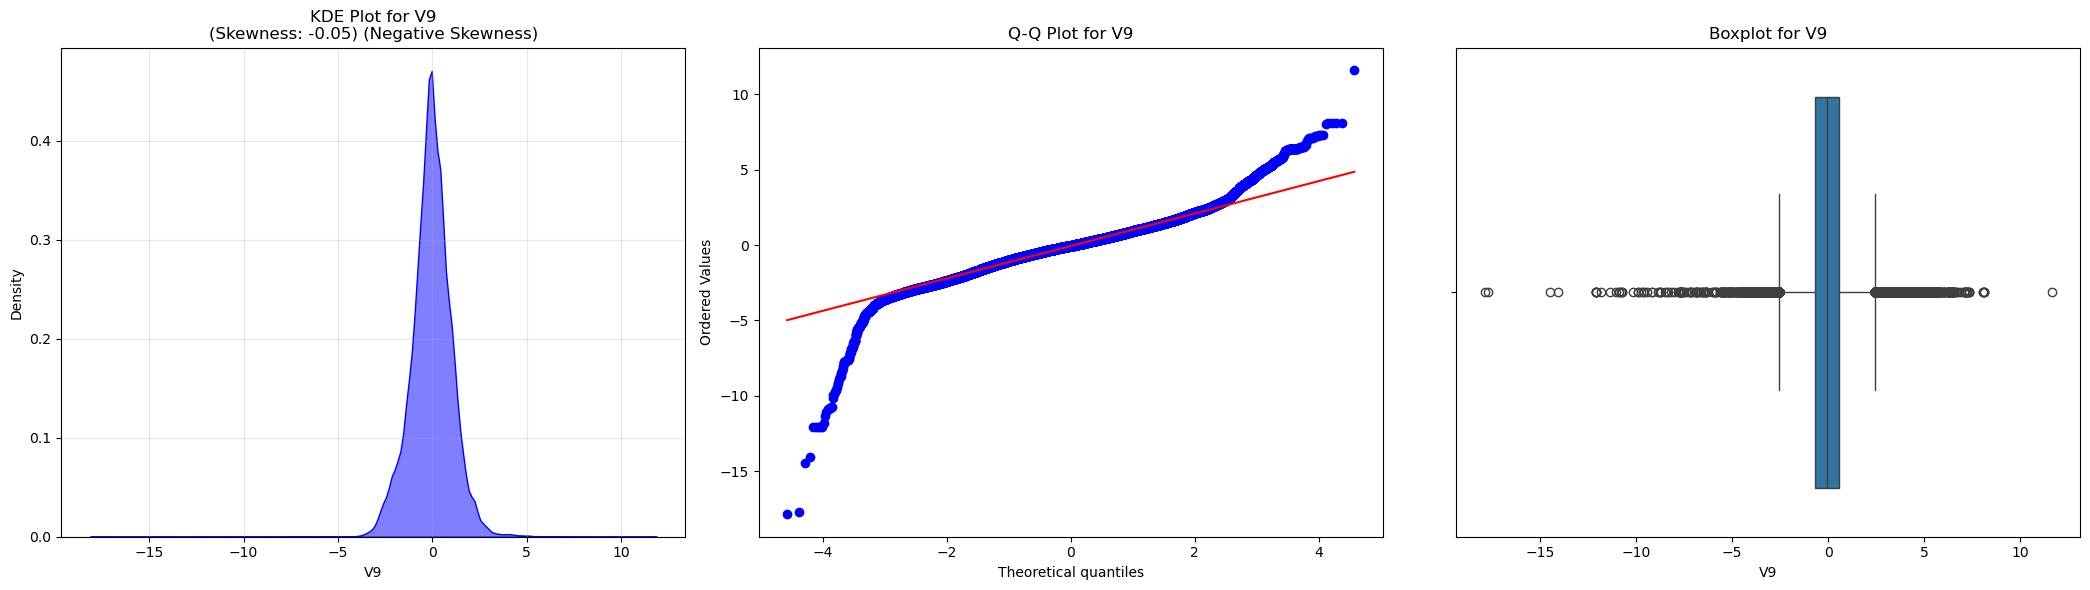

V10: Skewness = -1.32 (Negative Skewness)


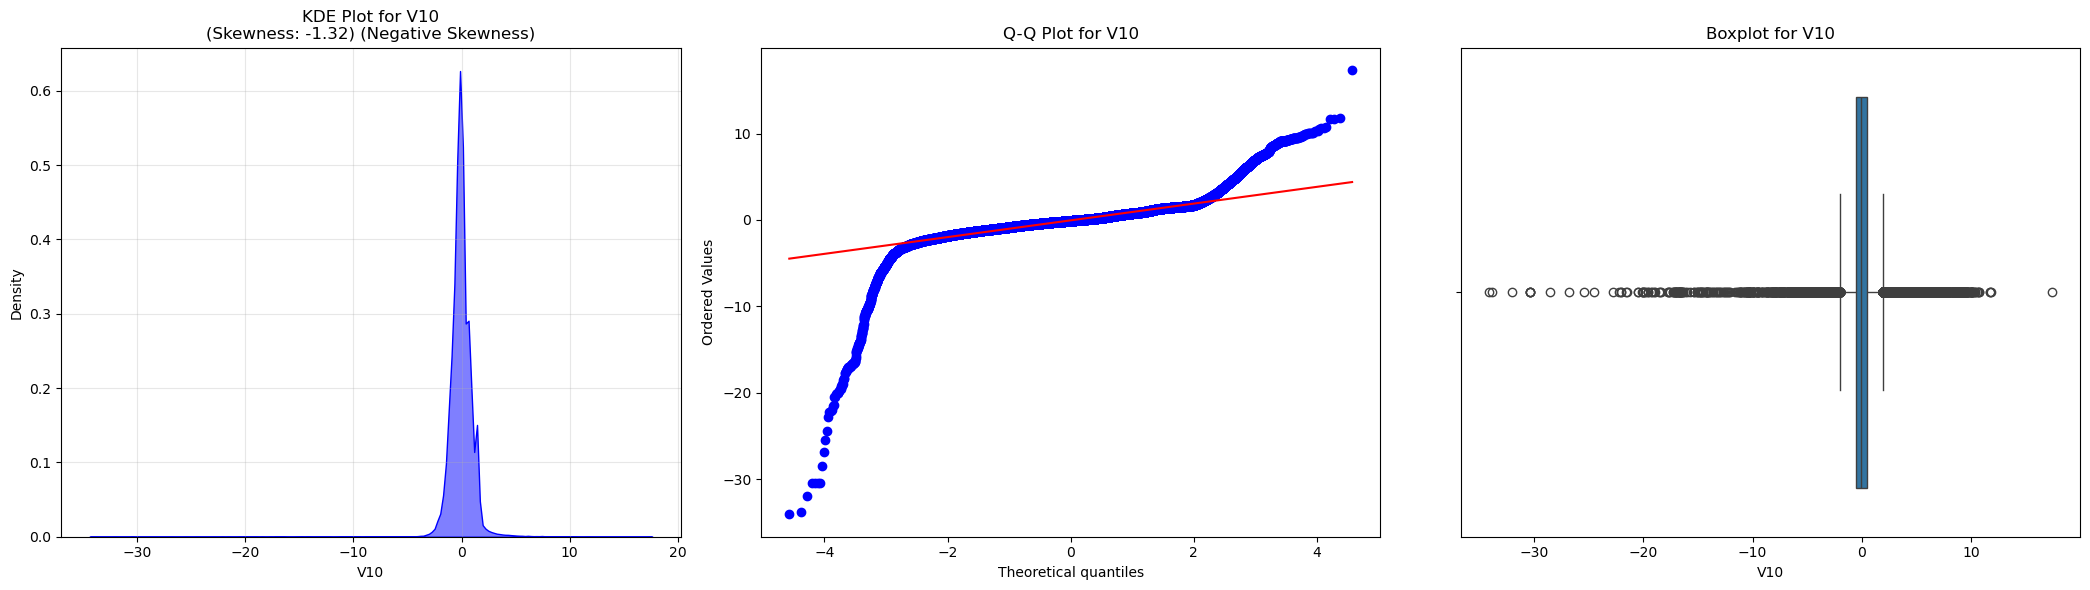

V11: Skewness = 0.06 (Positive Skewness)


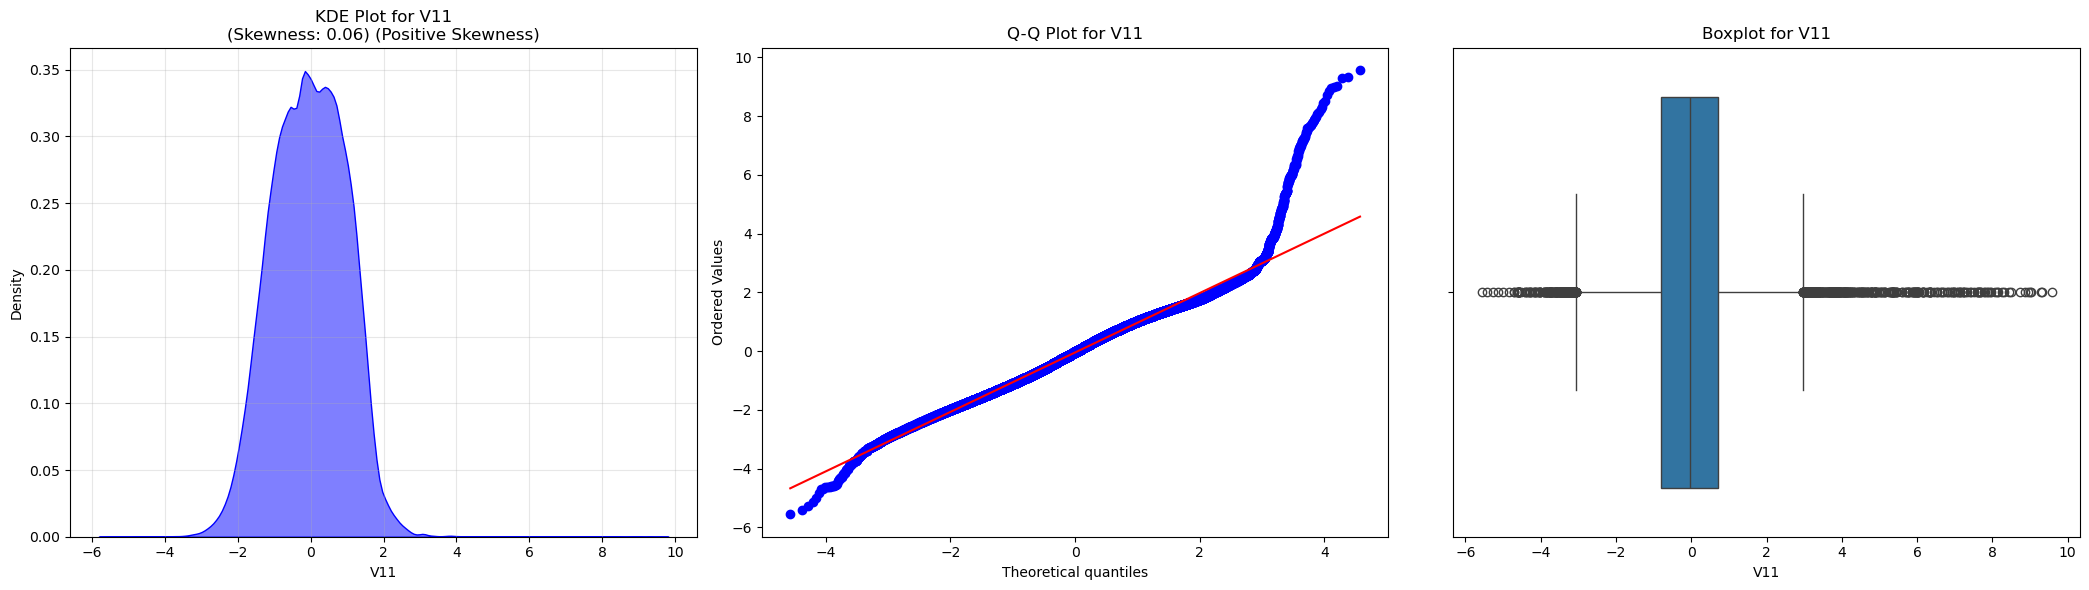

V12: Skewness = 0.16 (Positive Skewness)


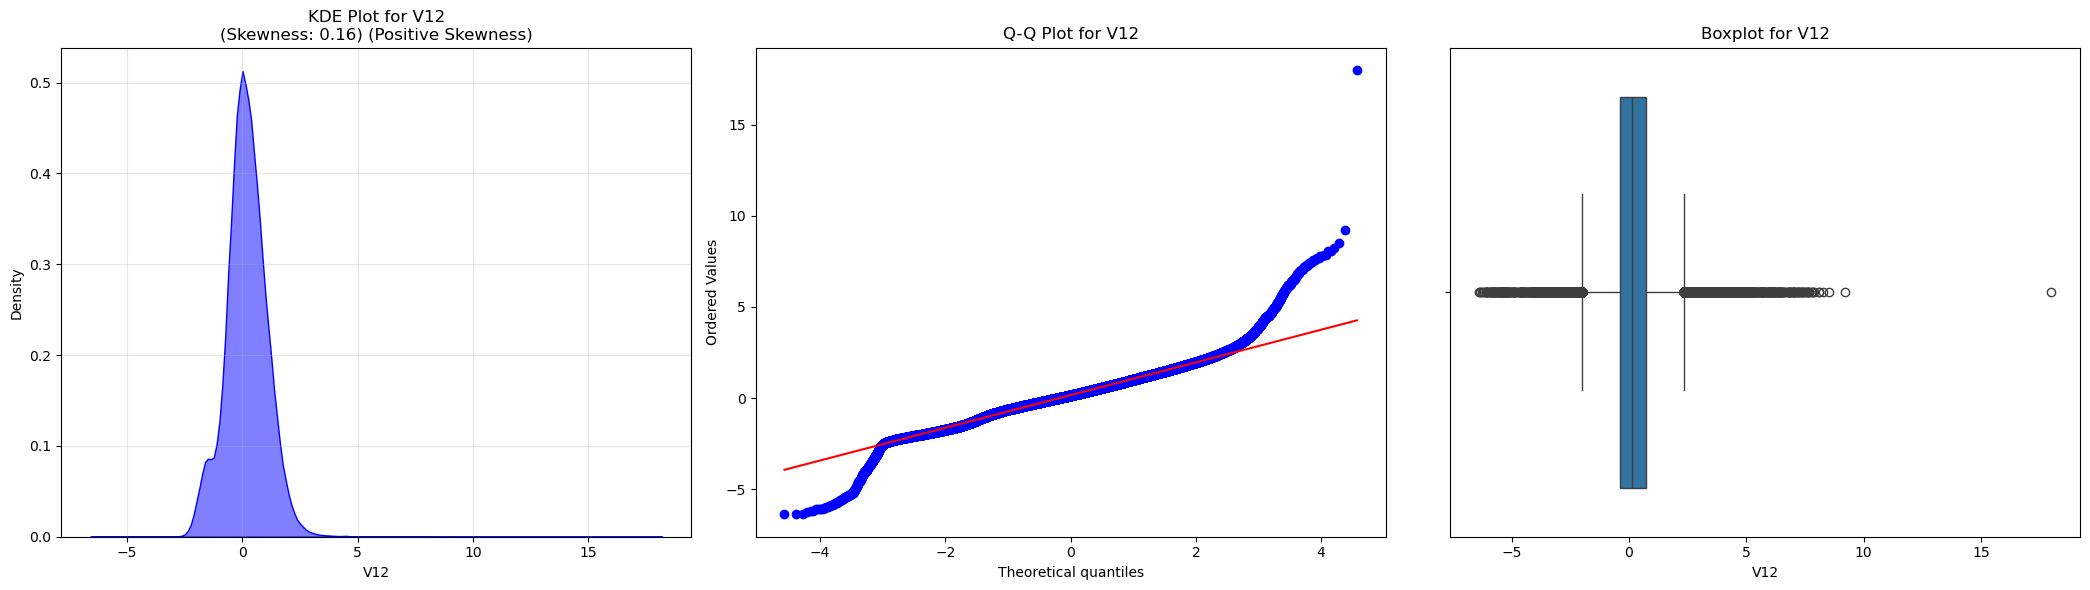

V13: Skewness = 0.01 (Positive Skewness)


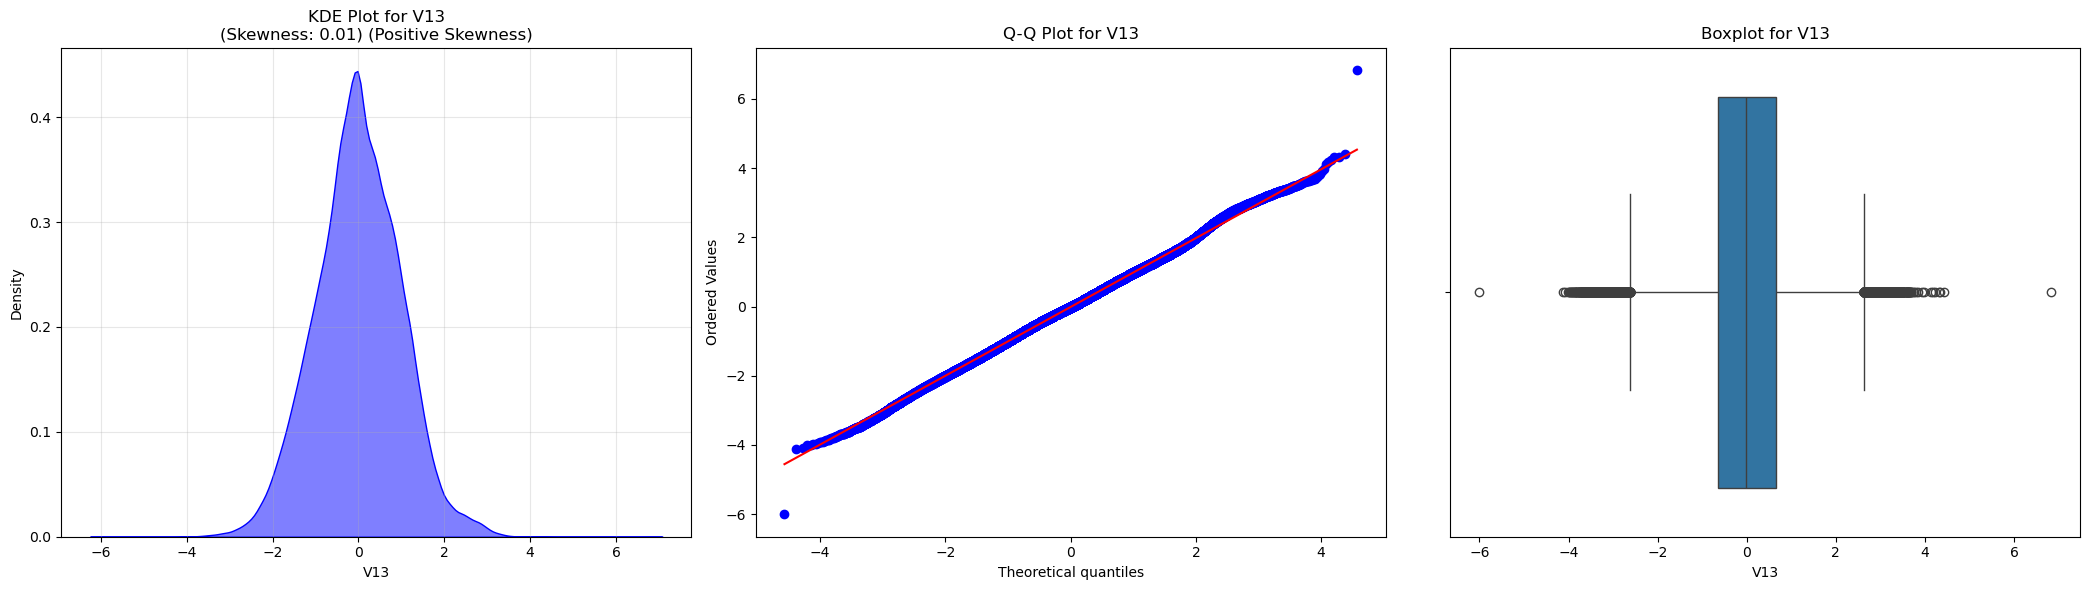

V14: Skewness = 0.11 (Positive Skewness)


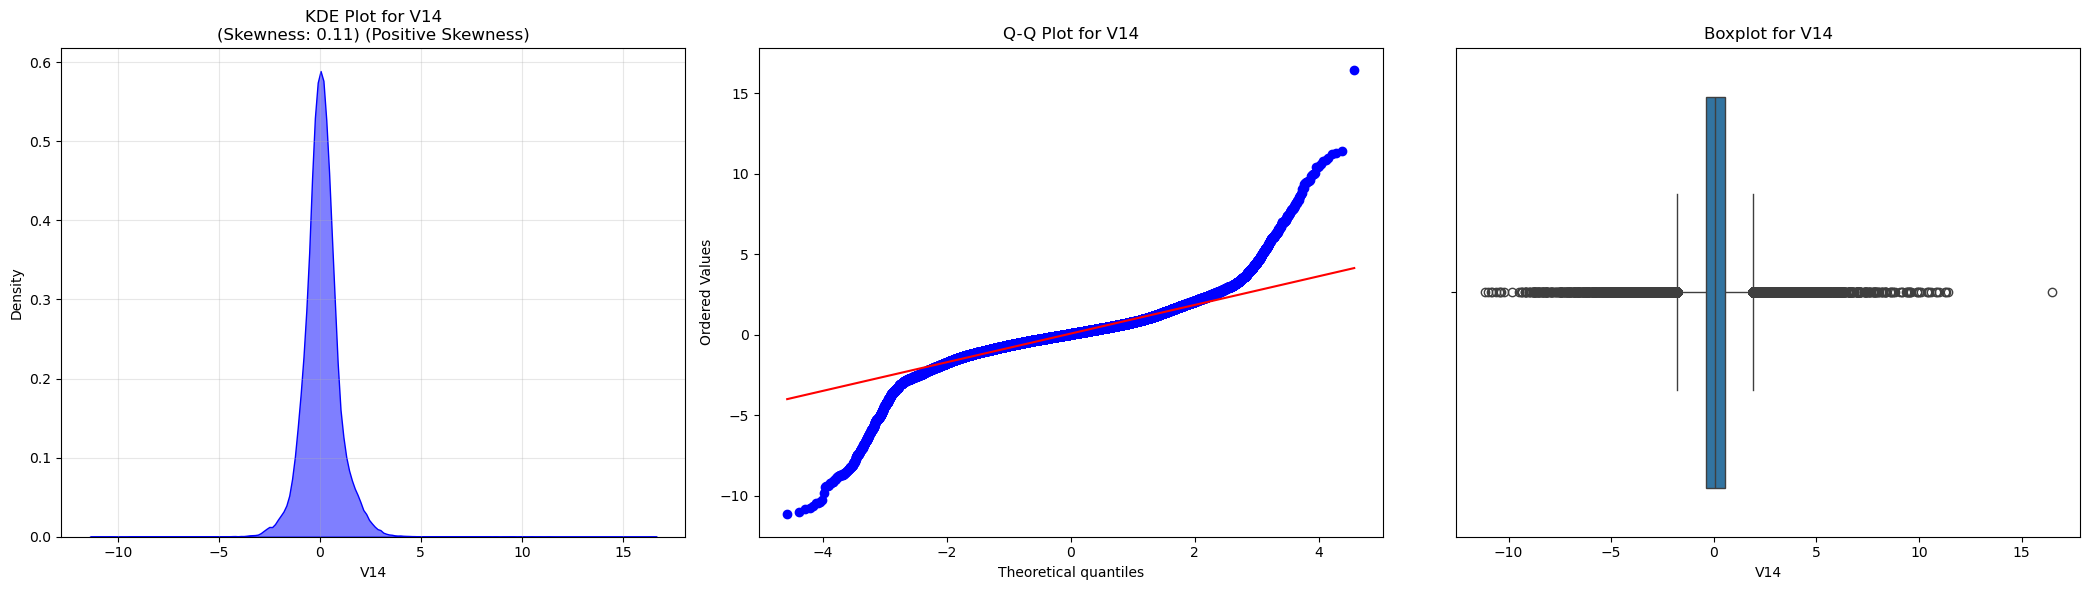

V15: Skewness = 0.01 (Positive Skewness)


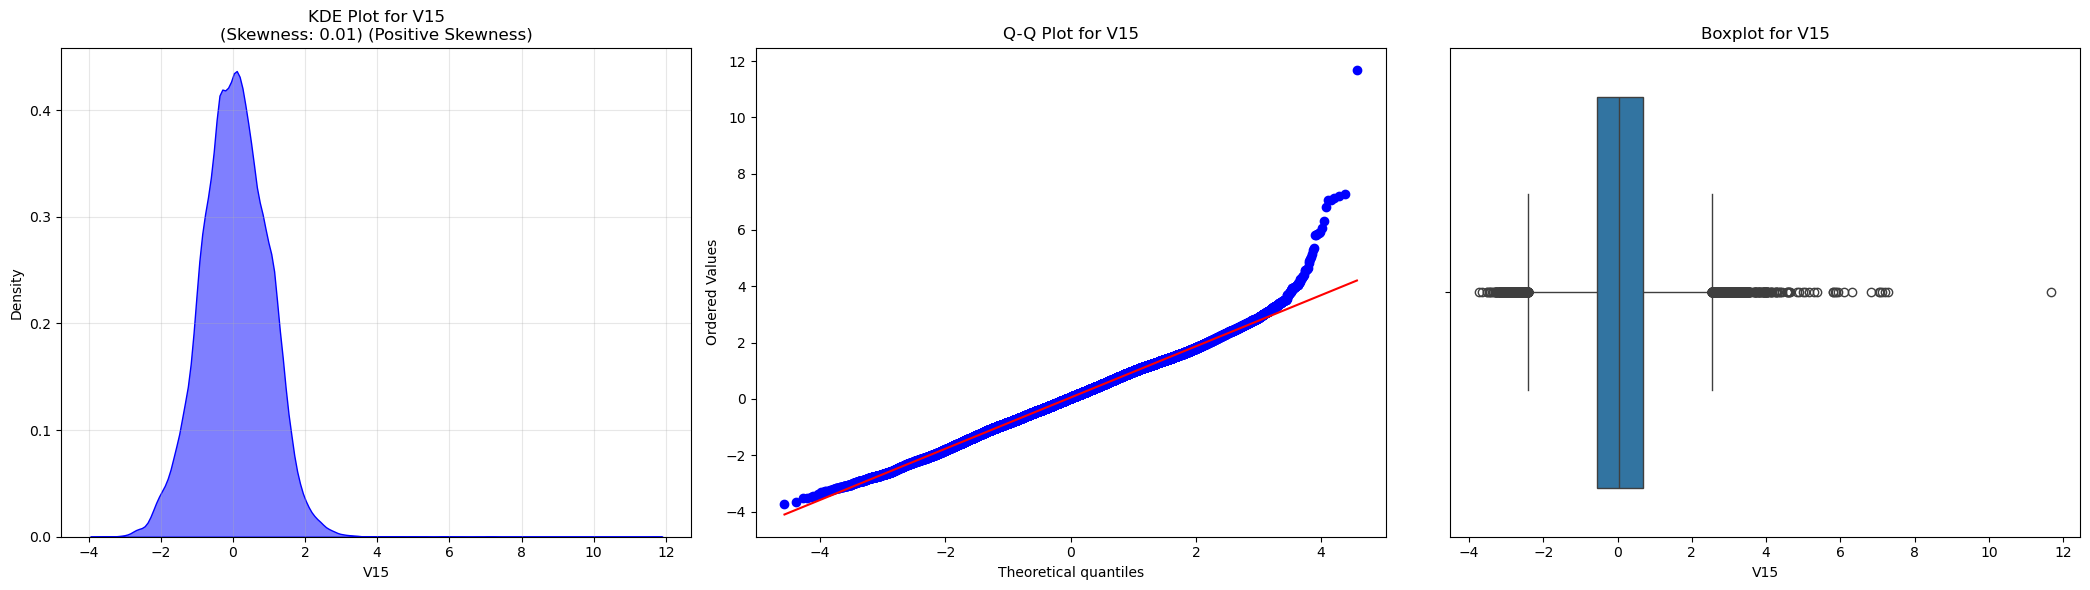

V16: Skewness = 0.14 (Positive Skewness)


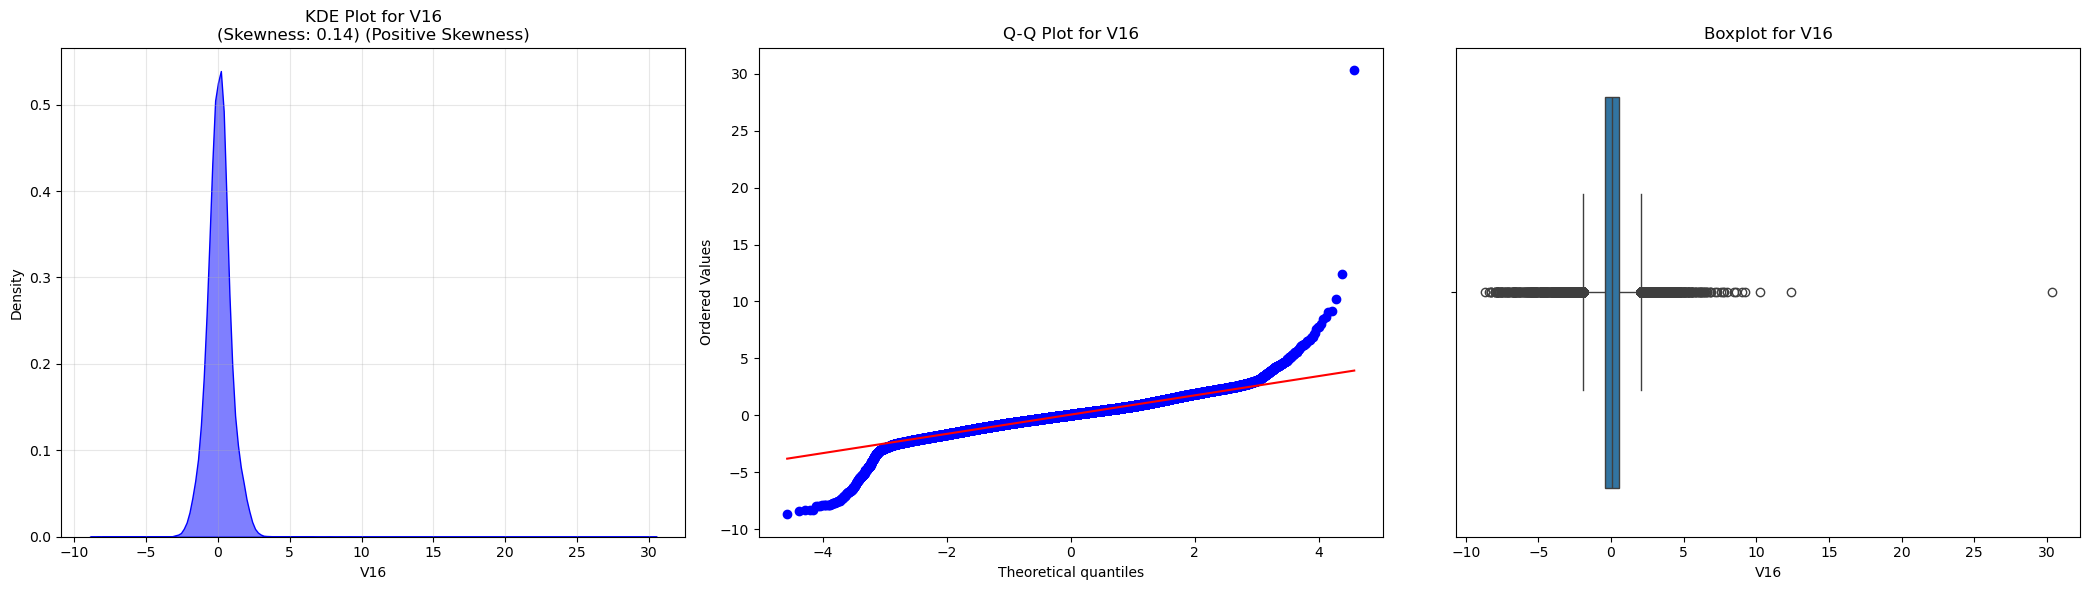

V17: Skewness = -0.79 (Negative Skewness)


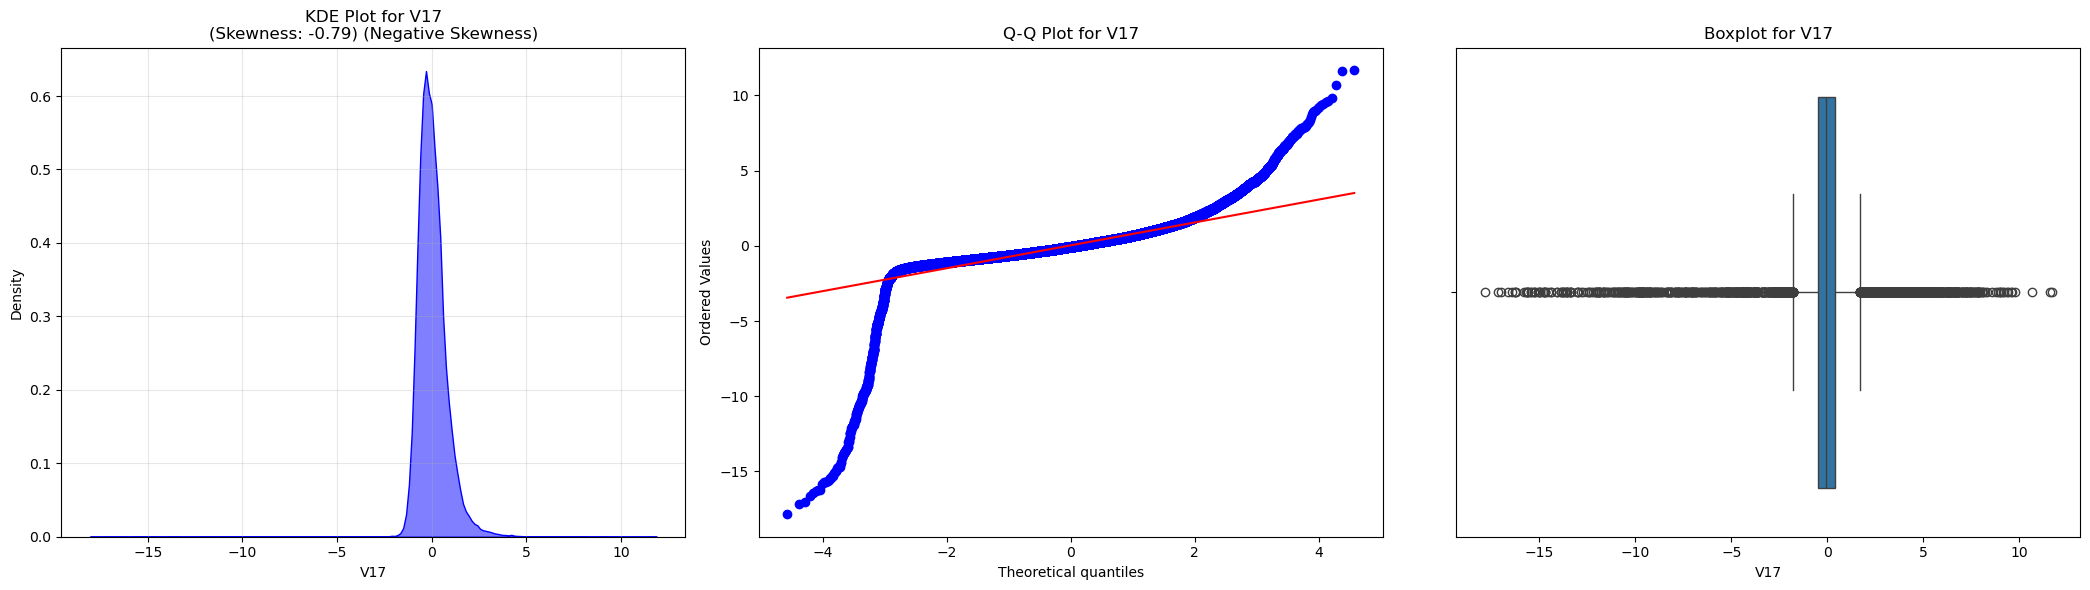

V18: Skewness = -0.06 (Negative Skewness)


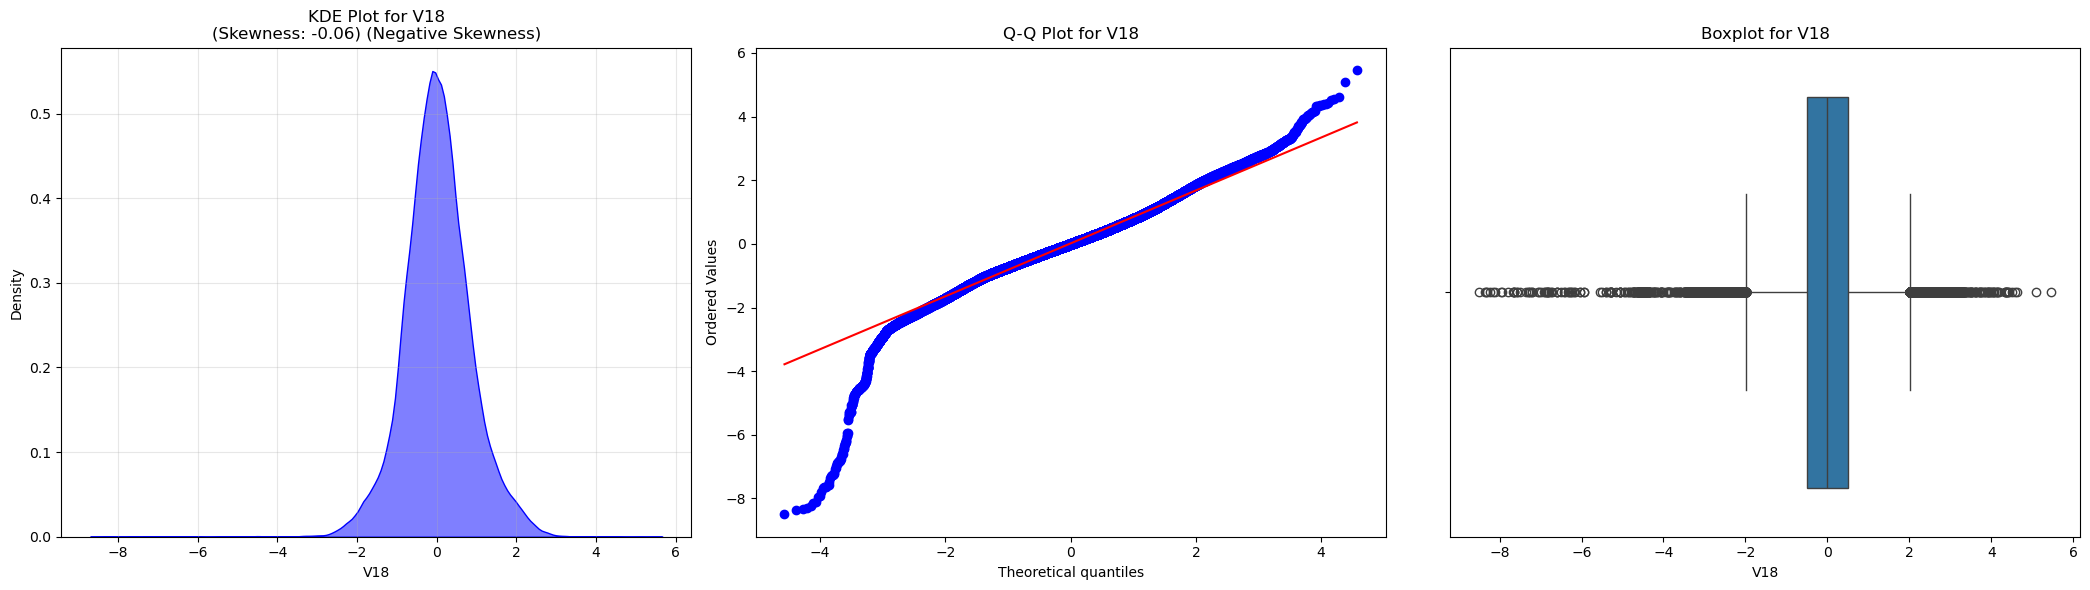

V19: Skewness = 0.02 (Positive Skewness)


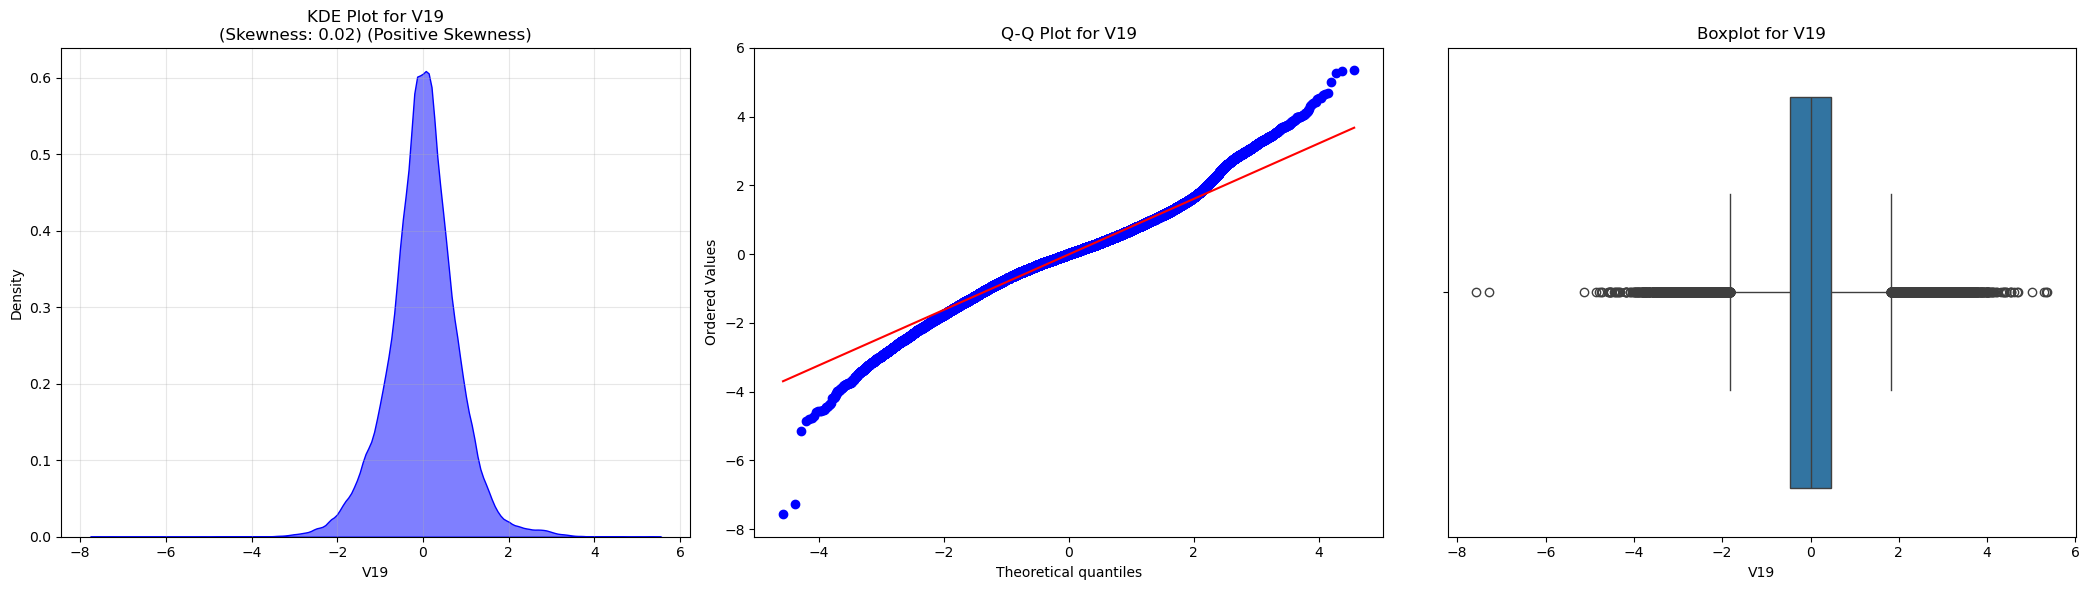

V20: Skewness = -0.92 (Negative Skewness)


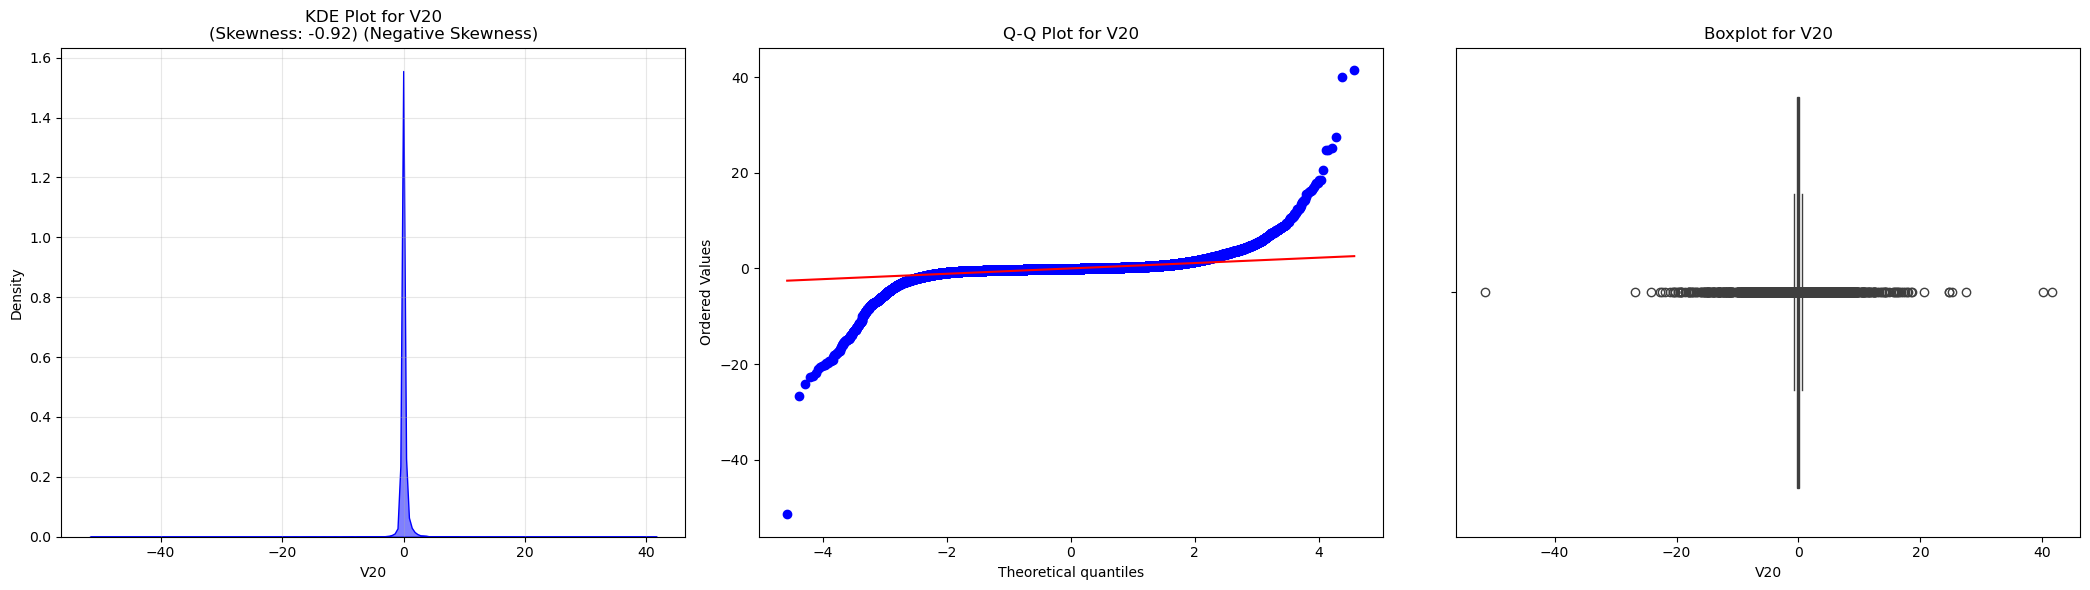

V21: Skewness = -1.97 (Negative Skewness)


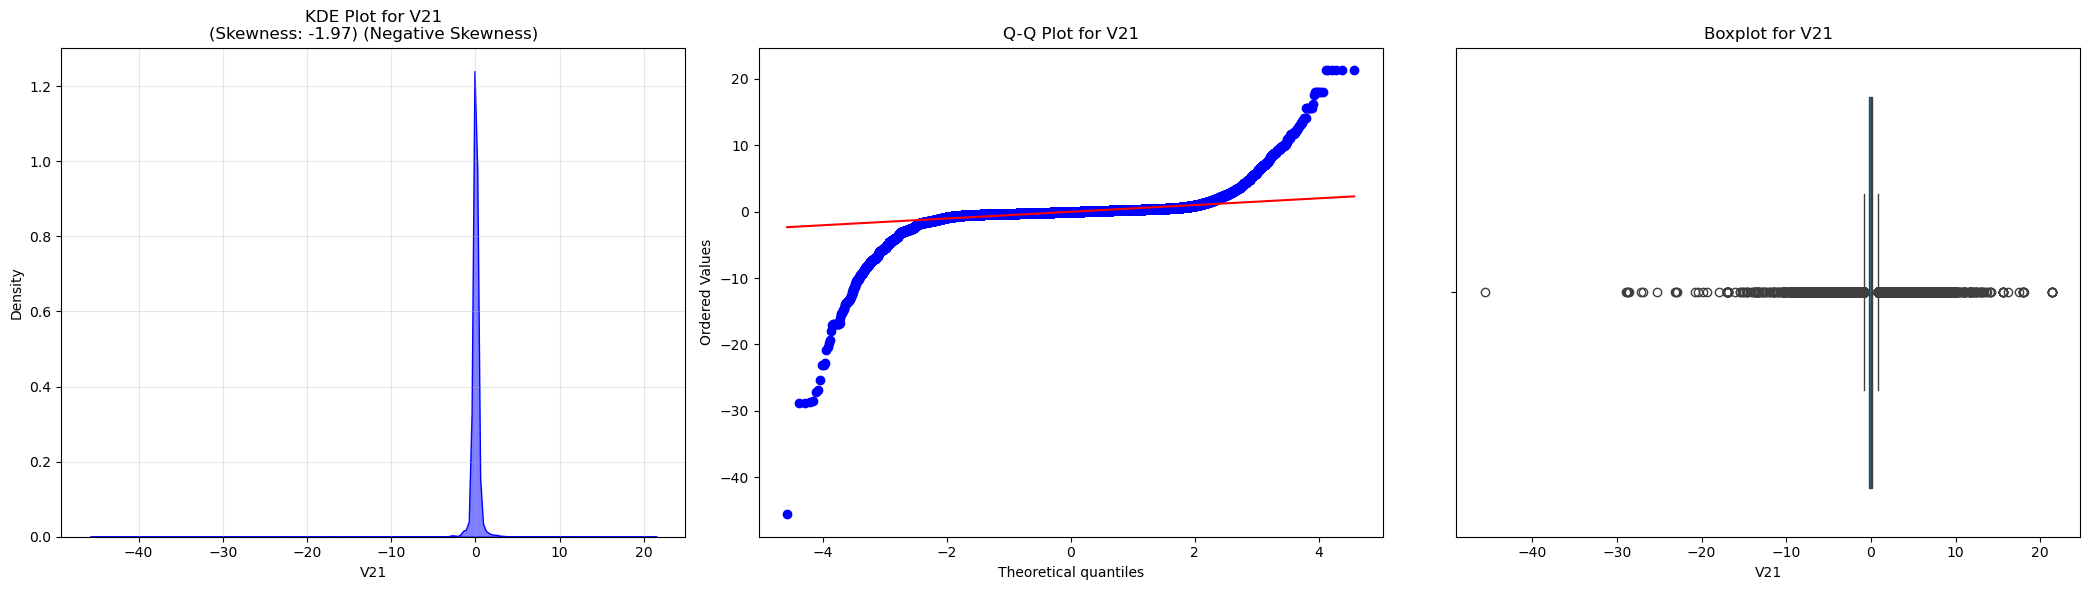

V22: Skewness = -0.03 (Negative Skewness)


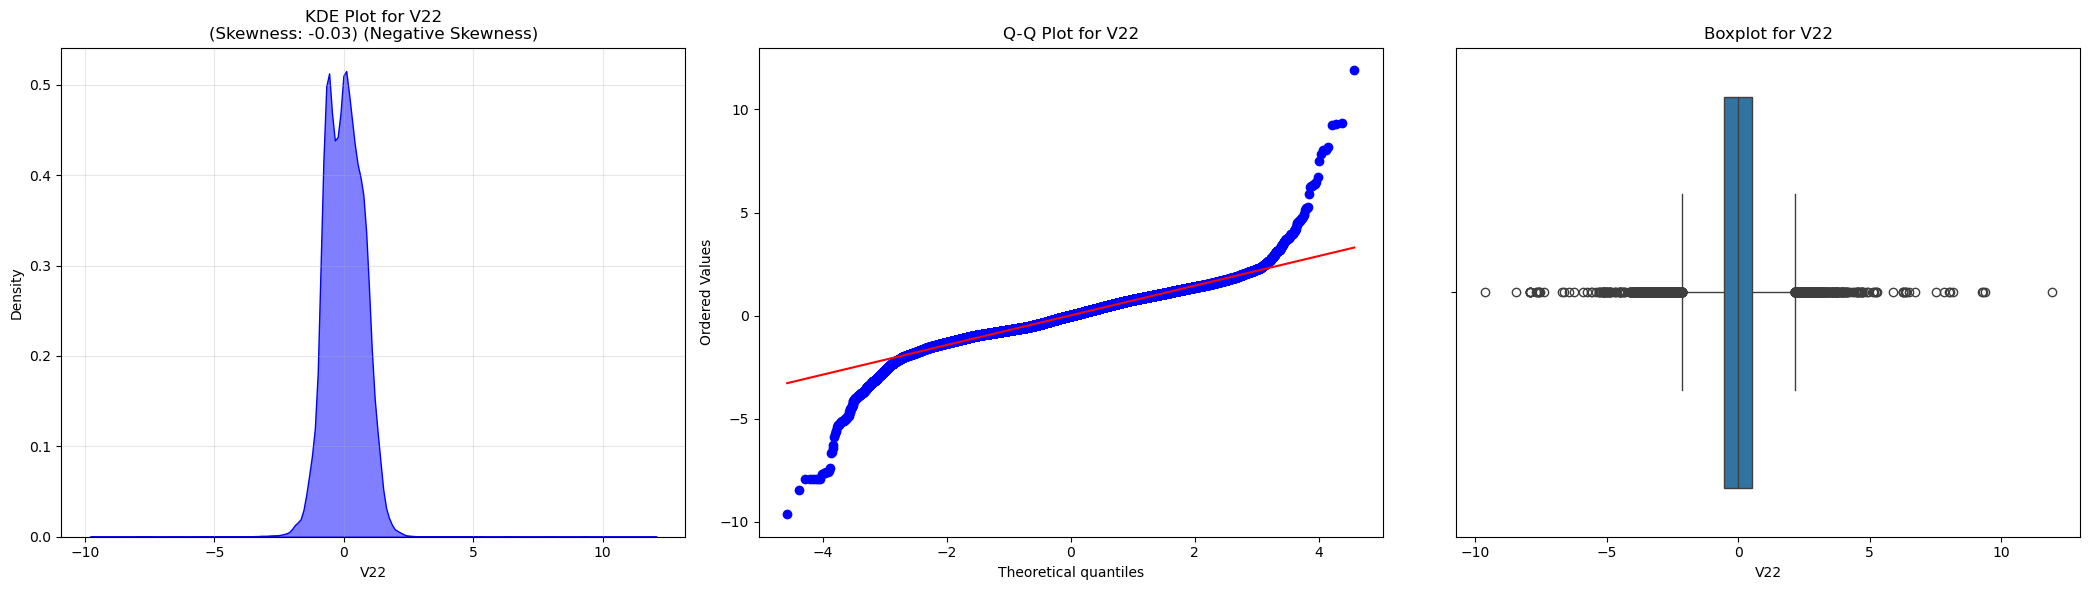

V23: Skewness = -0.25 (Negative Skewness)


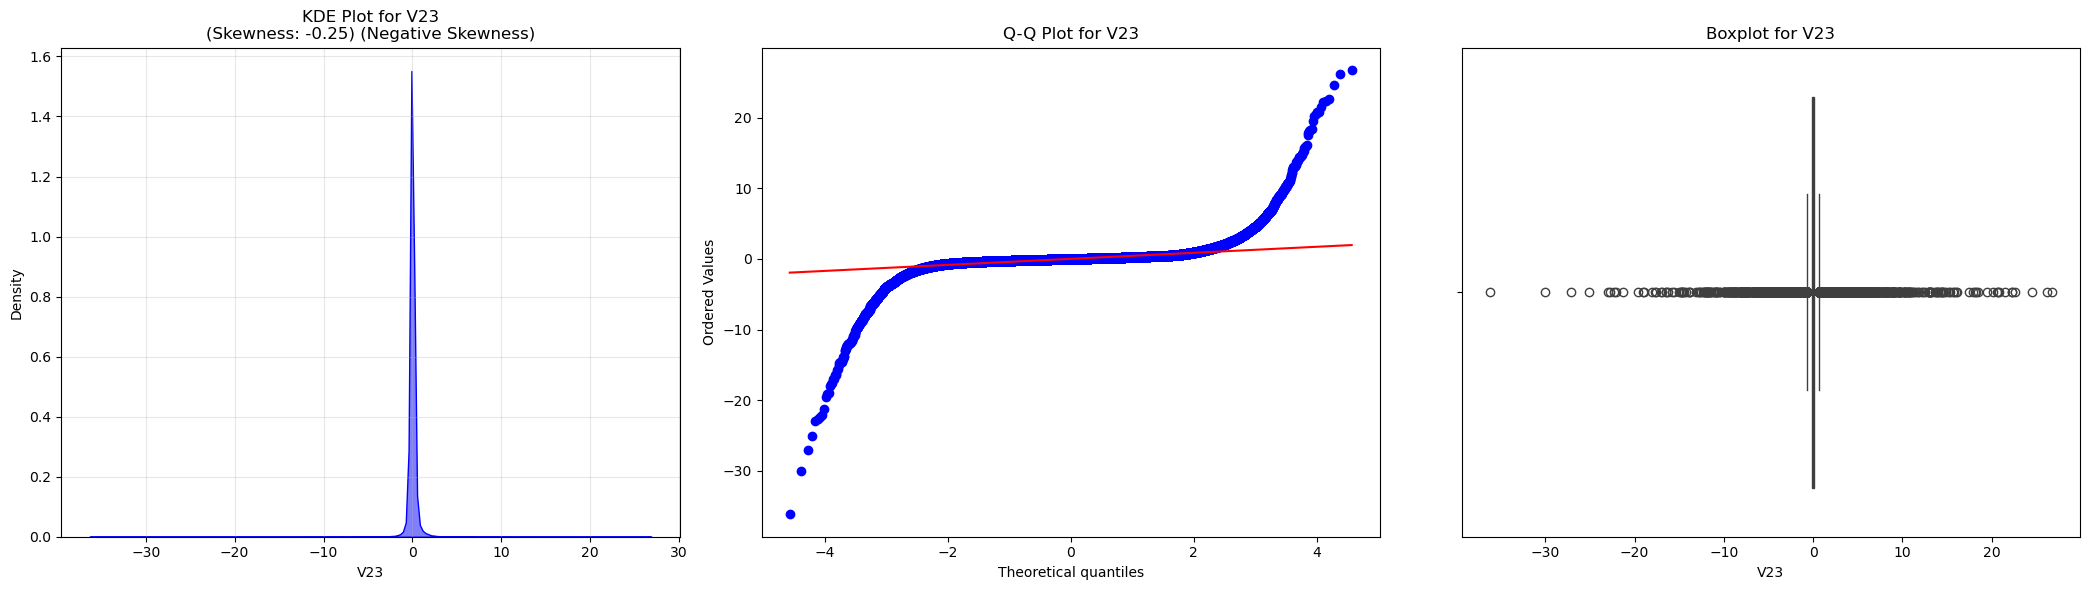

V24: Skewness = 0.11 (Positive Skewness)


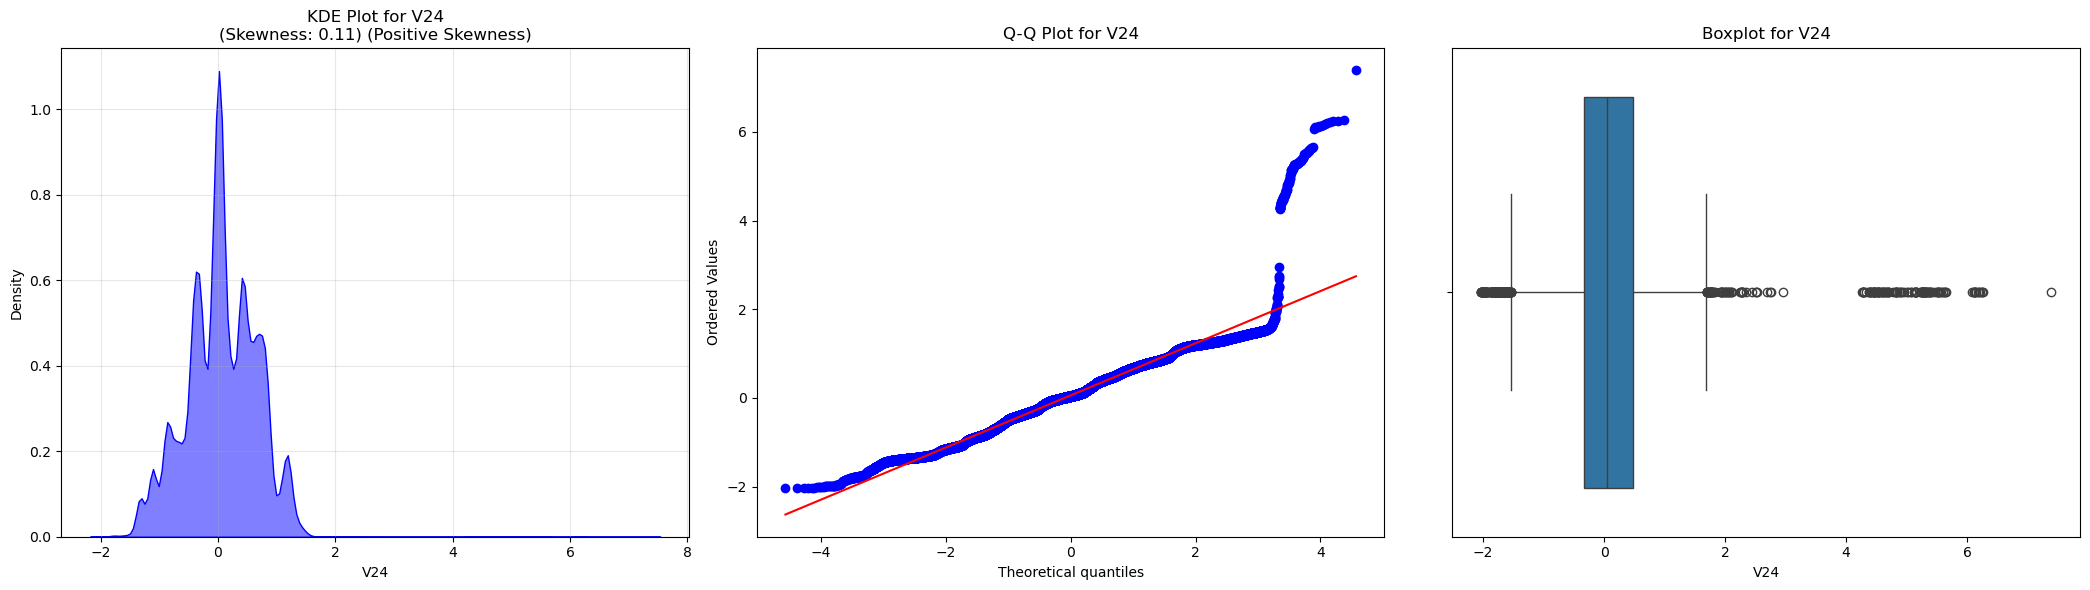

V25: Skewness = 0.08 (Positive Skewness)


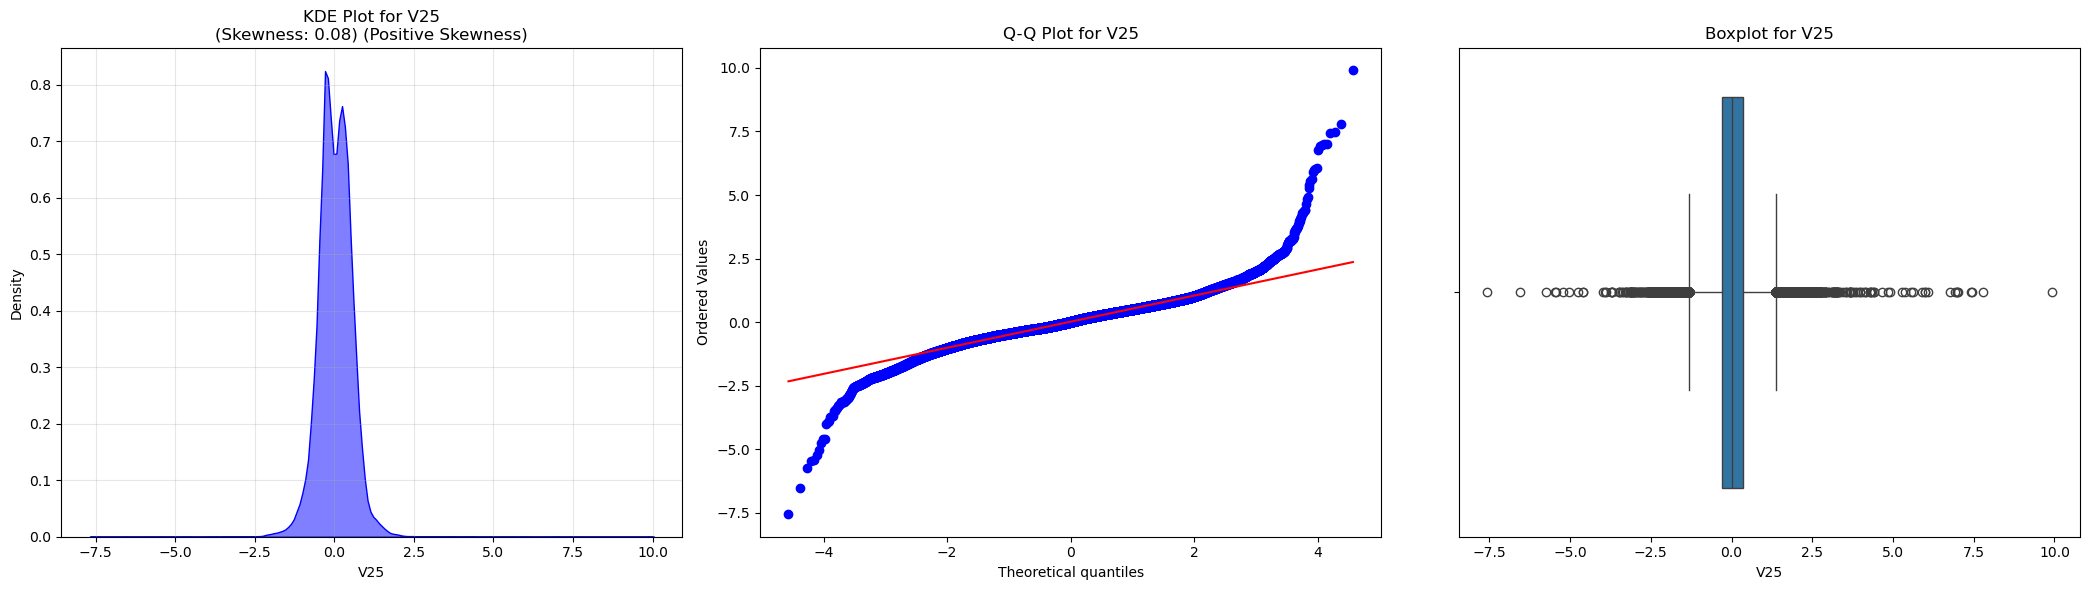

V26: Skewness = -0.02 (Negative Skewness)


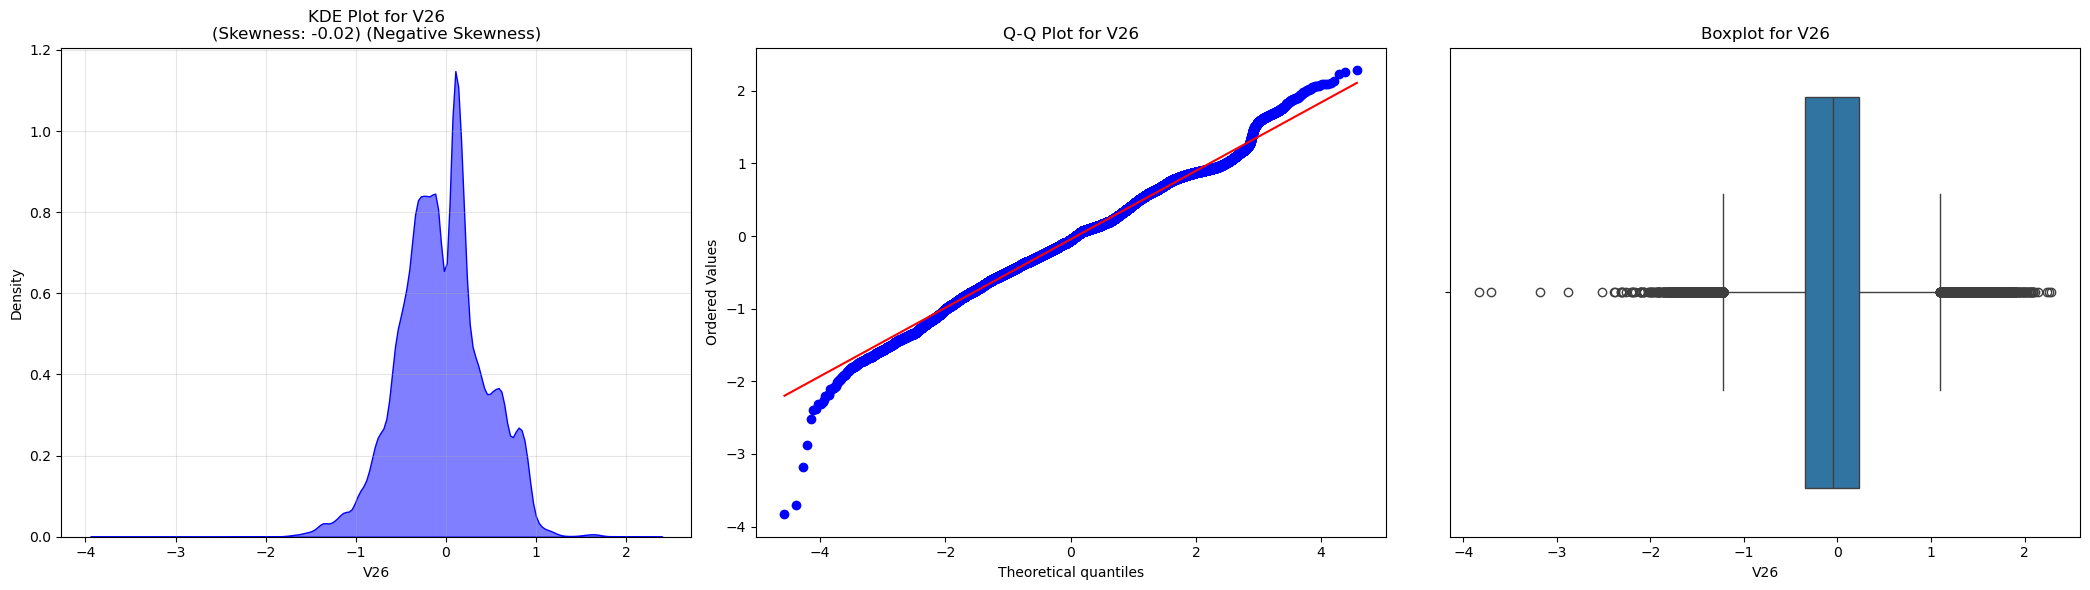

V27: Skewness = 3.47 (Positive Skewness)


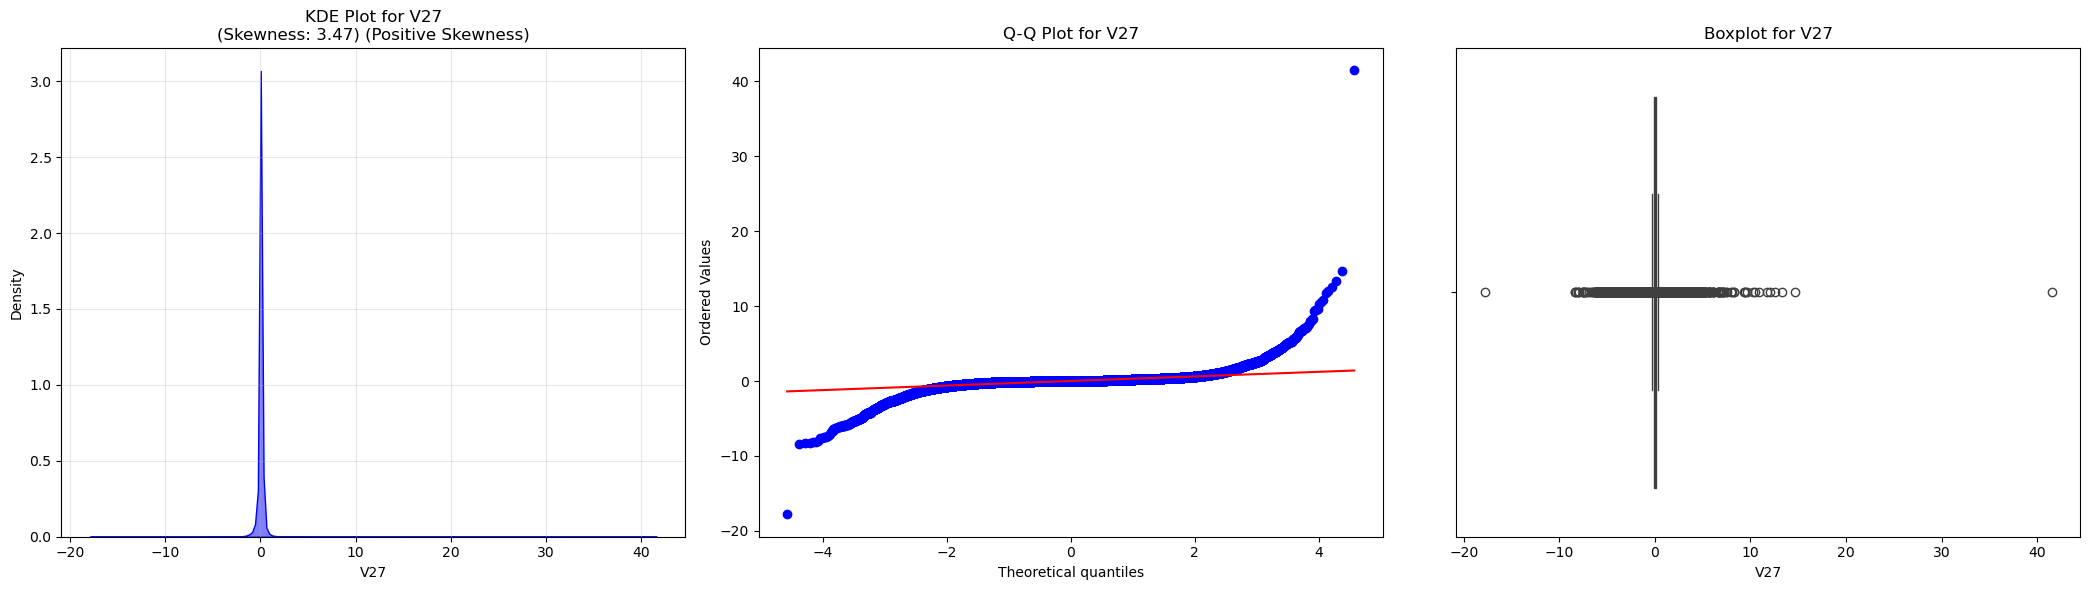

V28: Skewness = 1.07 (Positive Skewness)


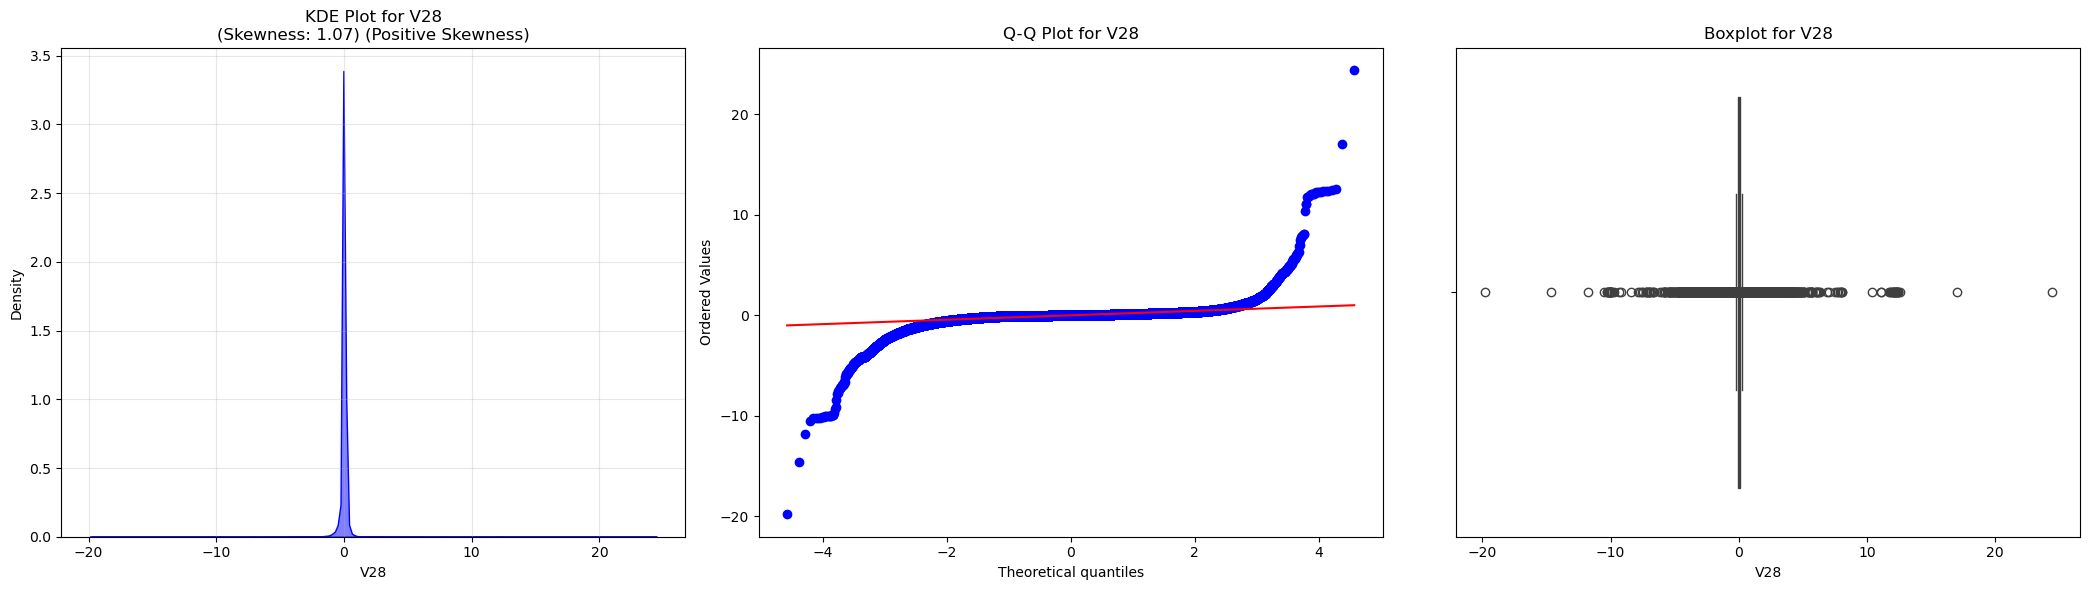

Amount: Skewness = 0.02 (Positive Skewness)


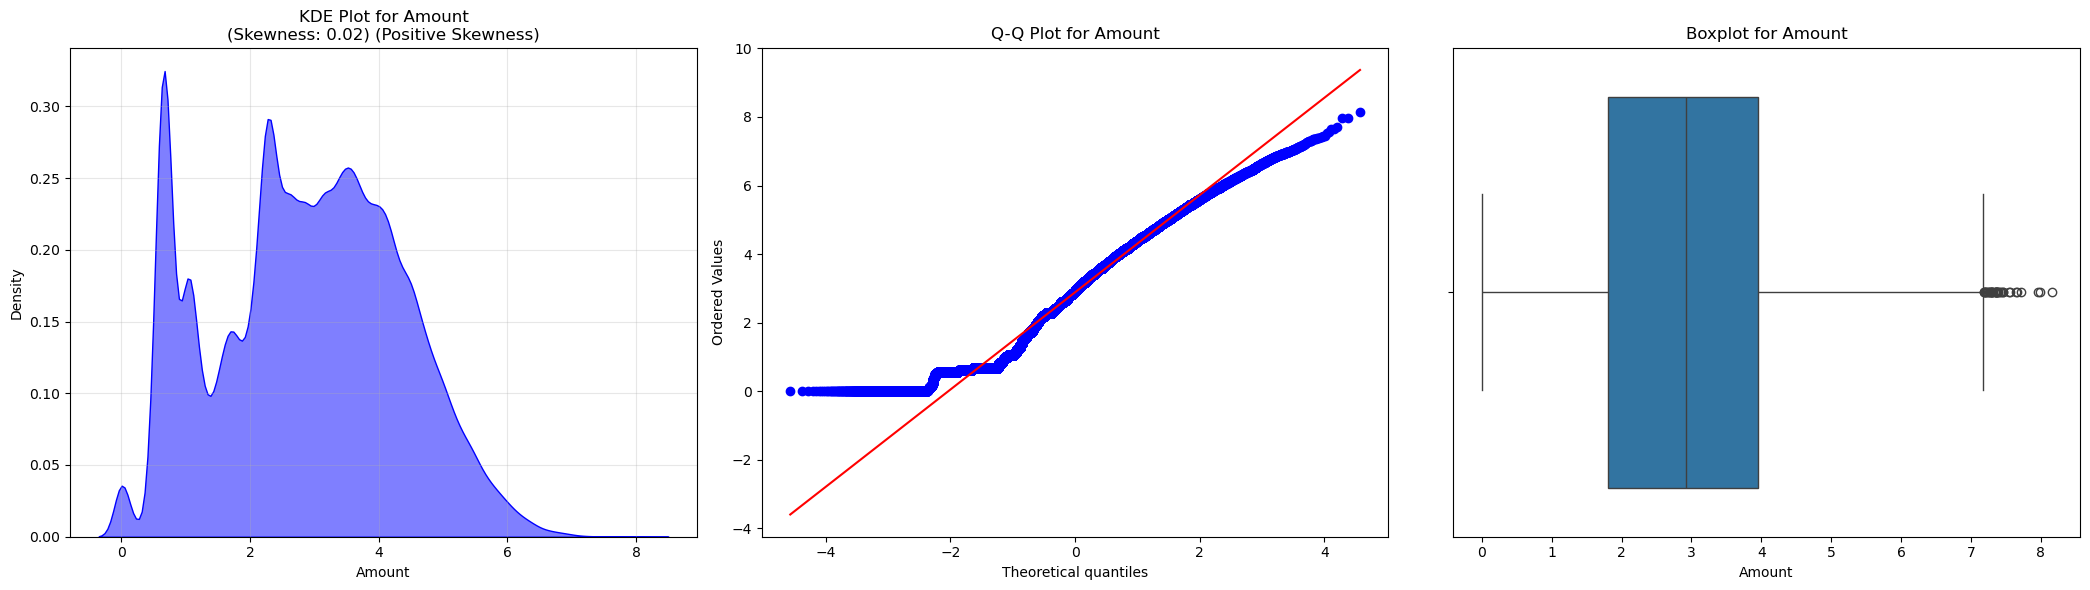

In [43]:
All_plot(X_trd)

In [49]:
# Function to cap outliers using IQR
def cap_outliers_iqr(df):
    df_capped = df.copy()  # Make a copy to avoid modifying the original DataFrame

    # Loop through numeric columns and cap outliers based on IQR
    for column in df_capped.select_dtypes(include=[np.number]).columns:
        Q1 = df_capped[column].quantile(0.25)
        Q3 = df_capped[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the bounds to the lower or upper bound
        df_capped[column] = np.clip(df_capped[column], lower_bound, upper_bound)

    return df_capped

In [51]:
X_new = cap_outliers_iqr(X_trd)

Time: Skewness = -0.23 (Negative Skewness)


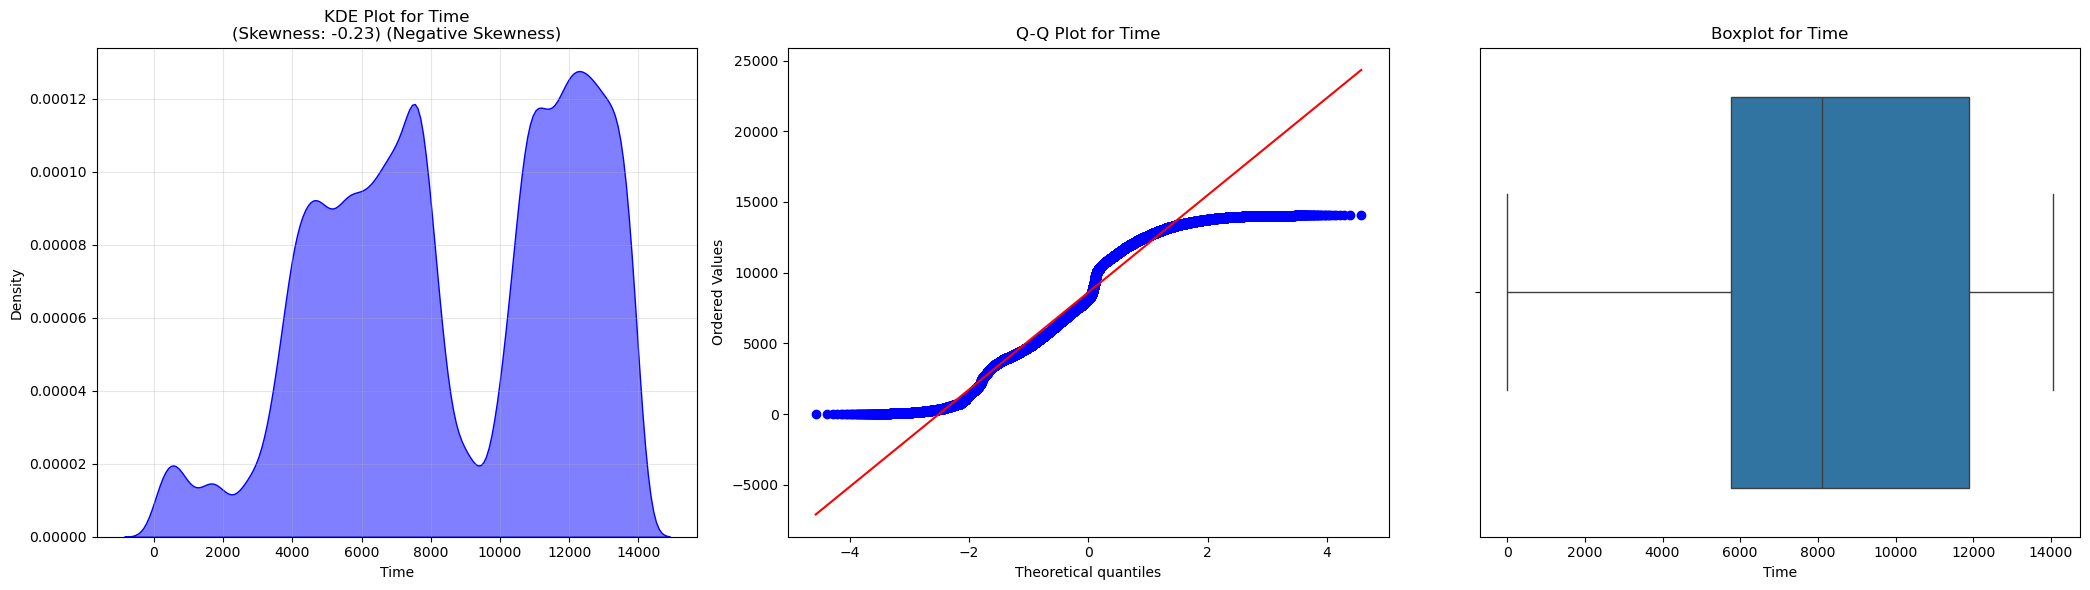

V1: Skewness = -0.08 (Negative Skewness)


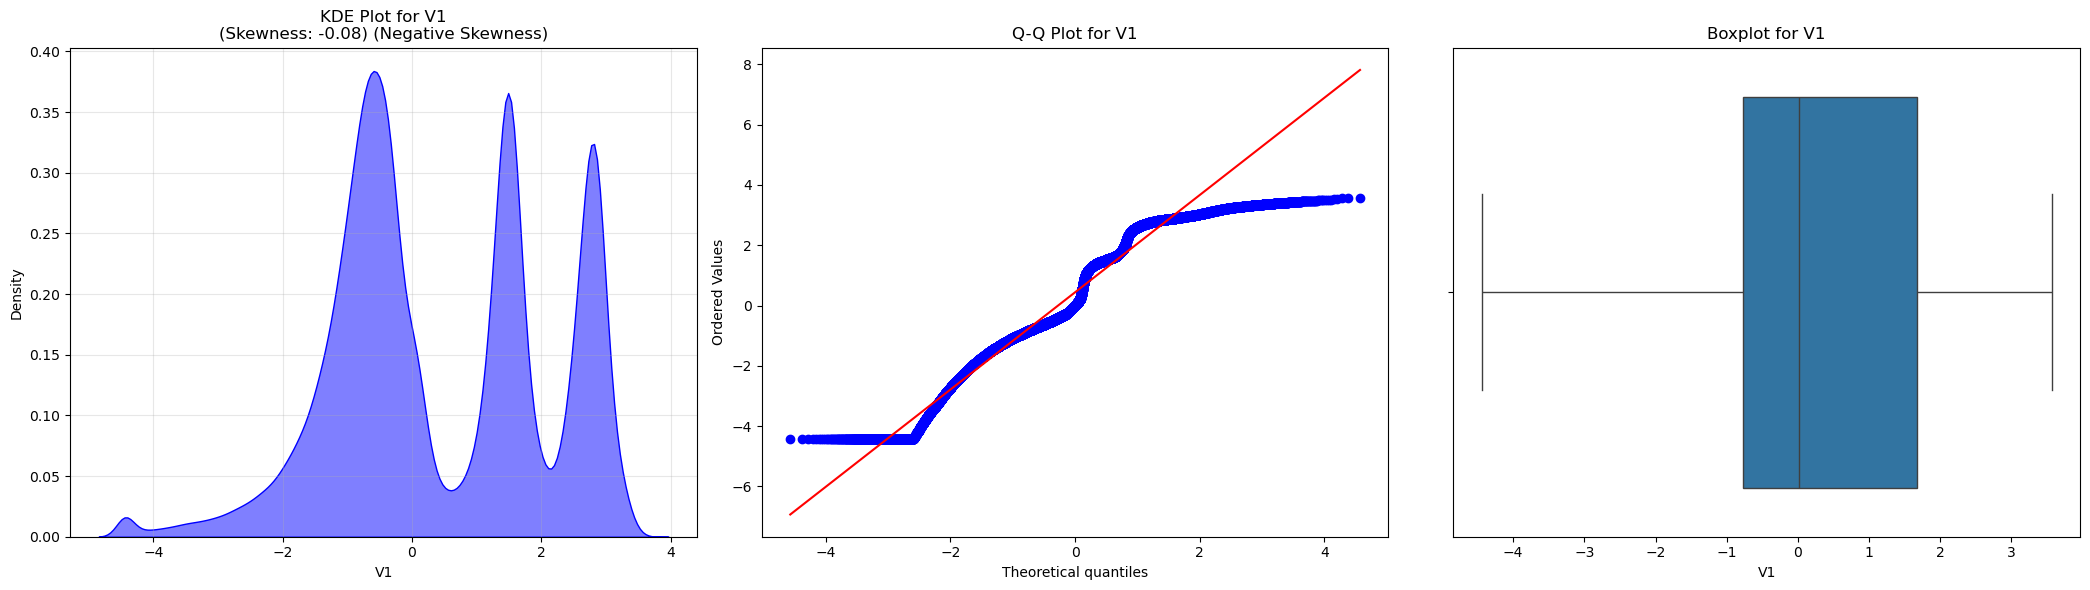

V2: Skewness = 0.08 (Positive Skewness)


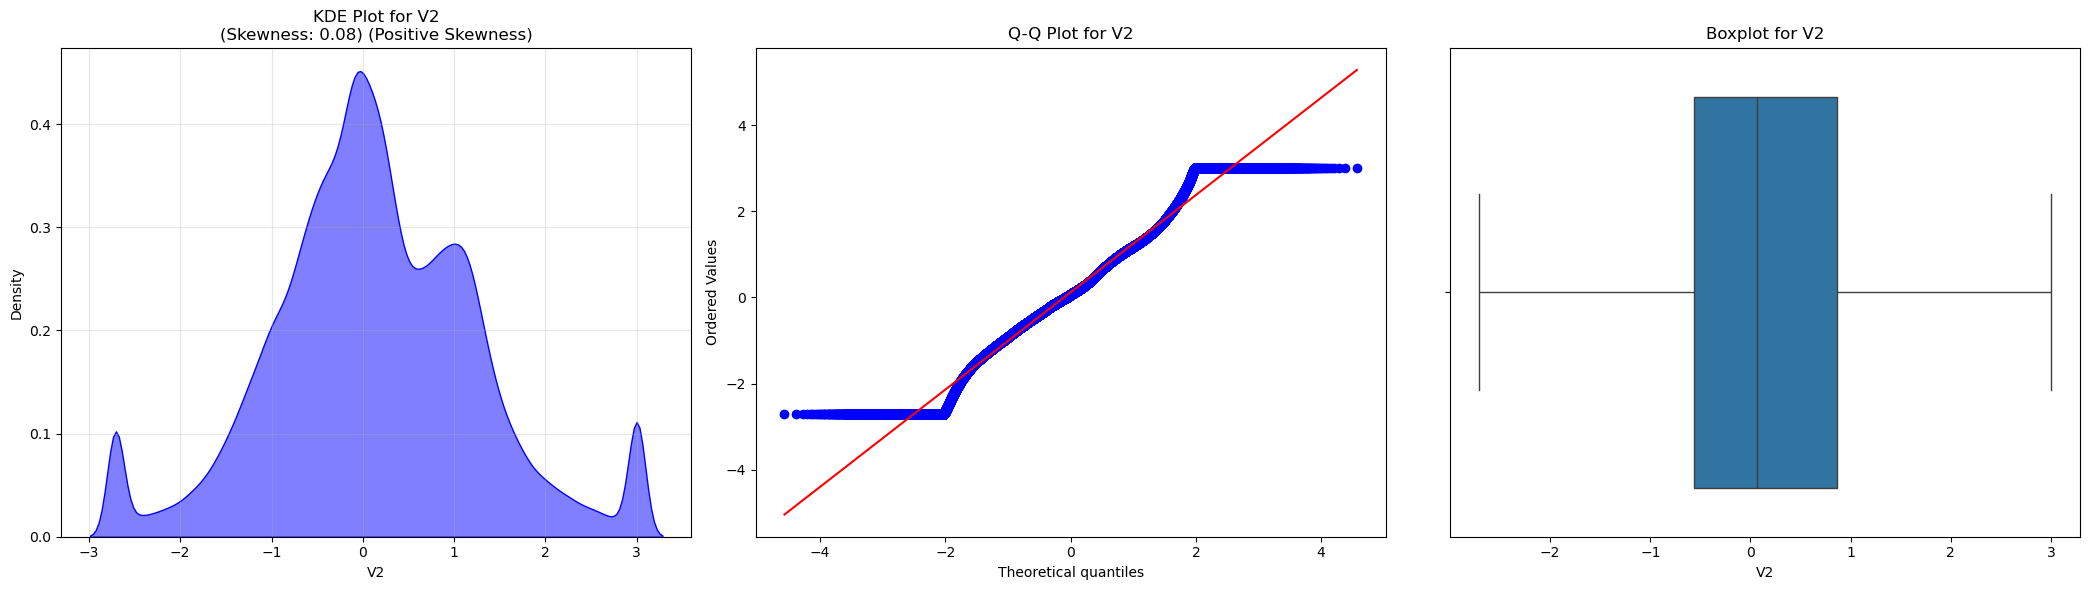

V3: Skewness = 0.15 (Positive Skewness)


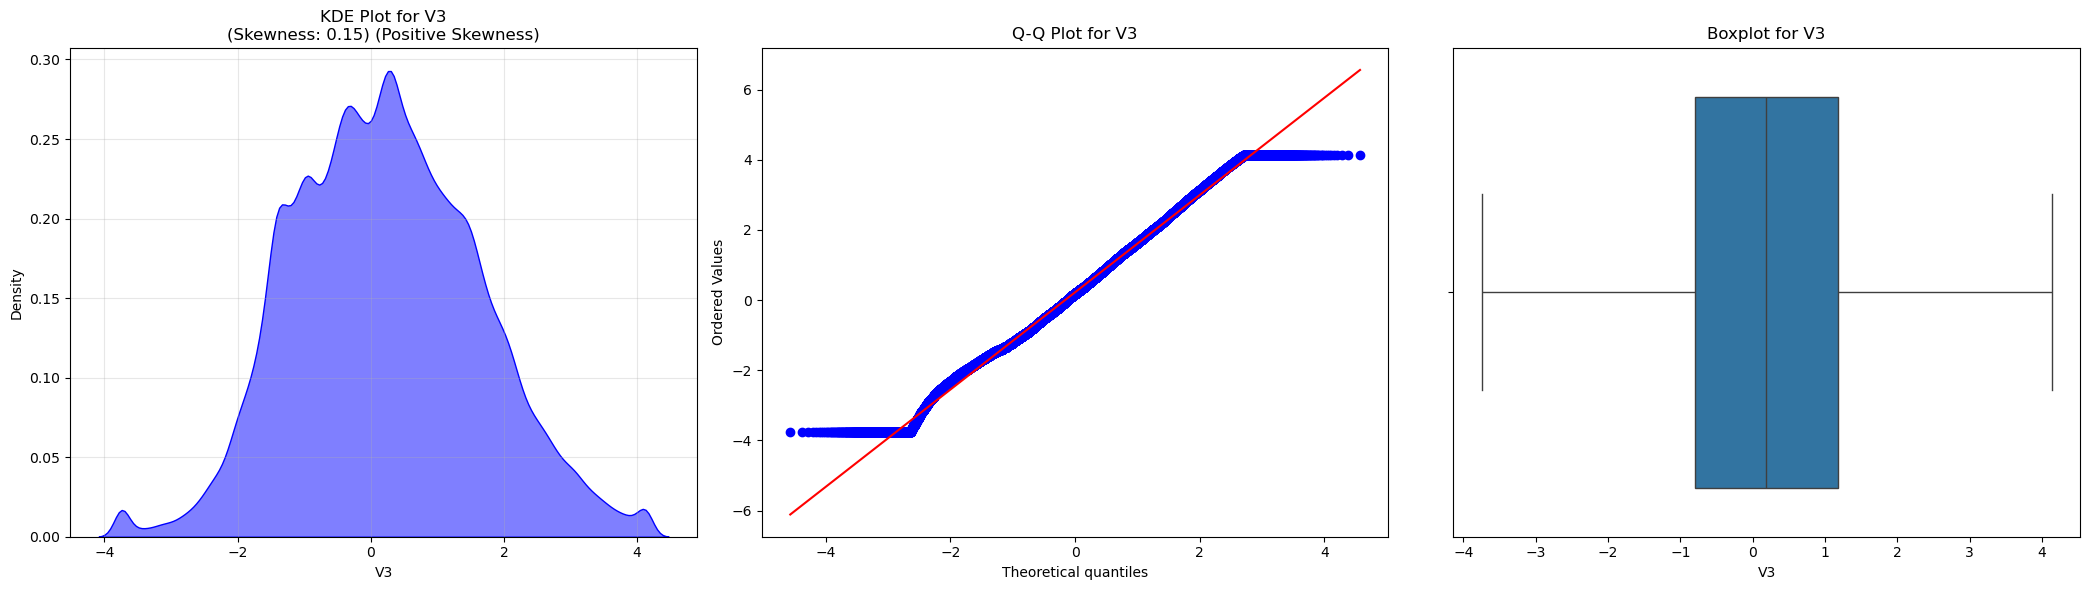

V4: Skewness = -0.05 (Negative Skewness)


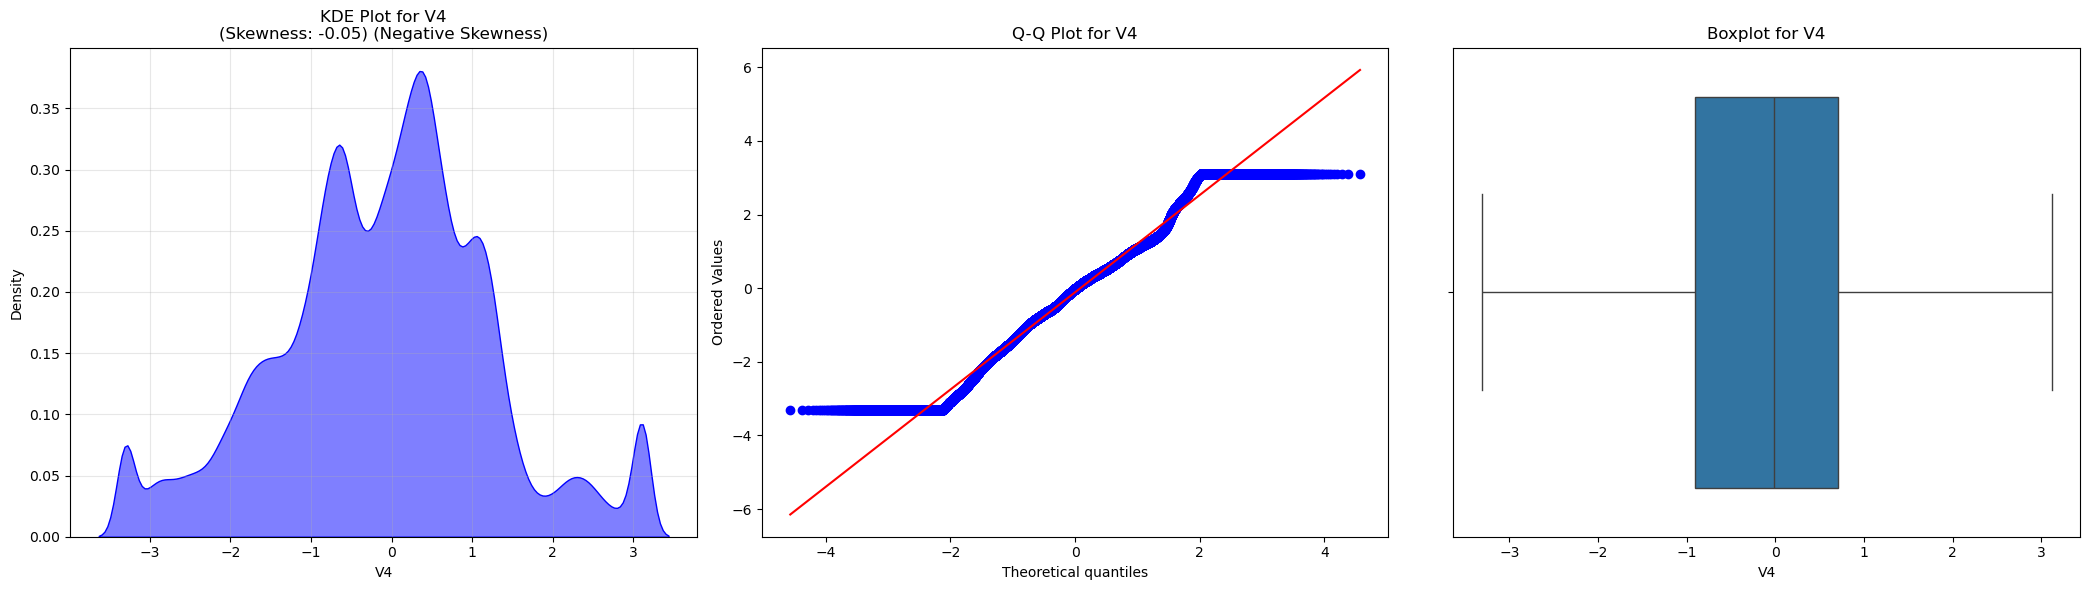

V5: Skewness = 0.26 (Positive Skewness)


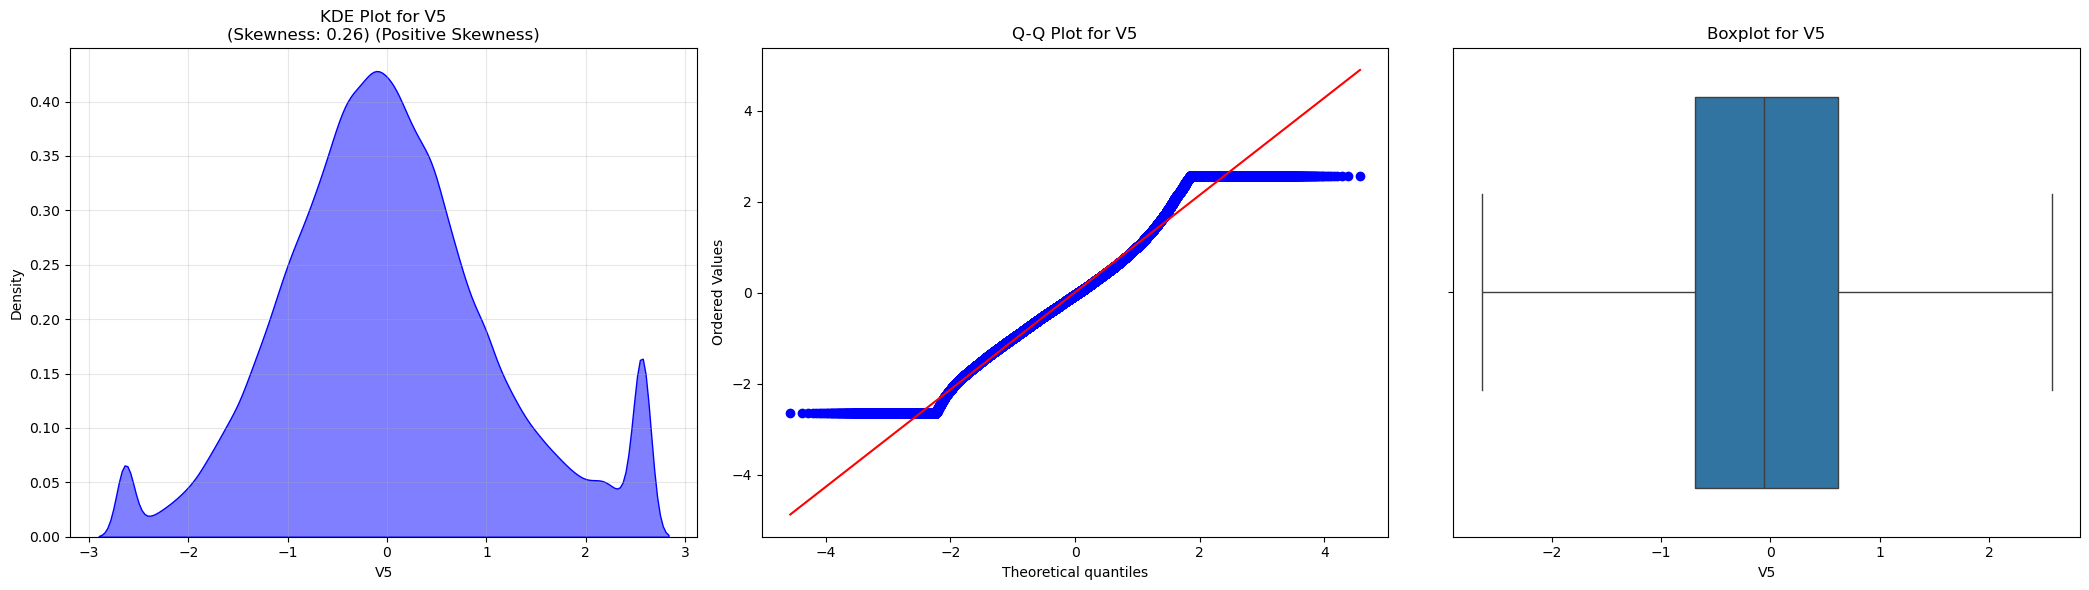

V6: Skewness = 0.50 (Positive Skewness)


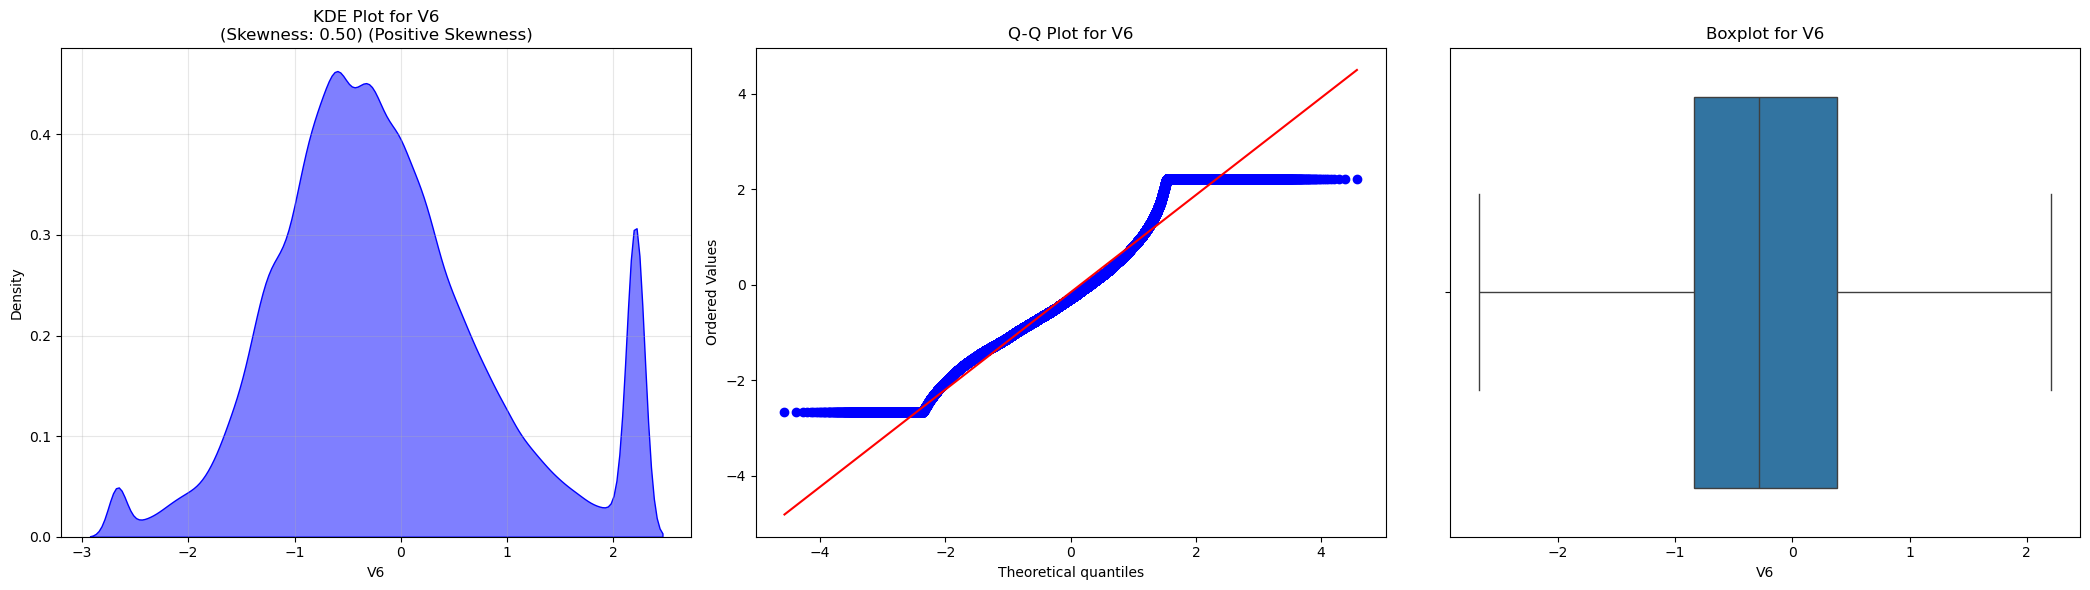

V7: Skewness = -0.06 (Negative Skewness)


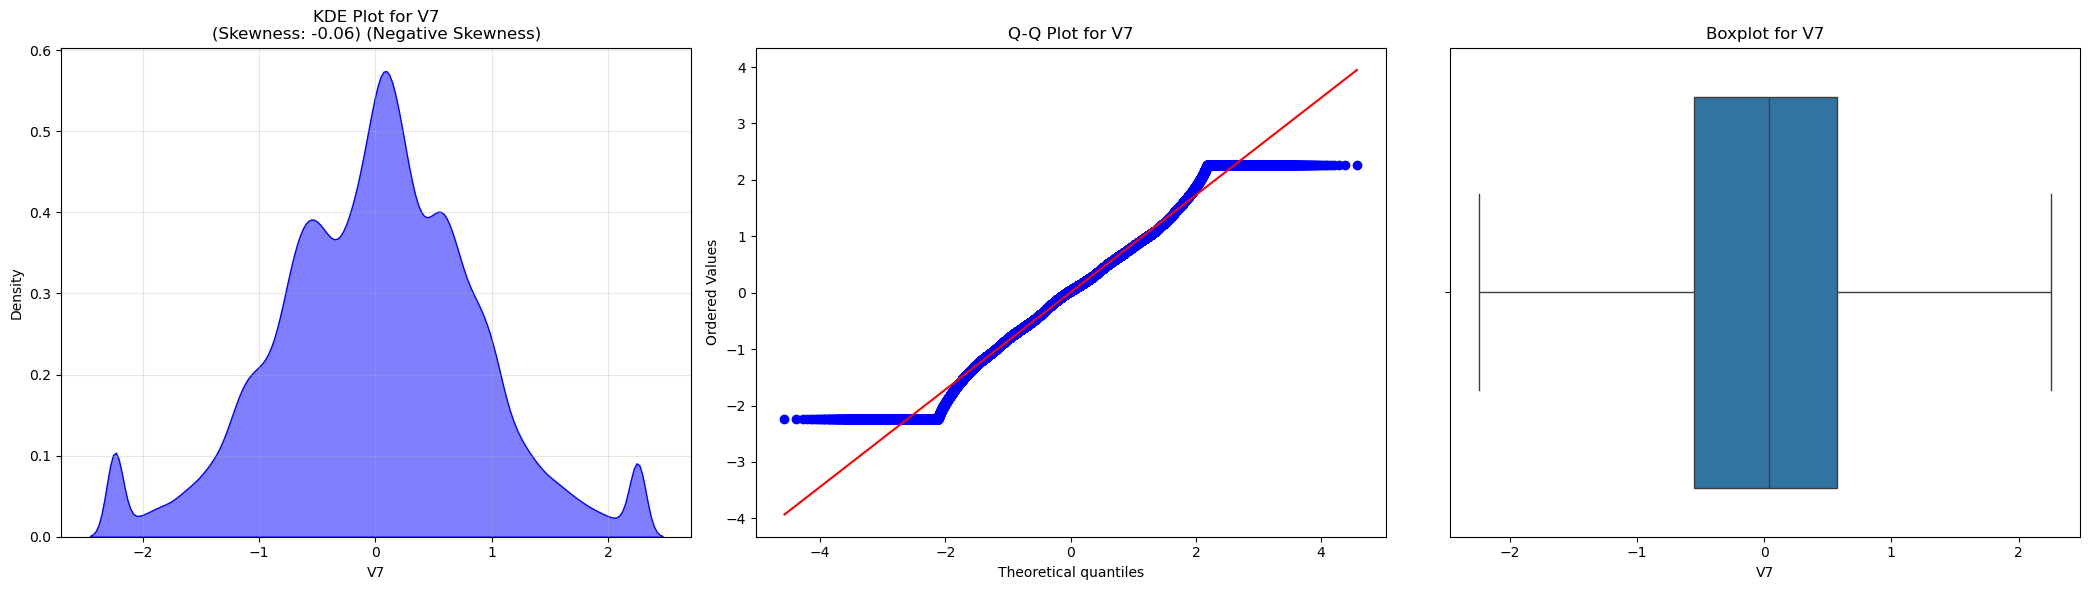

V8: Skewness = 0.26 (Positive Skewness)


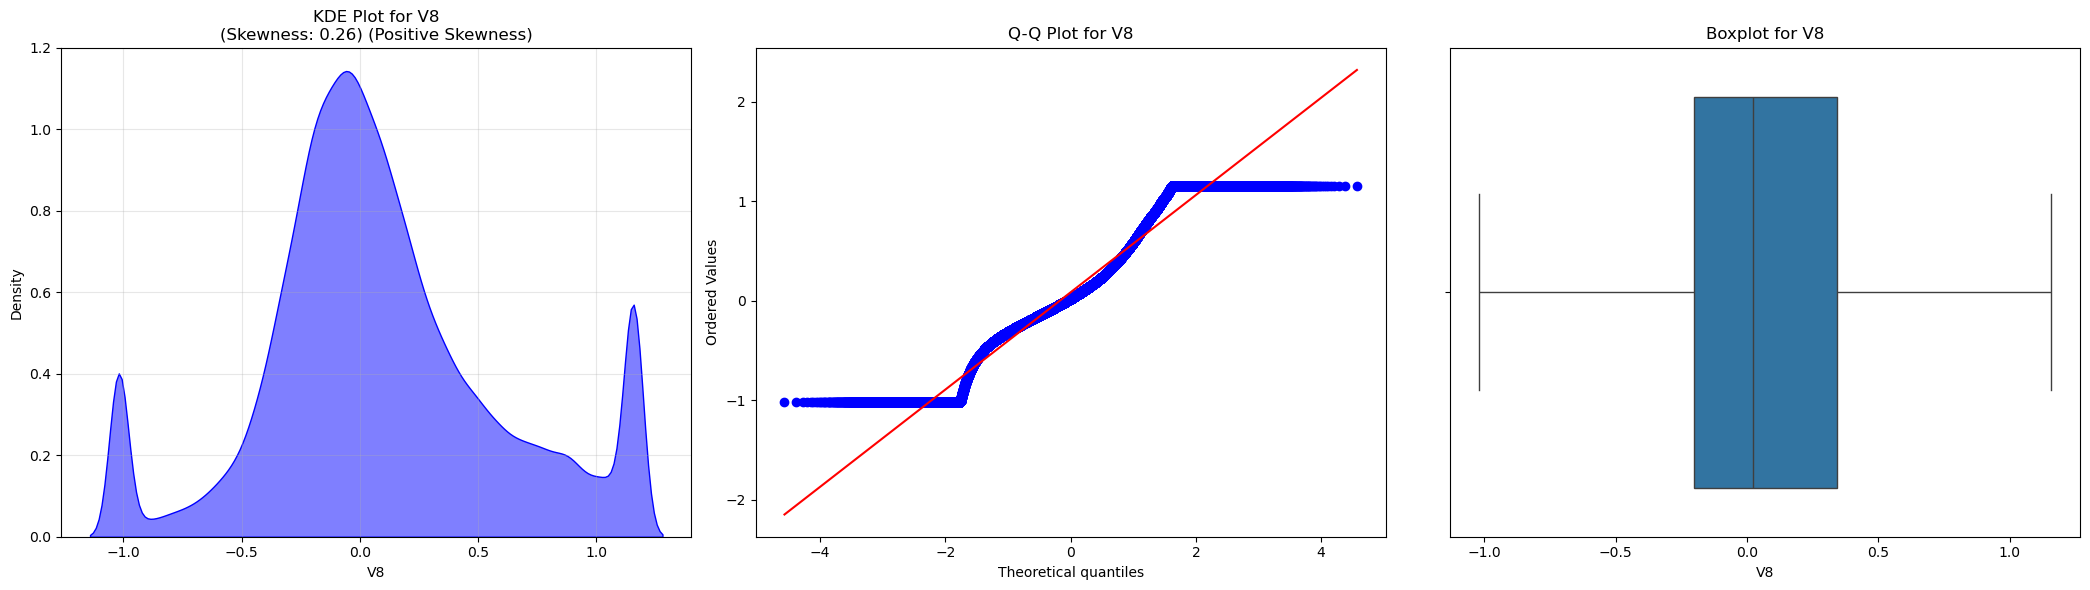

V9: Skewness = -0.09 (Negative Skewness)


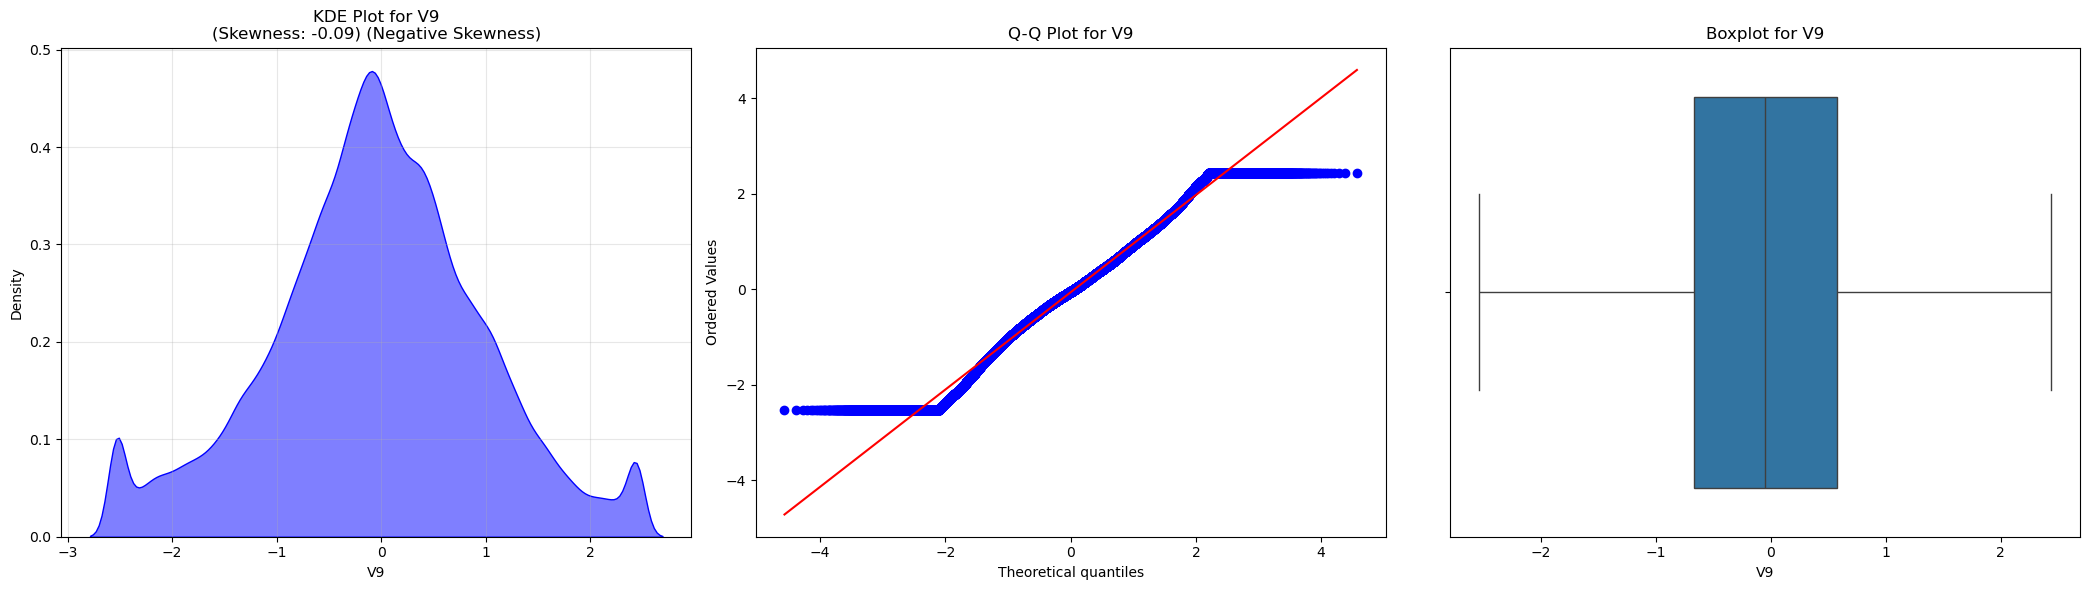

V10: Skewness = 0.11 (Positive Skewness)


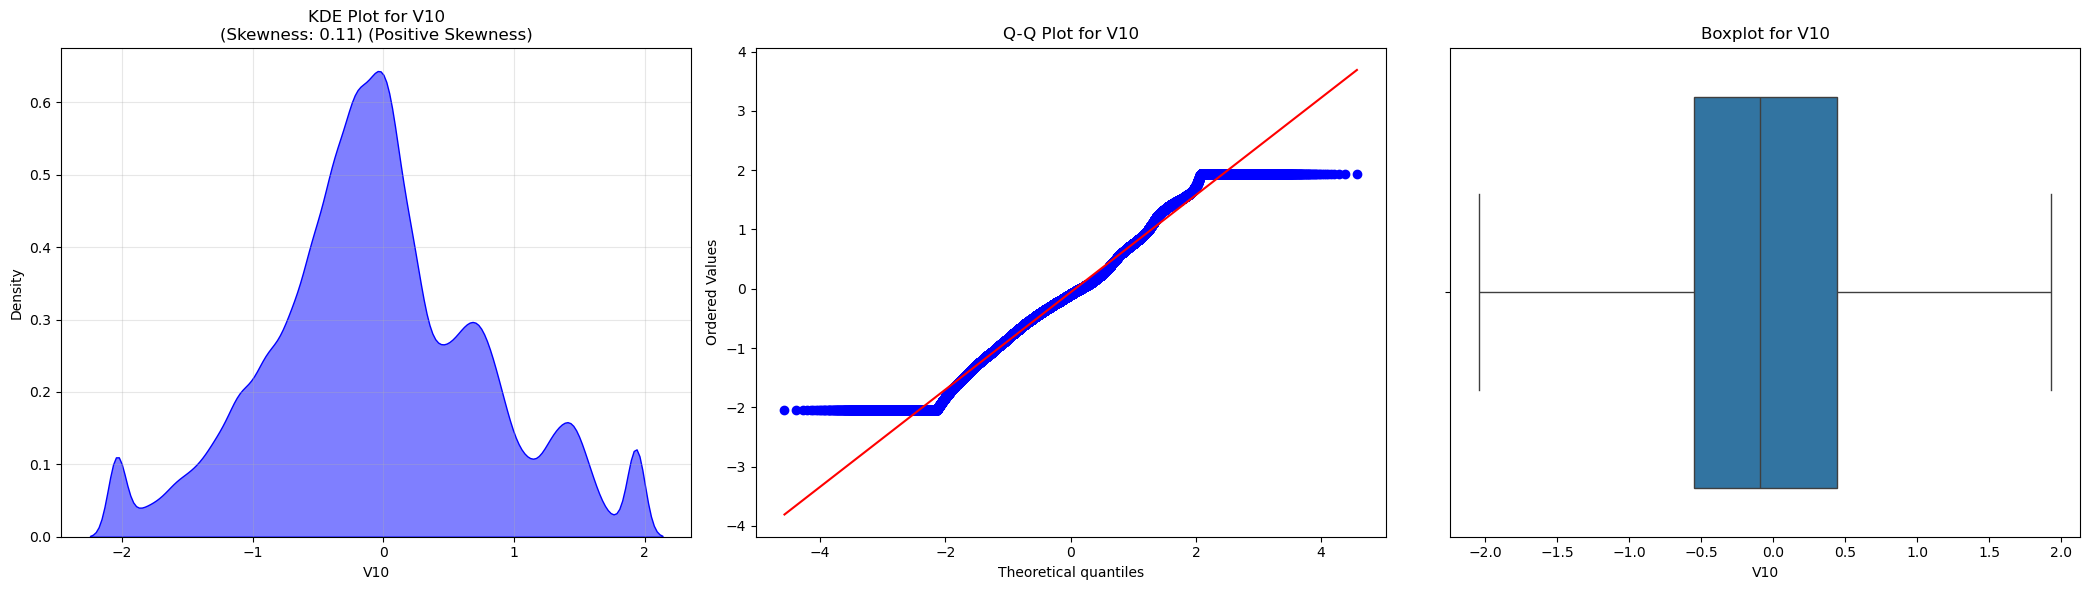

V11: Skewness = -0.07 (Negative Skewness)


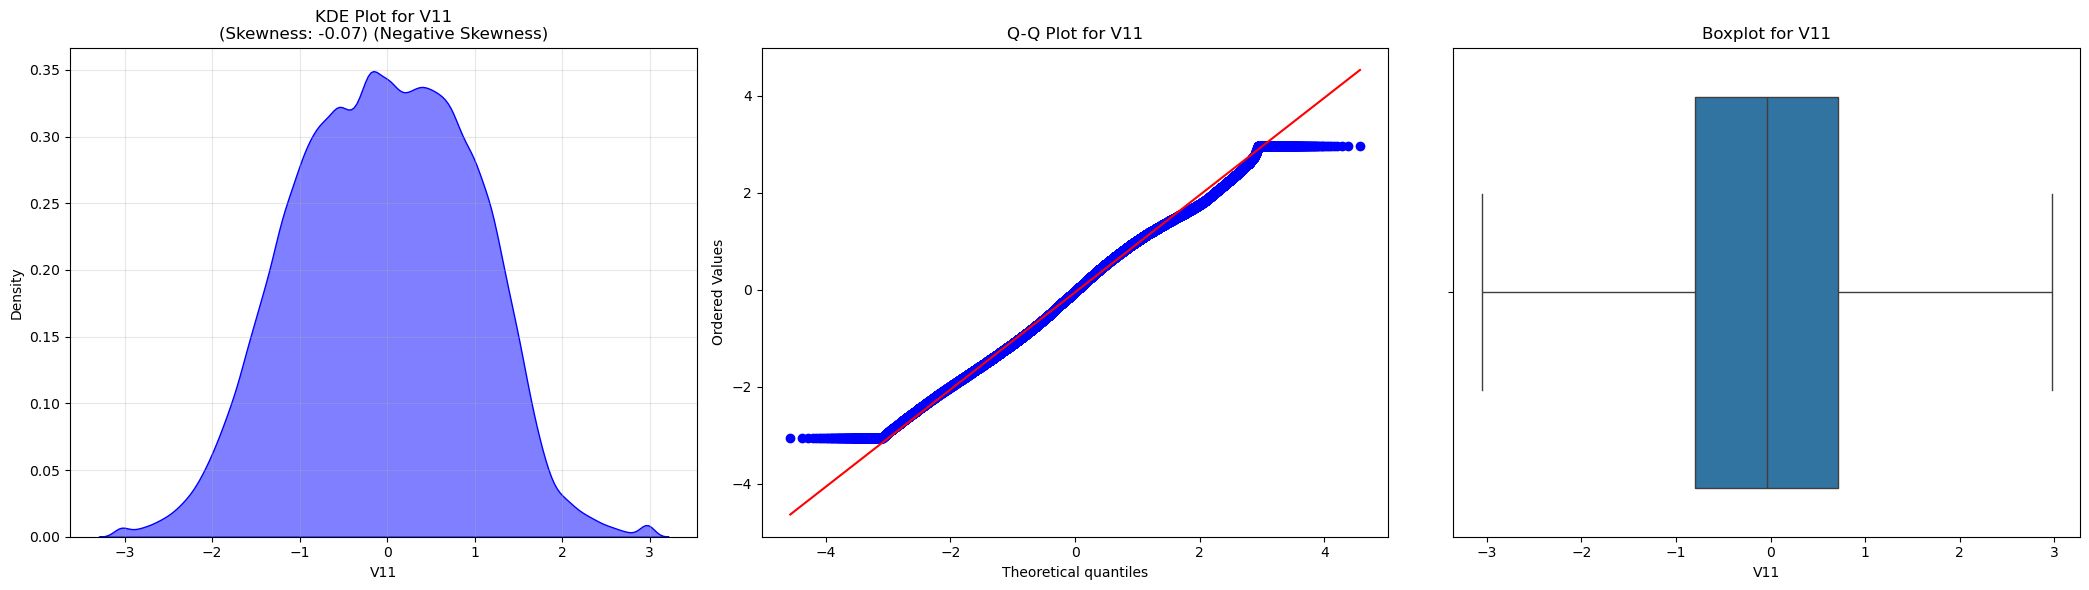

V12: Skewness = -0.04 (Negative Skewness)


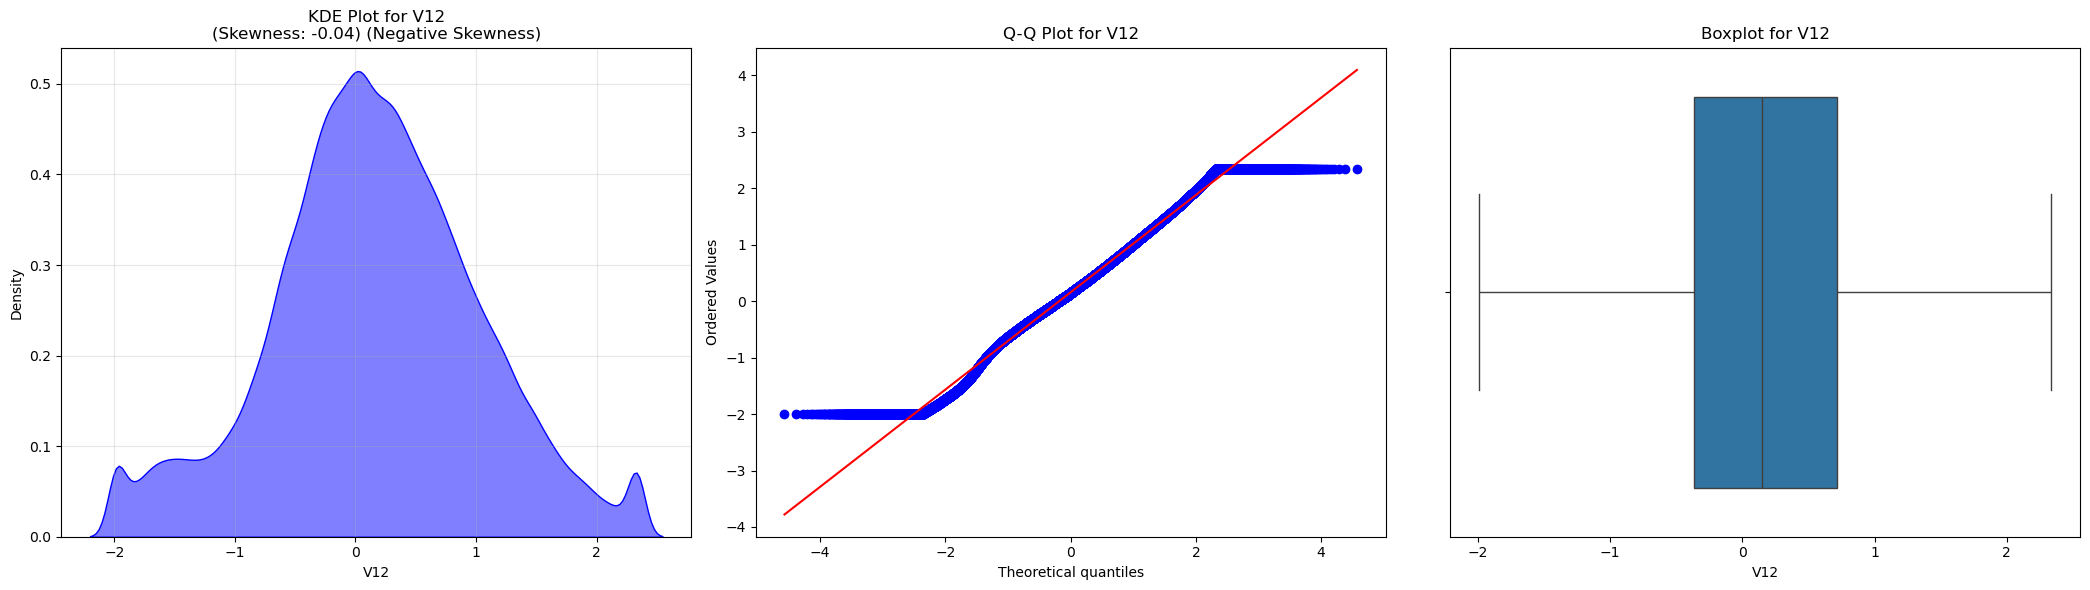

V13: Skewness = -0.00 (Negative Skewness)


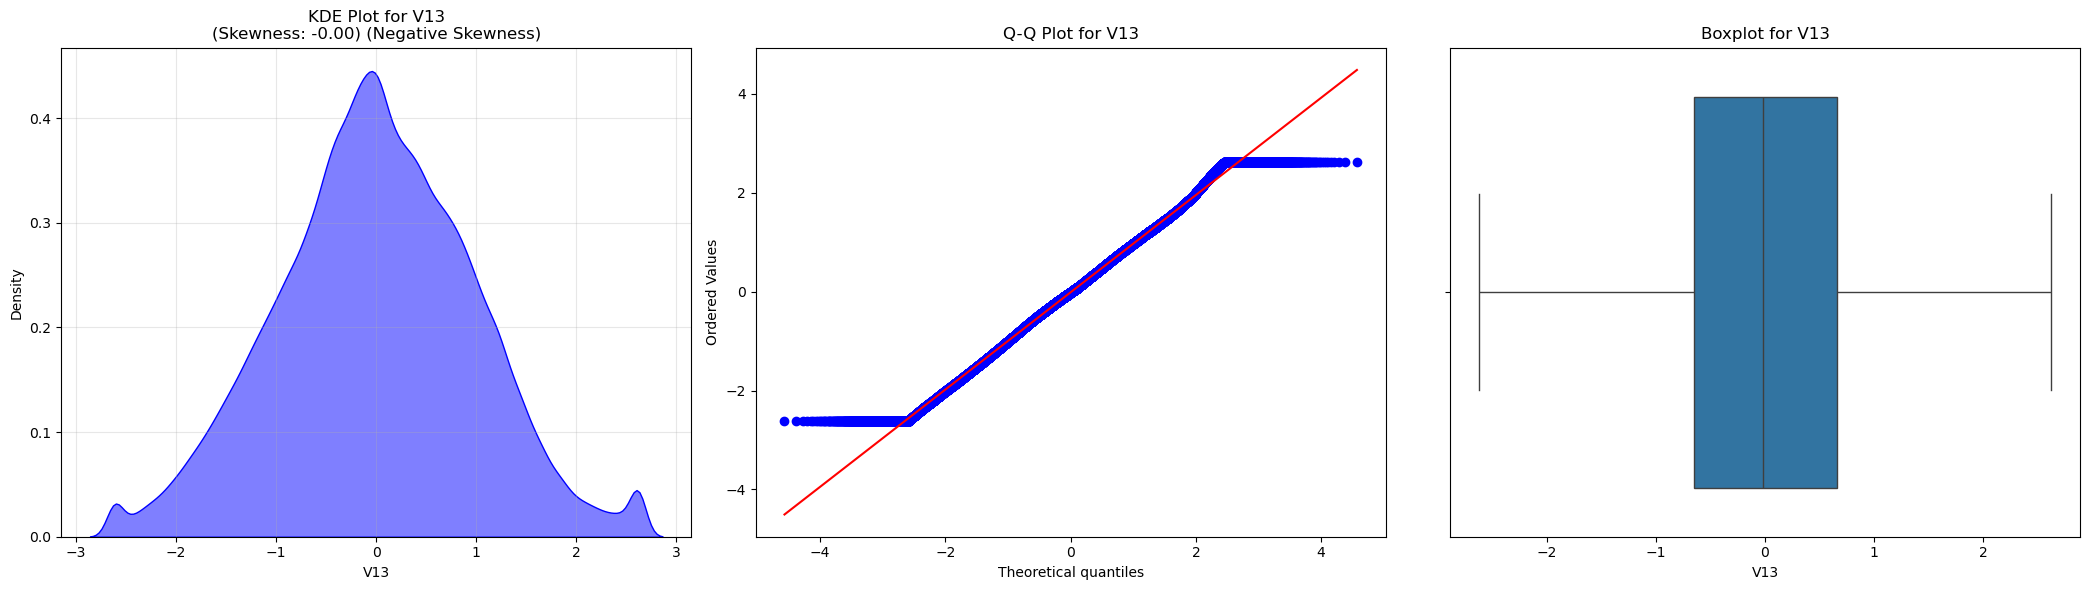

V14: Skewness = 0.11 (Positive Skewness)


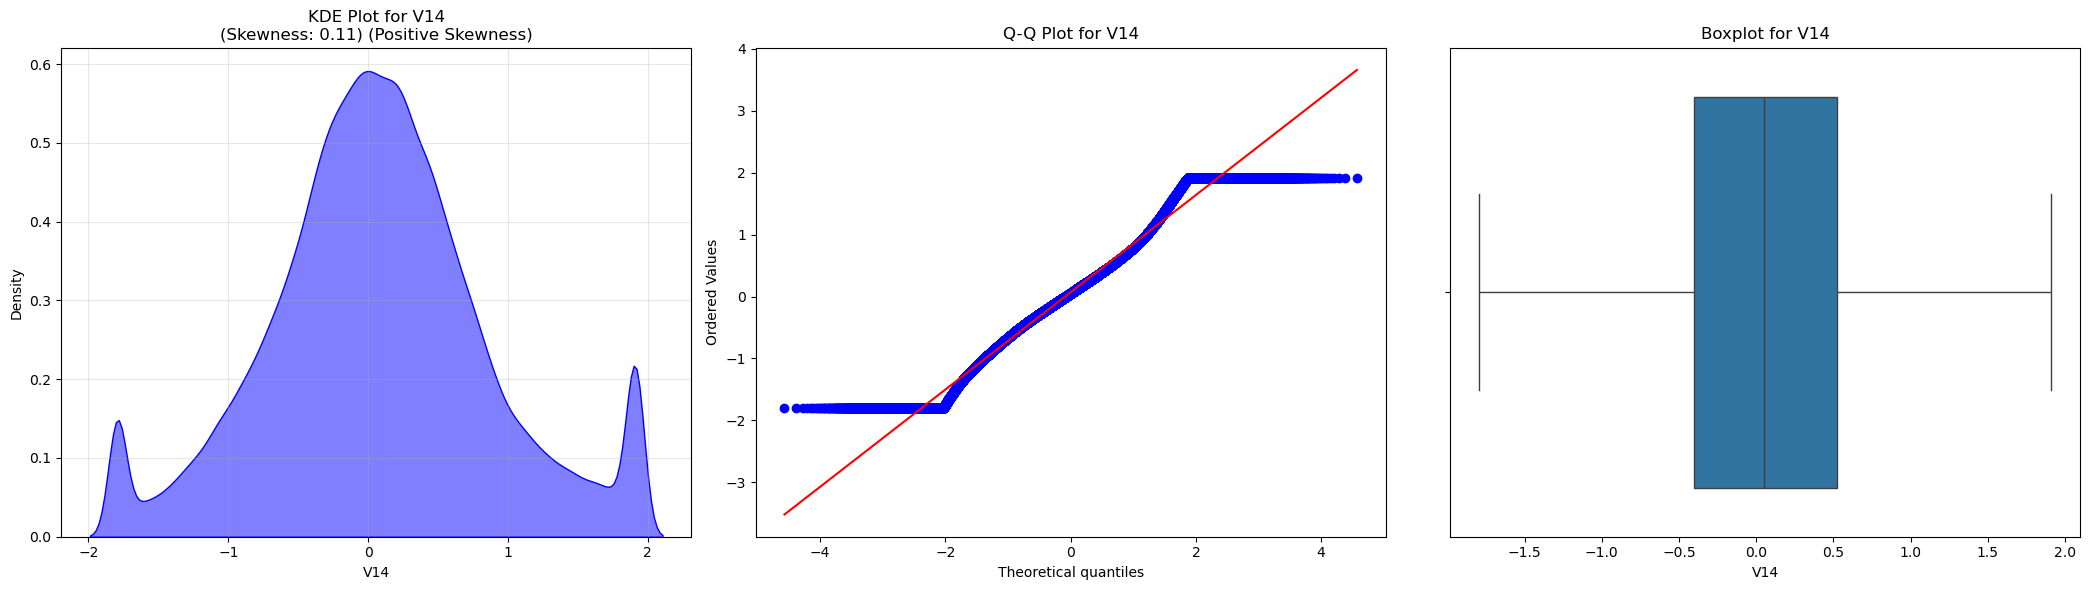

V15: Skewness = -0.03 (Negative Skewness)


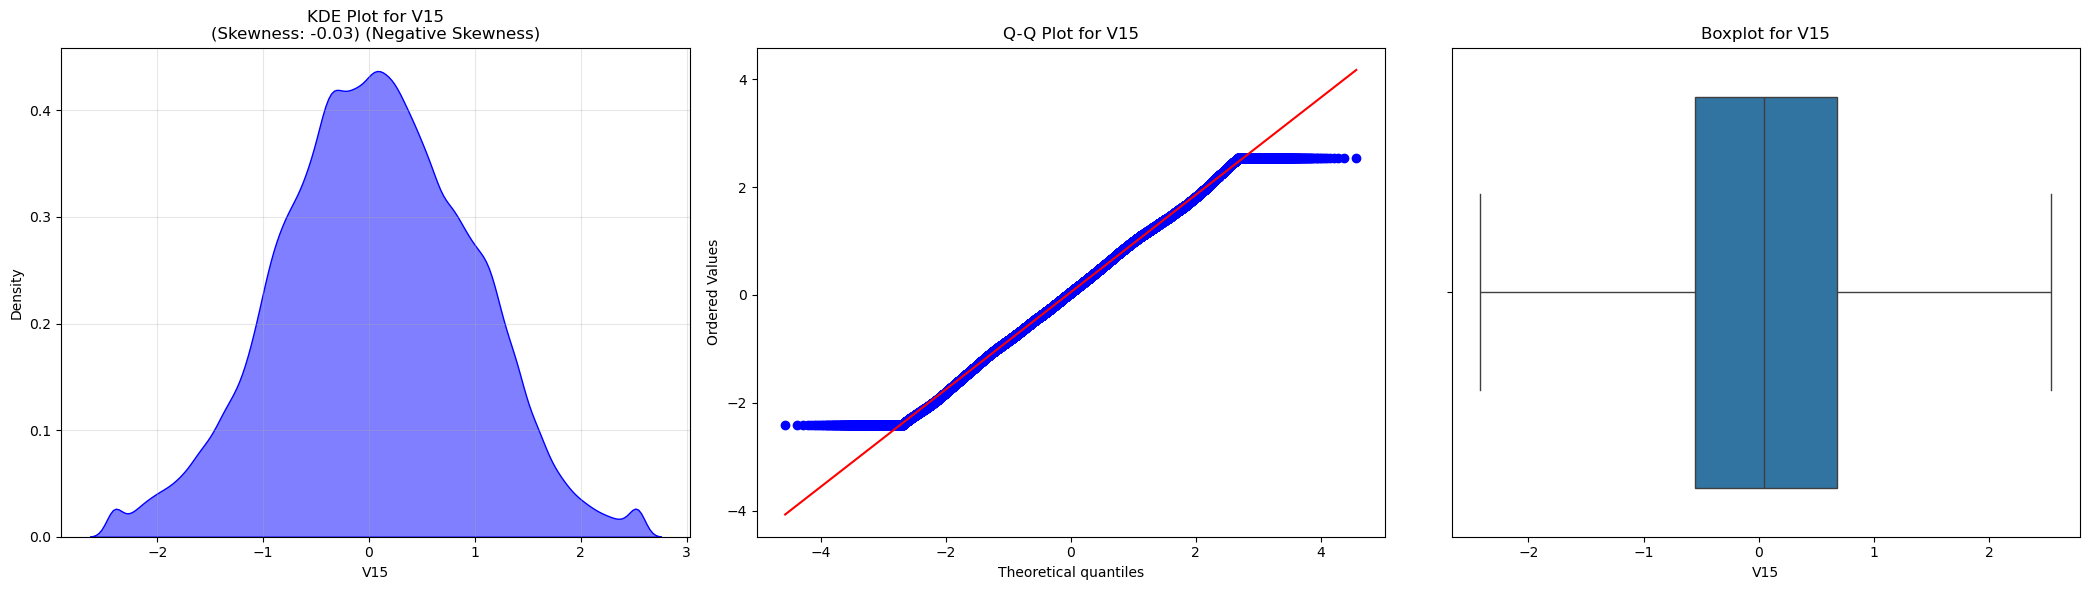

V16: Skewness = 0.05 (Positive Skewness)


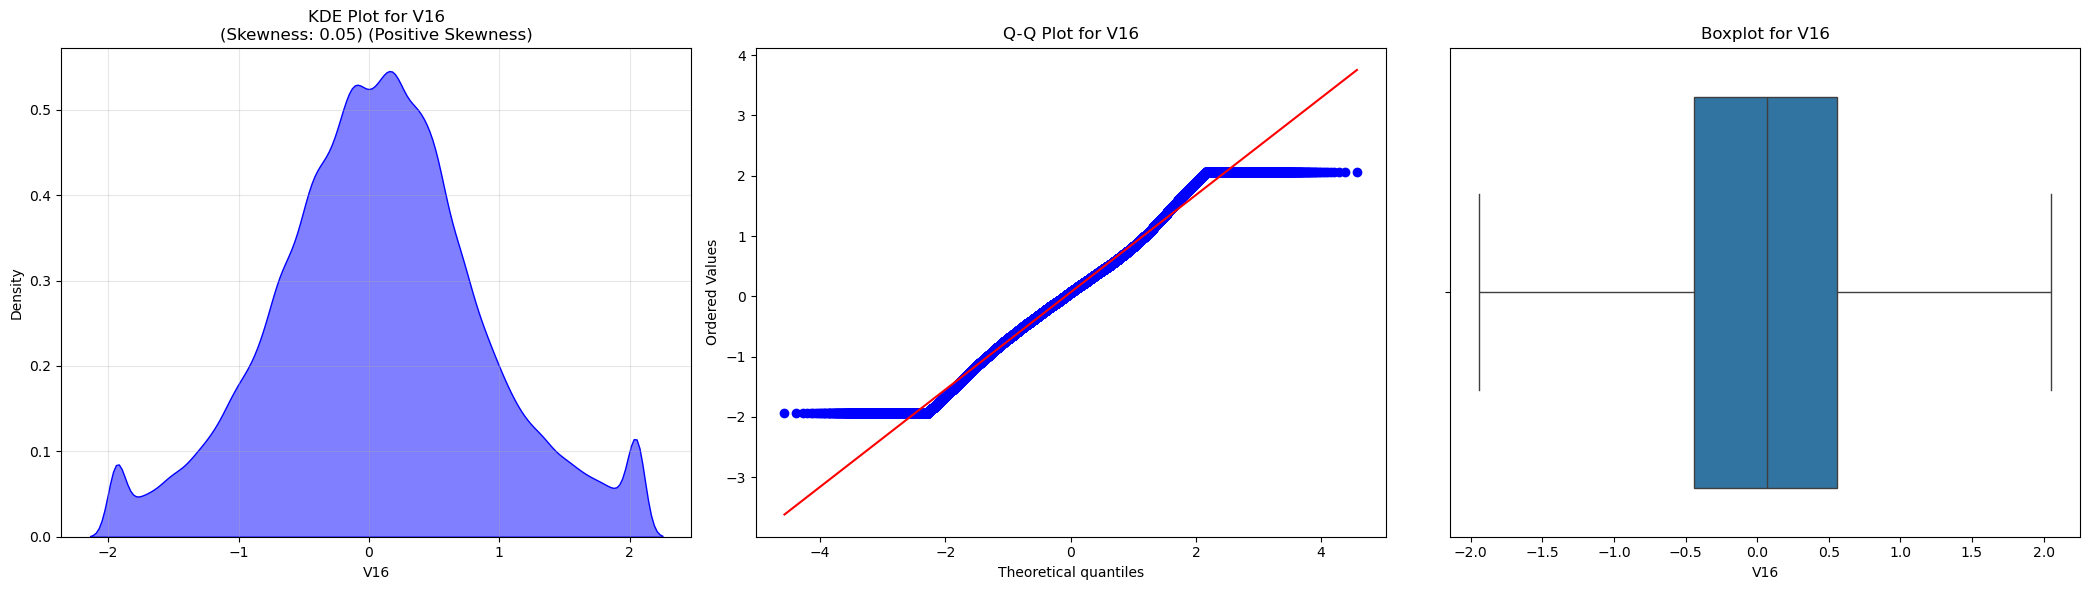

V17: Skewness = 0.55 (Positive Skewness)


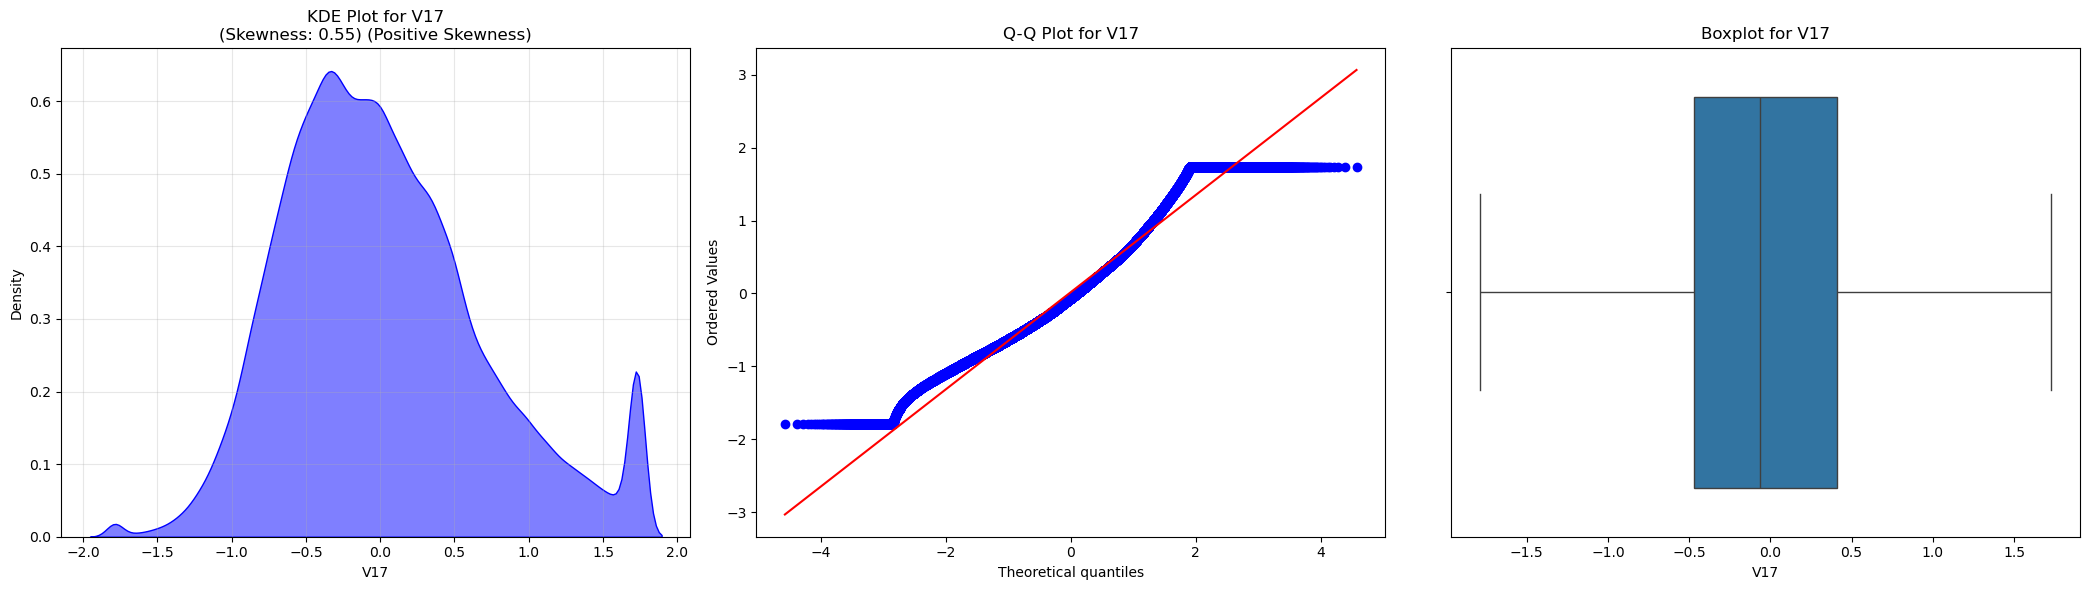

V18: Skewness = 0.09 (Positive Skewness)


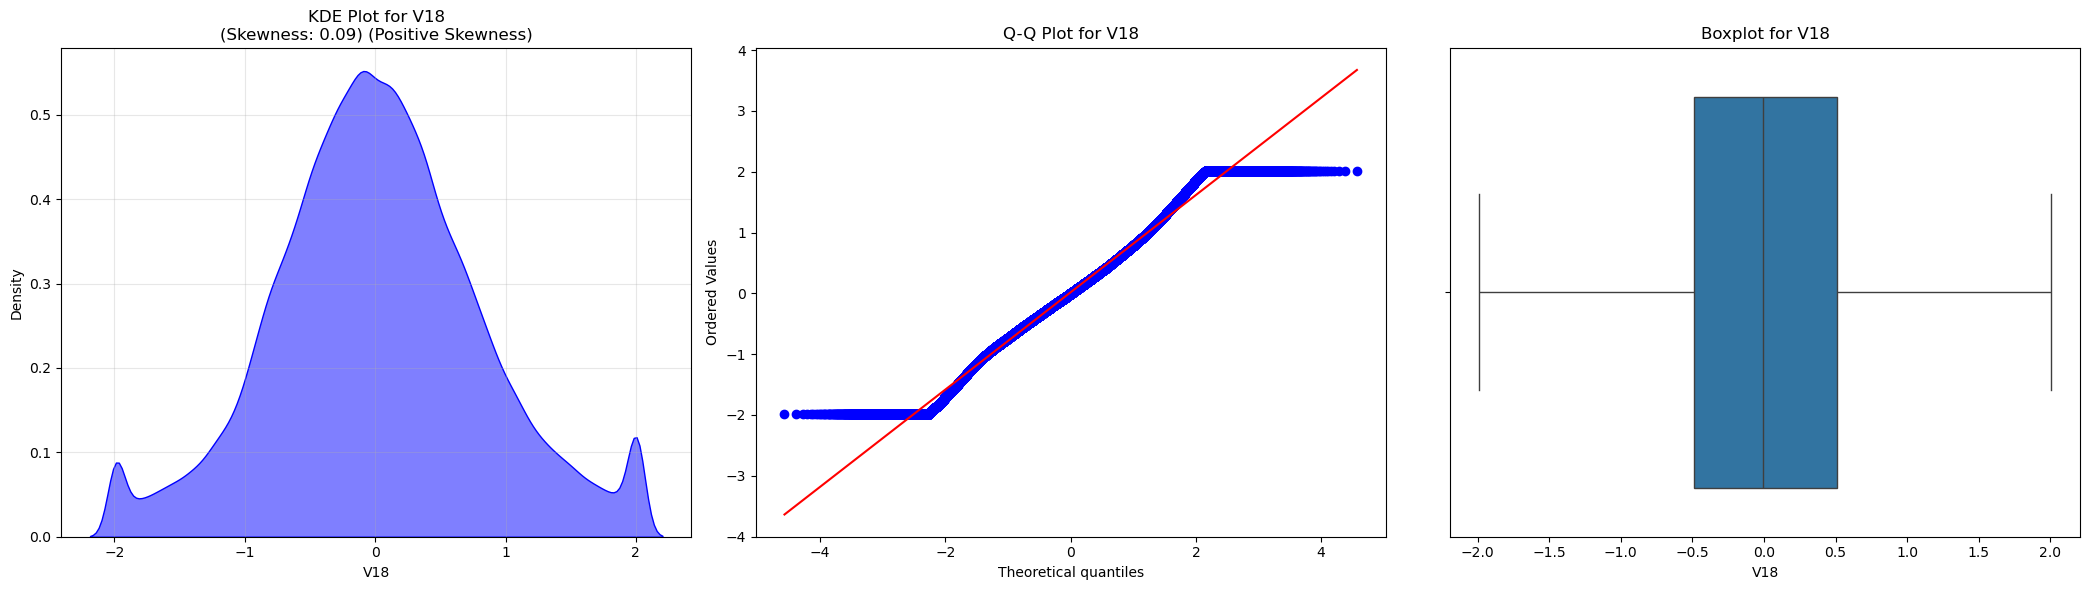

V19: Skewness = -0.07 (Negative Skewness)


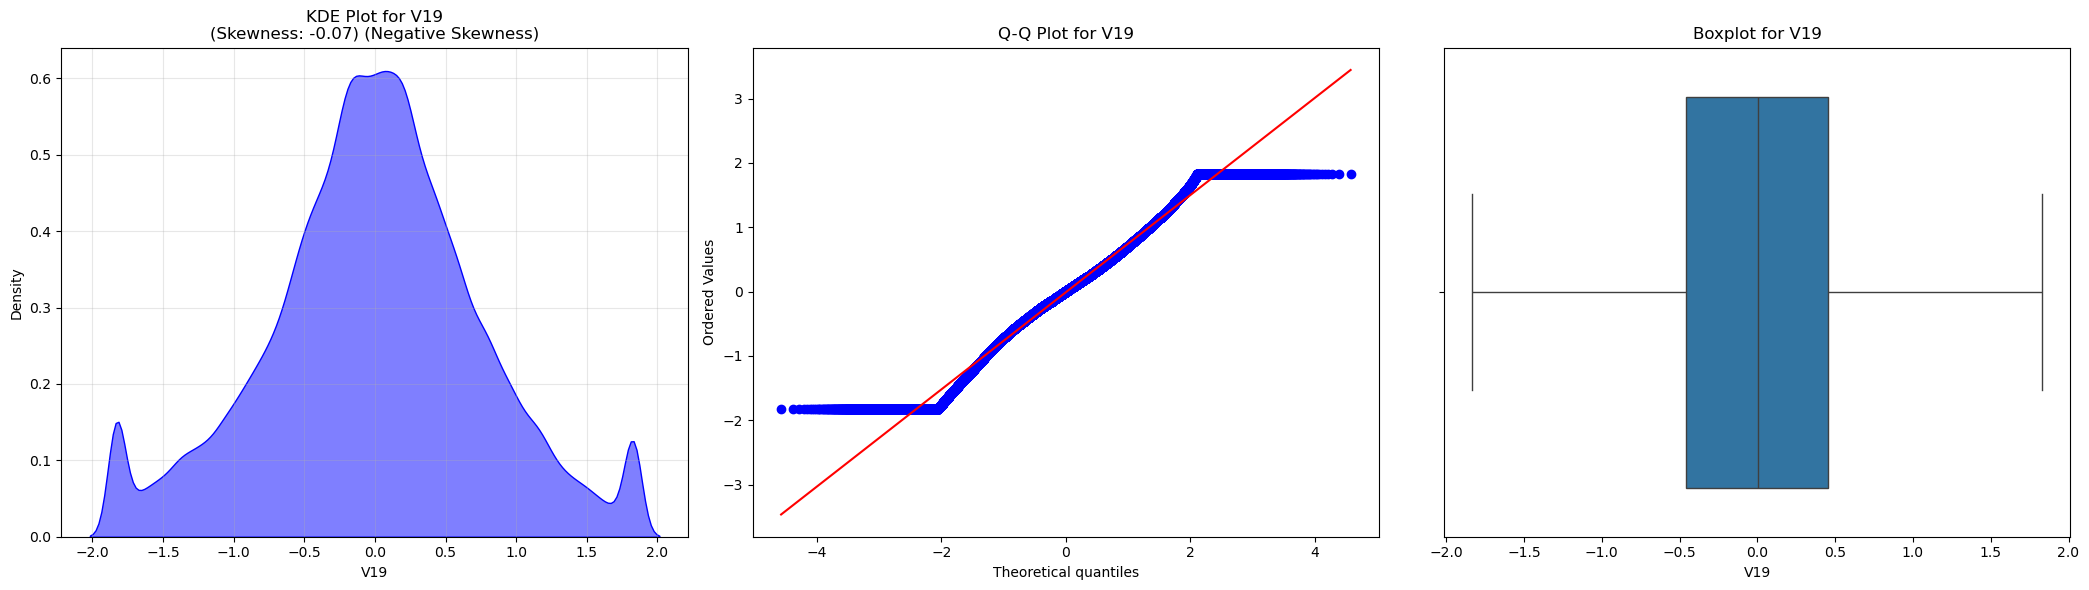

V20: Skewness = 0.29 (Positive Skewness)


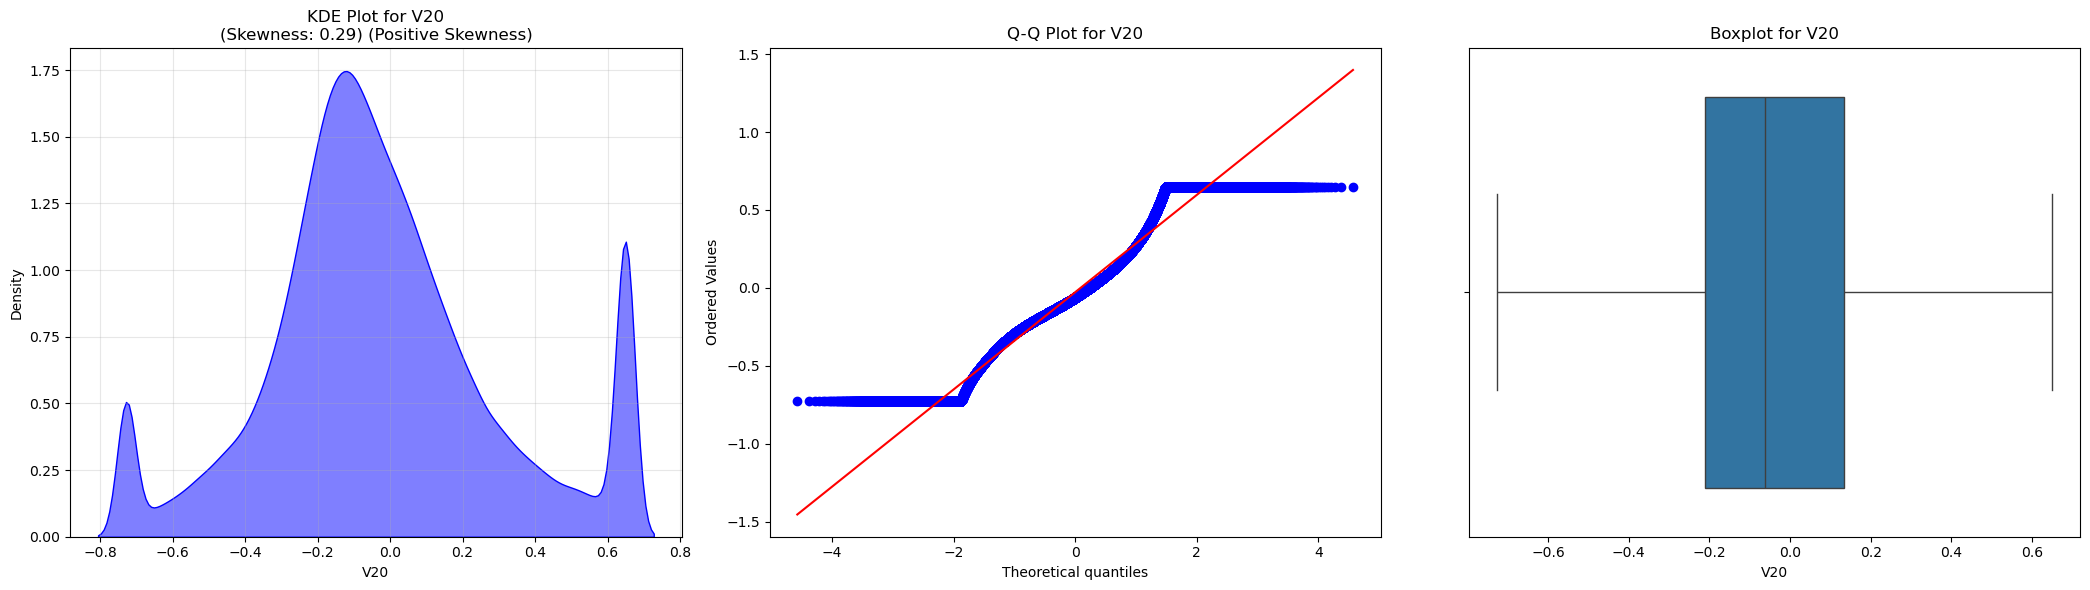

V21: Skewness = 0.09 (Positive Skewness)


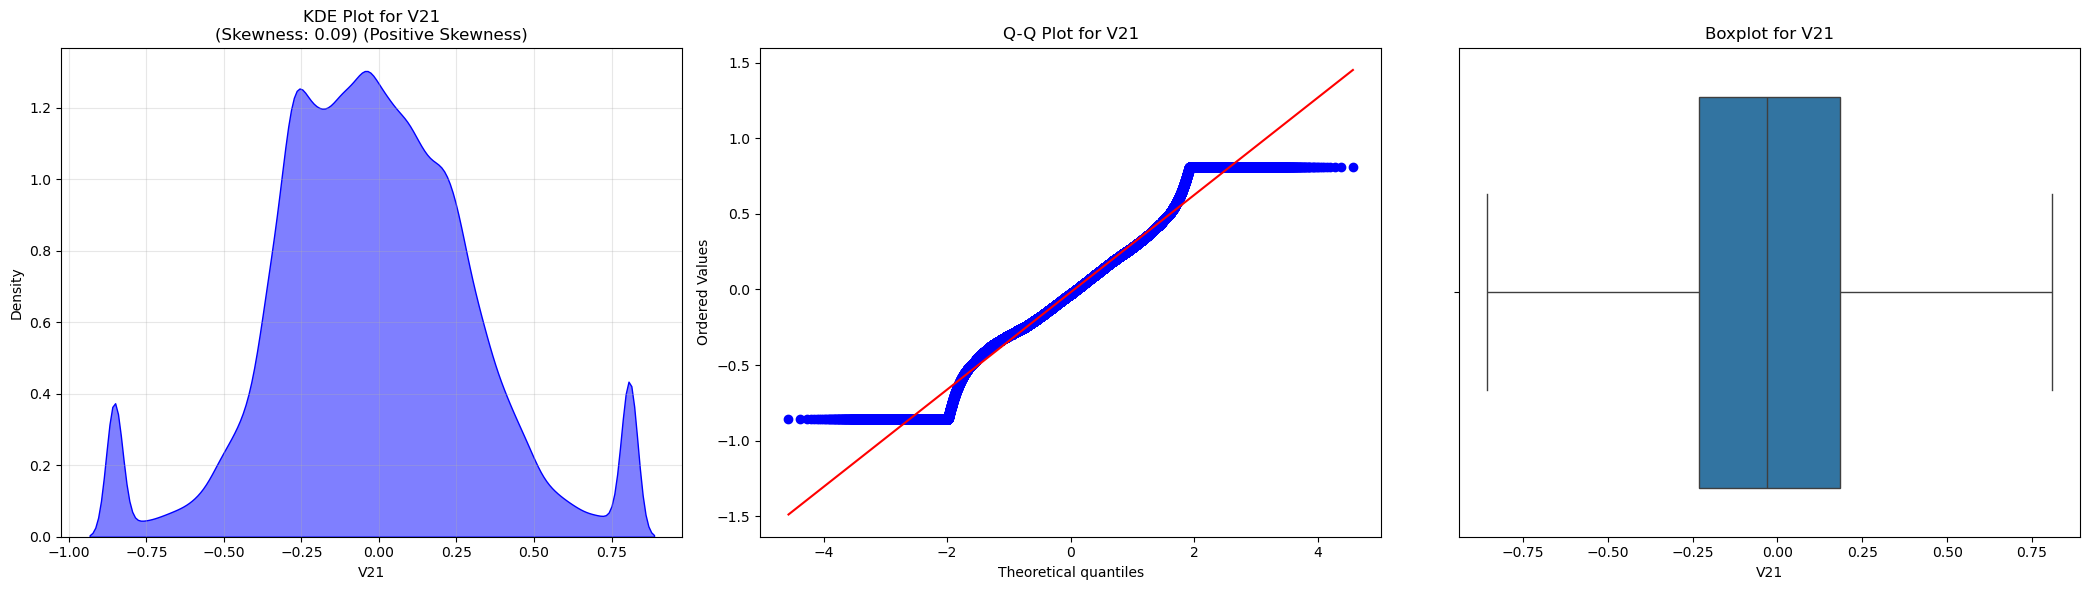

V22: Skewness = 0.04 (Positive Skewness)


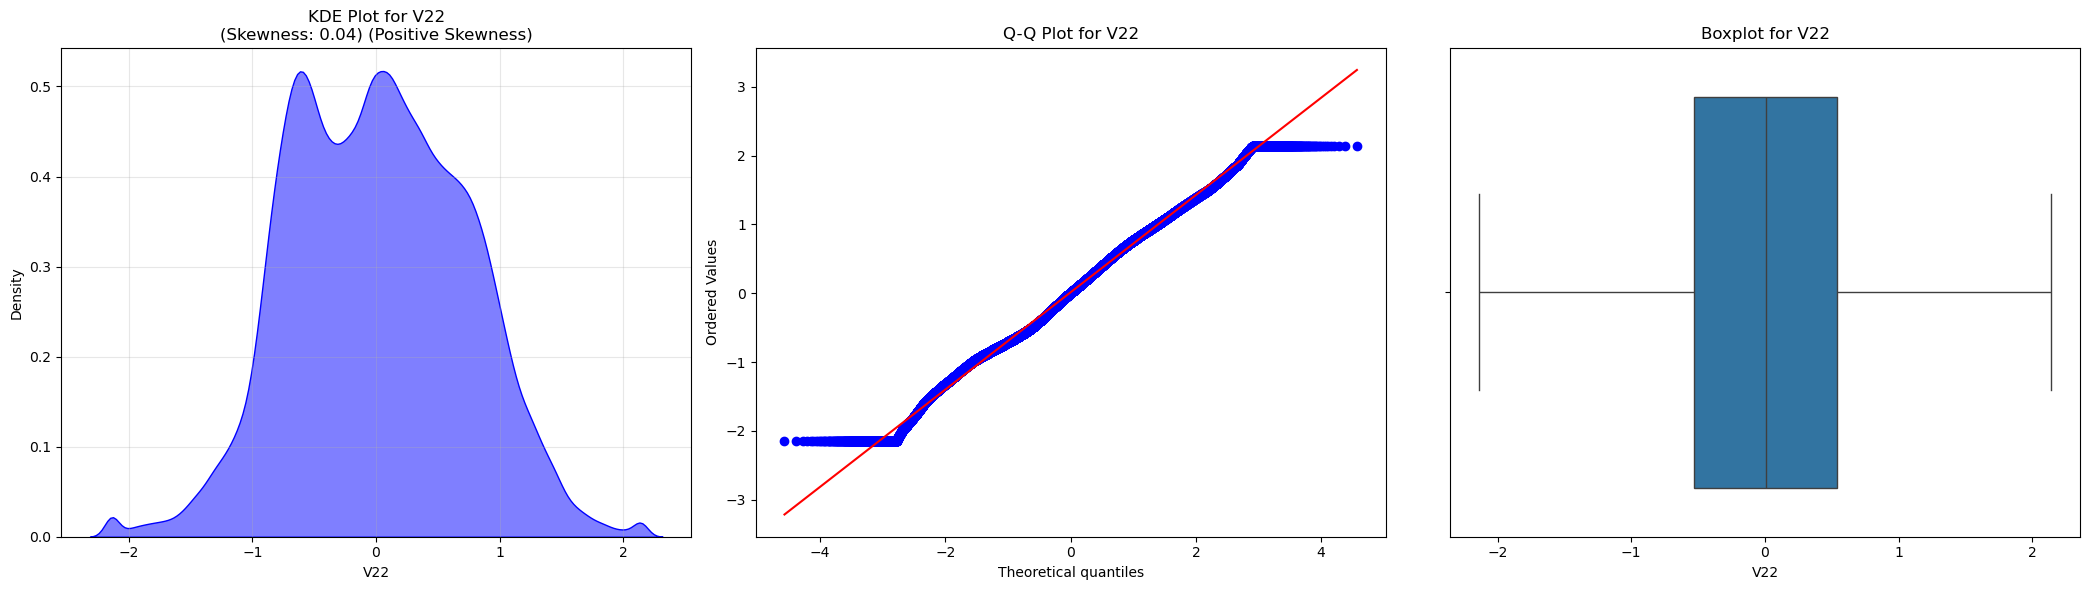

V23: Skewness = 0.08 (Positive Skewness)


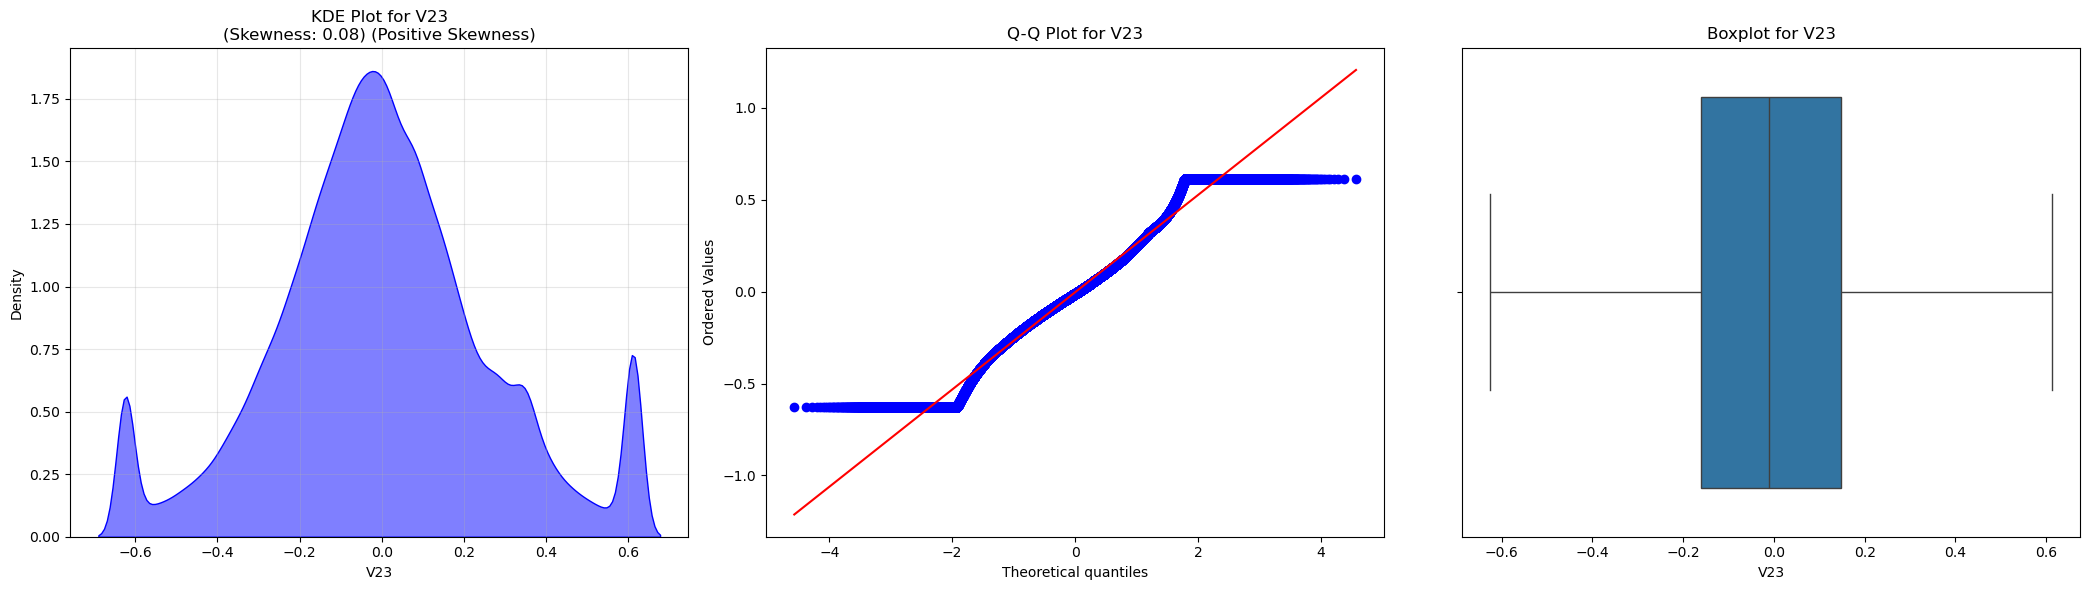

V24: Skewness = -0.14 (Negative Skewness)


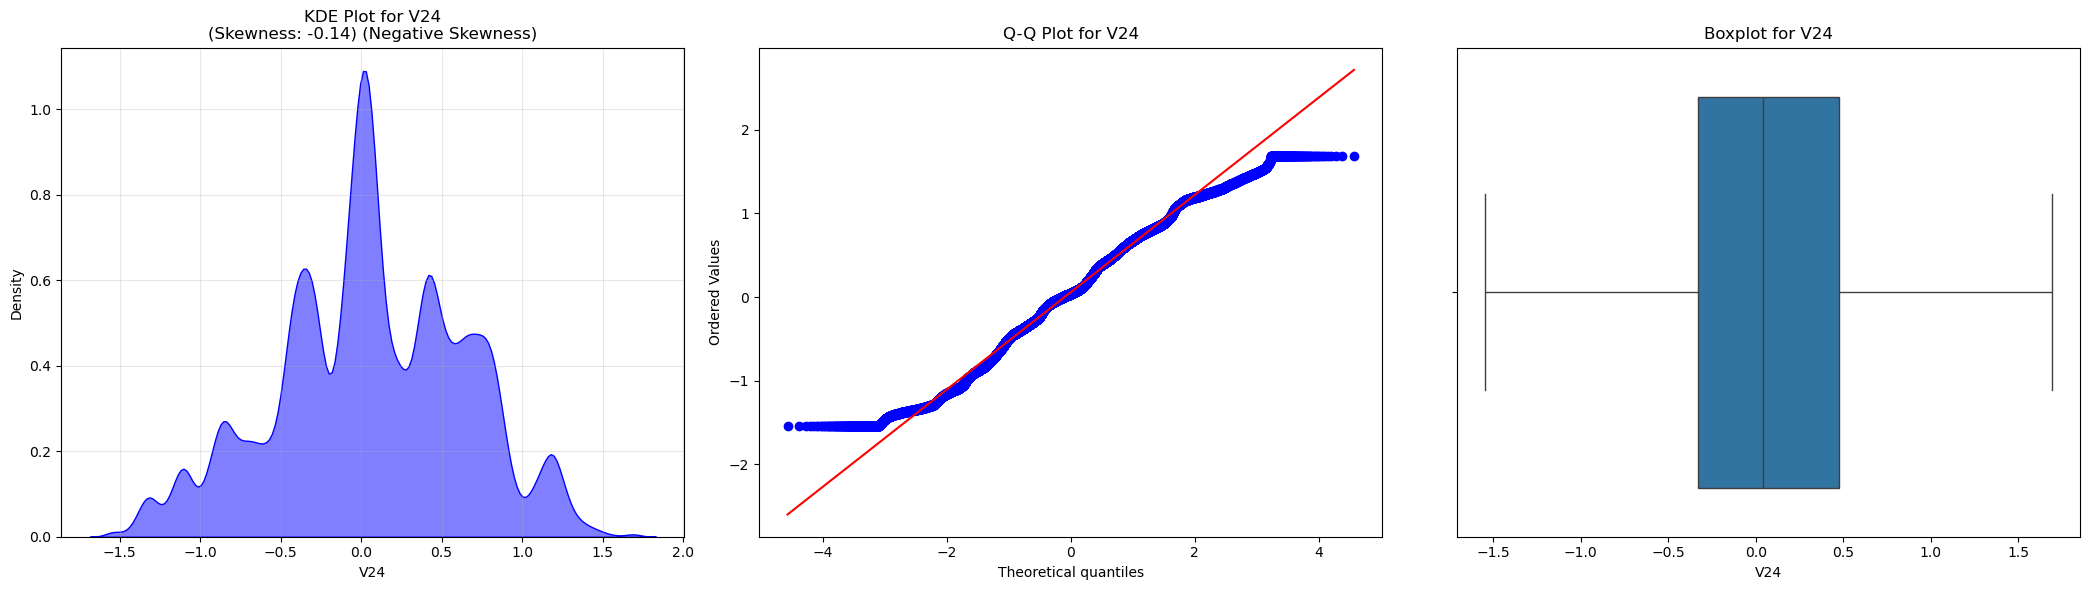

V25: Skewness = -0.02 (Negative Skewness)


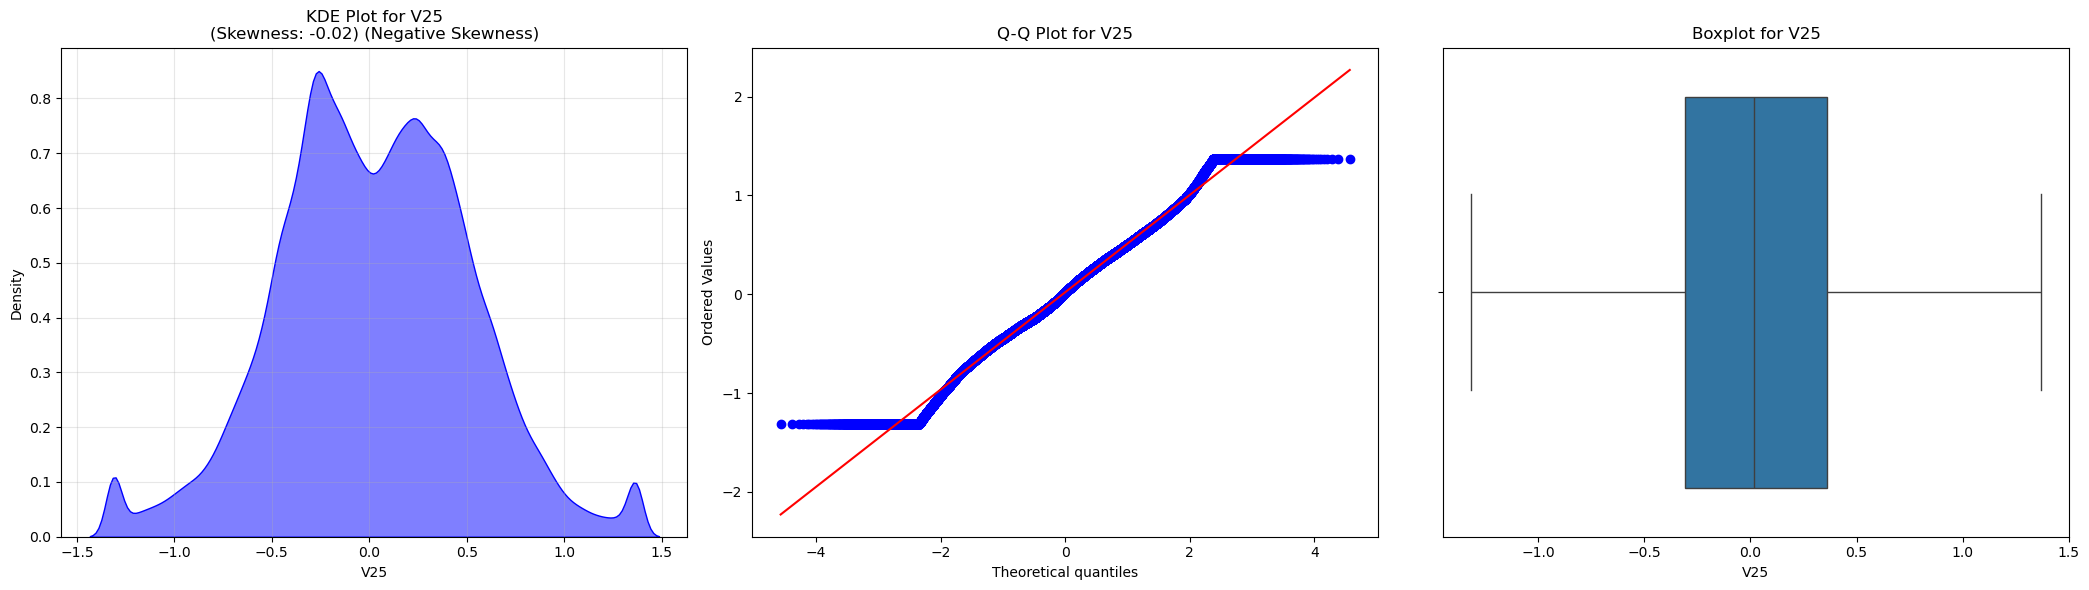

V26: Skewness = 0.00 (Positive Skewness)


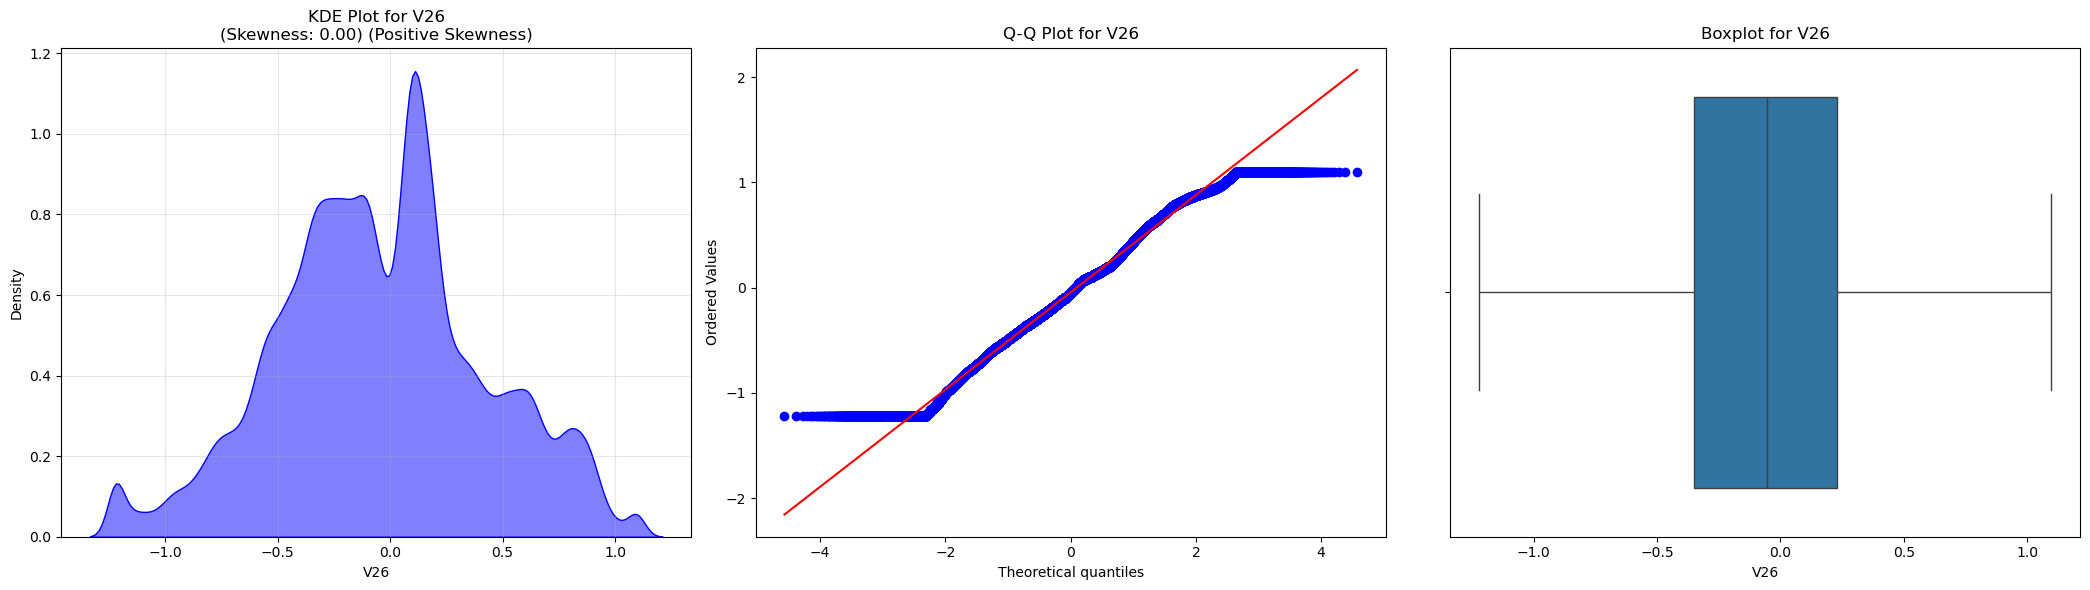

V27: Skewness = 0.09 (Positive Skewness)


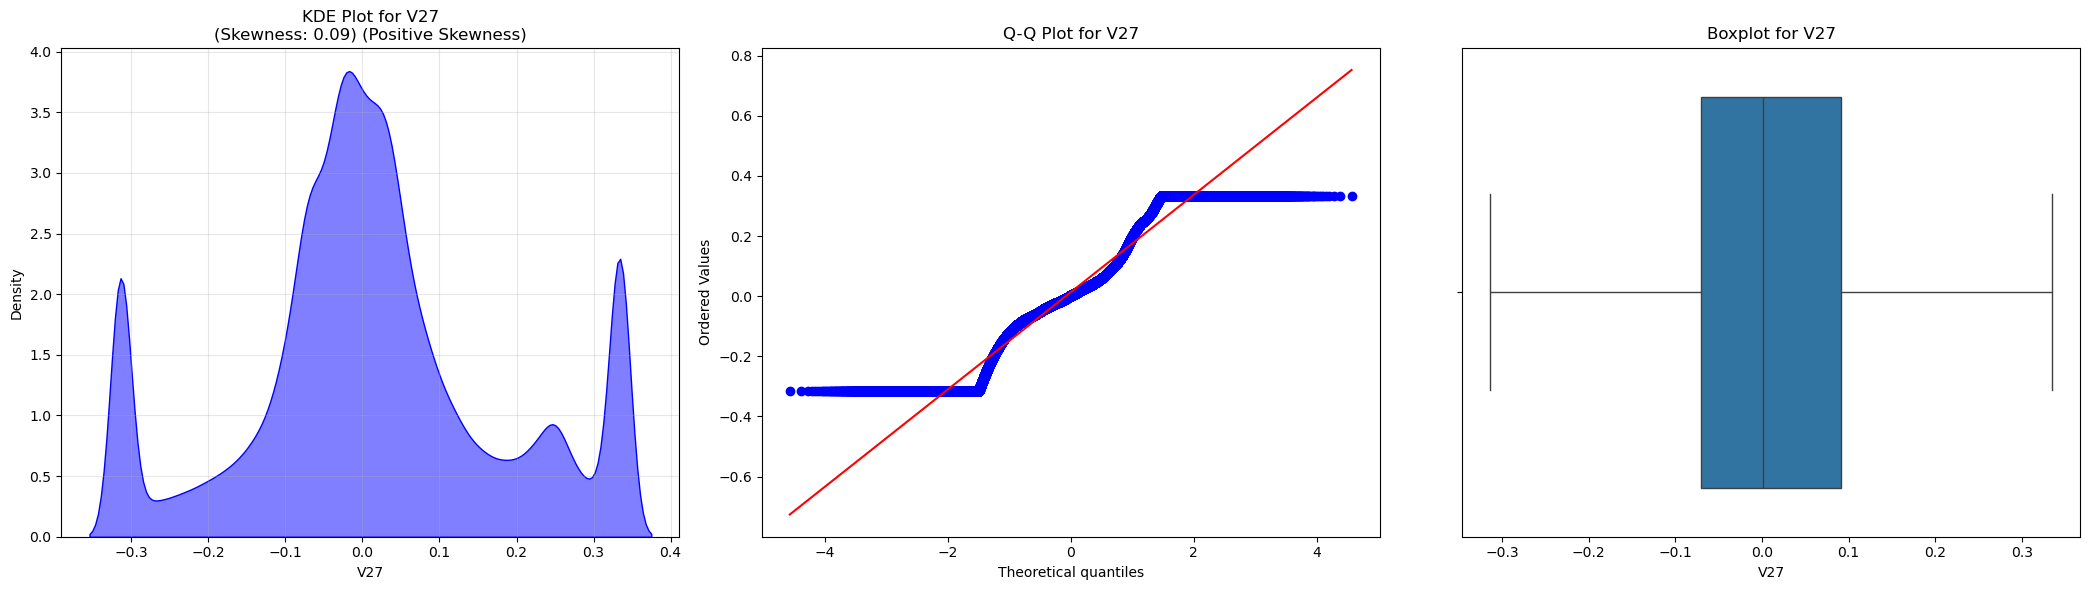

V28: Skewness = -0.05 (Negative Skewness)


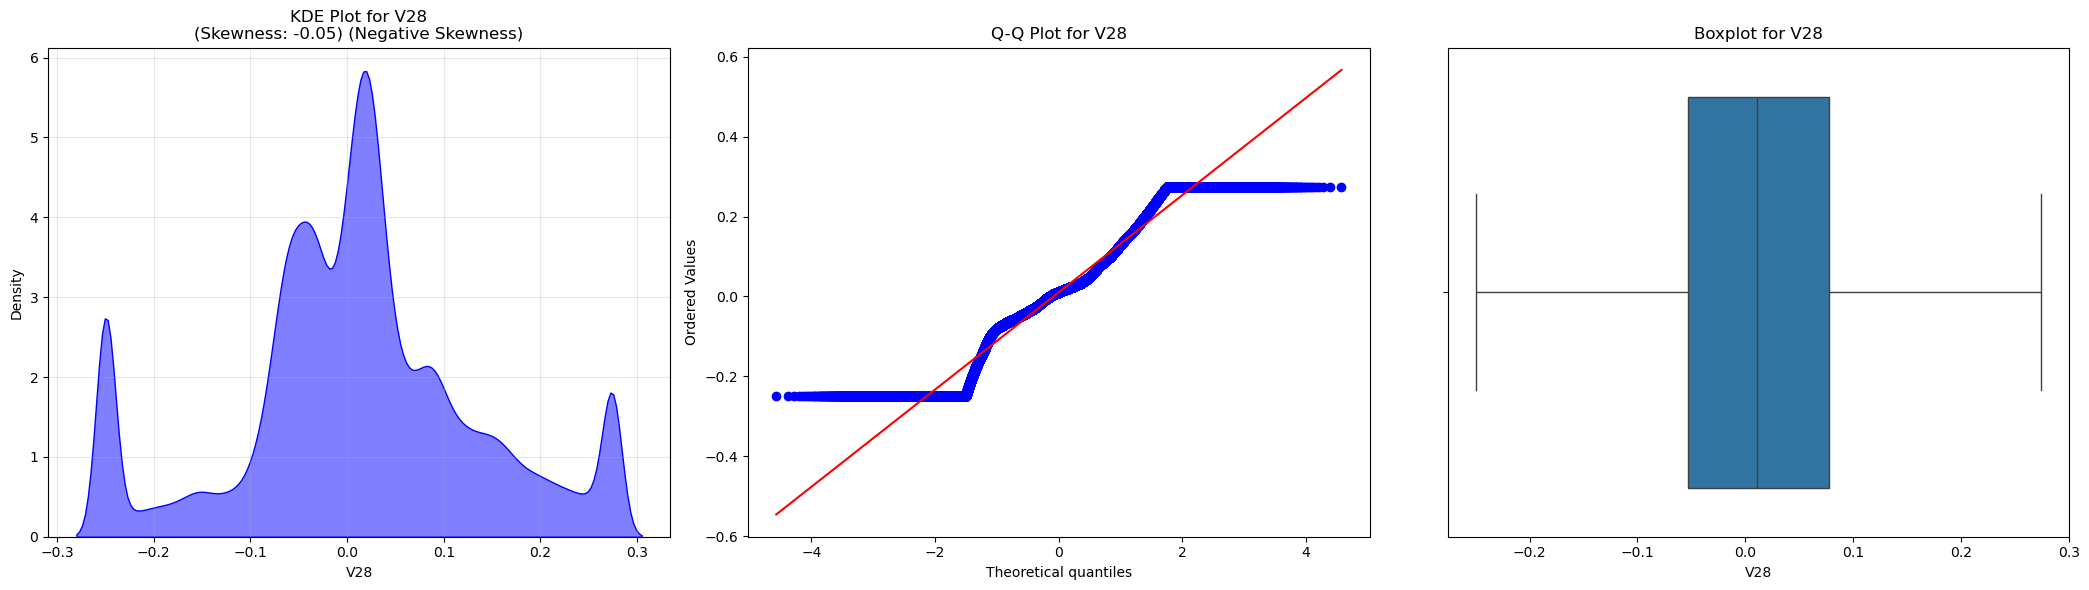

Amount: Skewness = 0.02 (Positive Skewness)


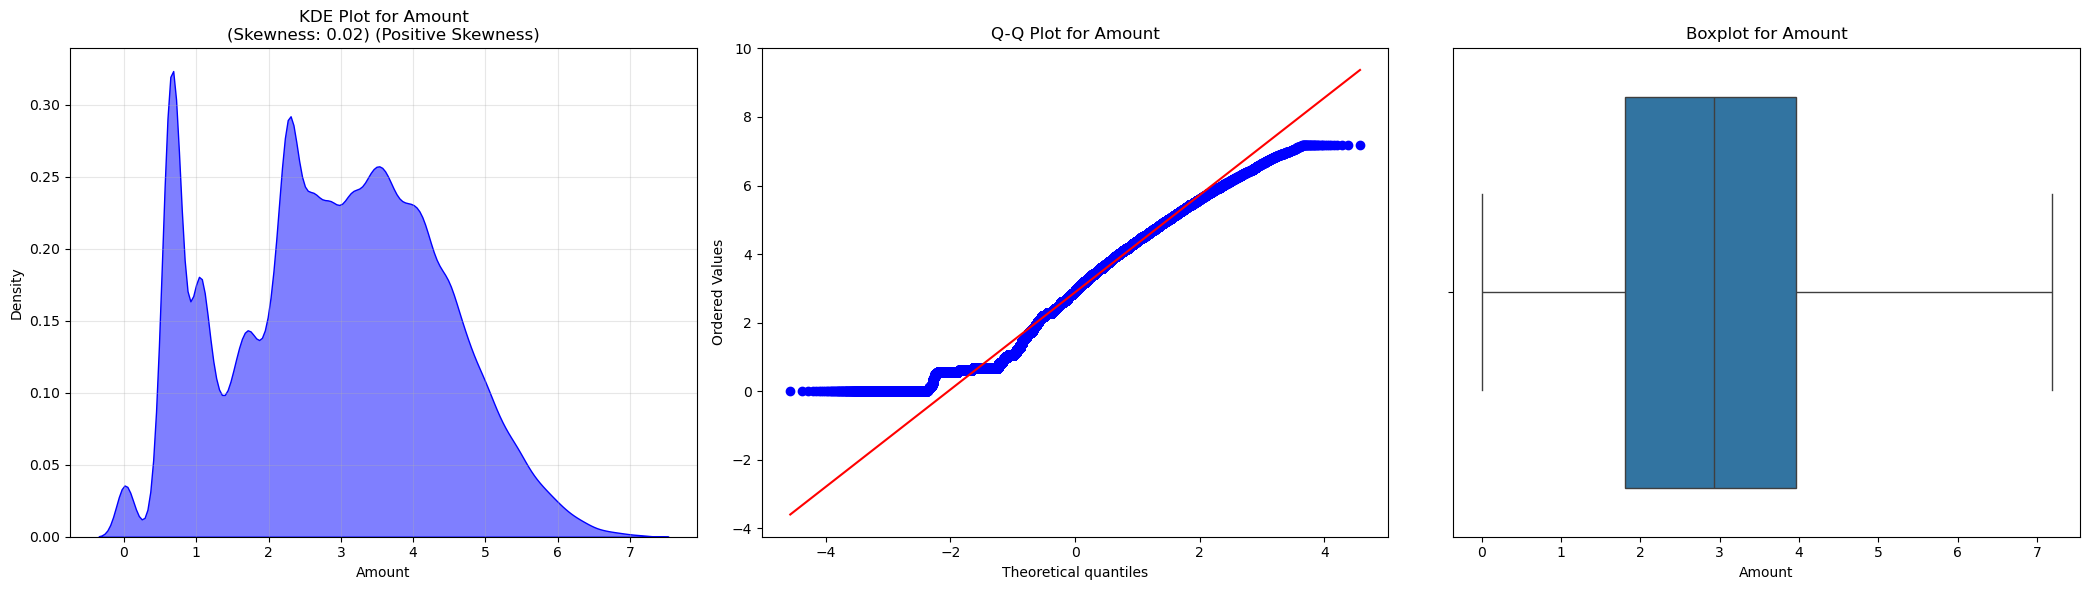

In [53]:
All_plot(X_new)

# train test split

In [58]:
from sklearn.model_selection import train_test_split

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X_trd,y,test_size=0.2,random_state=42)

In [64]:
X_train.shape , X_test.shape

((227845, 30), (56962, 30))

In [66]:
y_train.shape,y_test.shape

((227845,), (56962,))

In [70]:
# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [72]:
y_train_resampled.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [74]:
X_train_resampled.shape

(454902, 30)

In [86]:
# Scale the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# using logistic regression

In [96]:
# Initialize Logistic Regression with recommended parameters for large datasets
log_reg = LogisticRegression(
    solver='saga',          # Use 'saga' for large datasets
    max_iter=2000,          # Increase iterations for convergence
    # C=1.0,                 # Regularization strength (adjust as needed)
    # class_weight='balanced', # Adjust for class imbalance
    n_jobs=-1,              # Use all available CPU cores
    random_state=42         # For reproducibility
)

# Train the model
log_reg.fit(X_train_sc, y_train)

C:\Users\parvez\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42, solver='saga')

In [111]:
y_pred_r_train = log_reg.predict(X_train_sc)
y_pred_r_test = log_reg.predict(X_test_sc)

In [115]:
# Evaluate the model
print("Train Accuracy:", accuracy_score(y_train, y_pred_r_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_r_test))

Train Accuracy: 0.9992538787333495
Test Accuracy: 0.9991748885221726


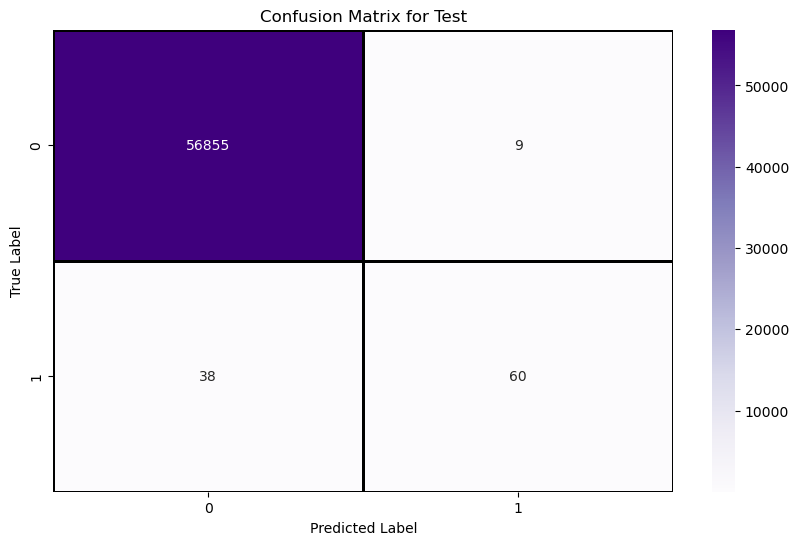

In [131]:
# Plot confusion matrix using seaborn heatmap
cm = confusion_matrix(y_test, y_pred_r_test)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples",linewidths=1, linecolor='black',
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'])
plt.title('Confusion Matrix for Test')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# using SGDClassifier

In [119]:
from sklearn.linear_model import SGDClassifier

# Initialize SGDClassifier with log loss (equivalent to Logistic Regression)
sgd = SGDClassifier(
    loss='log_loss',        # Equivalent to Logistic Regression
    max_iter=1000,          # Increase iterations
    learning_rate='adaptive',
    eta0=0.01,
    random_state=42,
    n_jobs=-1
)

# Train the model
sgd.fit(X_train, y_train)

# Make predictions
y_pred = sgd.predict(X_test)
y_pred_train = sgd.predict(X_train)

# Evaluate the model
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Train Accuracy: 0.9967126774781101
Test Accuracy: 0.9965766651451845

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.29      0.68      0.41        98

    accuracy                           1.00     56962
   macro avg       0.64      0.84      0.70     56962
weighted avg       1.00      1.00      1.00     56962



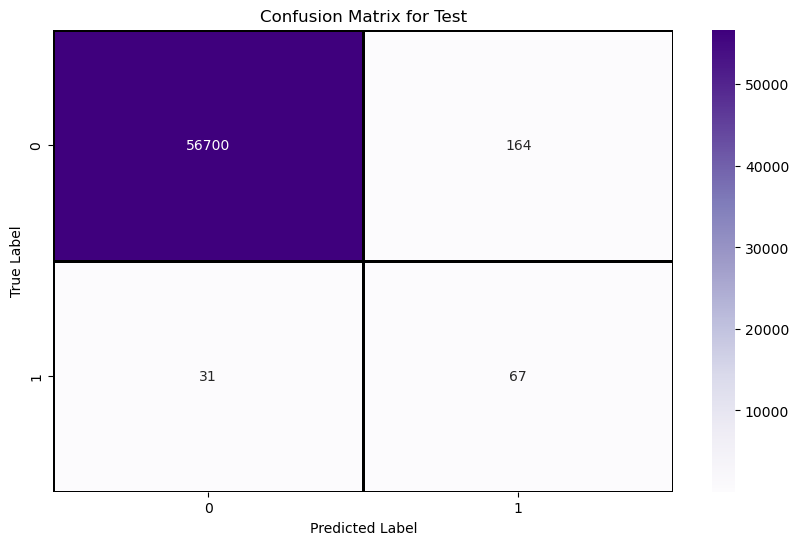

In [129]:
# Plot confusion matrix using seaborn heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples",linewidths=1, linecolor='black',
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'])
plt.title('Confusion Matrix for Test')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()